* Distance of all vertices

In [6]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from math import sqrt
from itertools import combinations

# === File and Data Configuration ===
excel_path = r"D:\Phd\PhD\Papers on topological indices\Paper on anidibetics drugs\data\coordinates.xlsx"
sheet_name = 'Sheet1'

# Dictionary: Drug name -> SMILES
smiles_dict = {
    'Metformin': 'CN(C)C(=N)N=C(N)N', 'Sitagliptin':'C1CN2C(=NN=C2C(F)(F)F)CN1C(=O)C[C@@H](CC3=CC(=C(C=C3F)F)F)N',
    'Saxagliptin': 'C1[C@@H]2C[C@@H]2N([C@@H]1C#N)C(=O)[C@H](C34CC5CC(C3)CC(C5)(C4)O)N','Canagliflozin':'CC1=C(C=C(C=C1)[C@H]2[C@@H]([C@H]([C@@H]([C@H](O2)CO)O)O)O)CC3=CC=C(S3)C4=CC=C(C=C4)F',
    'Glimepiride':'CCC1=C(CN(C1=O)C(=O)NCCC2=CC=C(C=C2)S(=O)(=O)NC(=O)OC)C', 'Pioglitazone':'CCC1=CN=C(C=C1)CCOC2=CC=C(C=C2)CC3C(=O)NC(=O)S3',
    'Empagliflozin':'C1COC[C@H]1OC2=CC=C(C=C2)CC3=C(C=CC(=C3)[C@H]4[C@@H]([C@H]([C@@H]([C@H](O4)CO)O)O)O)Cl',
    'Acarbose':'C[C@@H]1[C@H]([C@@H]([C@H]([C@H](O1)O[C@@H]2[C@H](O[C@@H]([C@@H]([C@H]2O)O)O[C@H]([C@@H](CO)O)[C@@H]([C@H](C=O)O)O)CO)O)O)N[C@H]3C=C([C@H]([C@@H]([C@H]3O)O)O)CO',
    'Repaglinide':'CCOC1=C(C=CC(=C1)CC(=O)N[C@@H](CC(C)C)C2=CC=CC=C2N3CCCCC3)C(=O)O','Vildagliptin':'C1C[C@H](N(C1)C(=O)CNC23CC4CC(C2)CC(C4)(C3)O)C#N',
    'Linagliptin':'CC#CCN1C2=C(N=C1N3CCC[C@H](C3)N)N(C(=O)N(C2=O)CC4=NC5=CC=CC=C5C(=N4)C)C','Dapagliflozin':'CCOC1=CC=C(C=C1)CC2=C(C=CC(=C2)[C@H]3[C@@H]([C@H]([C@@H]([C@H](O3)CO)O)O)O)Cl',
    'Teneligliptin':'CC1=NN(C(=C1)N2CCN(CC2)[C@H]3C[C@H](NC3)C(=O)N4CCSC4)C5=CC=CC=C5','Rosiglitazone':'CN(CCOC1=CC=C(C=C1)CC2C(=O)NC(=O)S2)C3=CC=CC=N3',
'Troglitazone':'CC1=C(C2=C(CCC(O2)(C)COC3=CC=C(C=C3)CC4C(=O)NC(=O)S4)C(=C1O)C)C ','Nateglinide':' CC(C)C1CCC(CC1)C(=O)N[C@H](CC2=CC=CC=C2)C(=O)O ',
'Gliclazide':'CC1=CC=C(C=C1)S(=O)(=O)NC(=O)NN2CC3CCCC3C2','Tolbutamide':'CCCCNC(=O)NS(=O)(=O)C1=CC=C(C=C1)C',
'Phenformin':' C1=CC=C(C=C1)CCN=C(N)N=C(N)N','Ipragliflozin':'C1=CC=C2C(=C1)C=C(S2)CC3=C(C=CC(=C3)[C@H]4[C@@H]([C@H]([C@@H]([C@H](O4)CO)O)O)O)F '}

# === Distance Calculation Function ===
def compute_distance(c1, c2):
    return sqrt((c1[0] - c2[0])**2 + (c1[1] - c2[1])**2 + (c1[2] - c2[2])**2)

# === Topological Index Computation ===
def compute_indices(atom_coords, bonds):
    N = len(atom_coords)
    dist_matrix = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            dist_matrix[i][j] = compute_distance(atom_coords[i], atom_coords[j])

    def compare(i, j):
        closer_i = sum(1 for k in range(N) if k != i and k != j and dist_matrix[i][k] < dist_matrix[j][k])
        closer_j = sum(1 for k in range(N) if k != i and k != j and dist_matrix[j][k] < dist_matrix[i][k])
        return closer_i, closer_j

    Mo = PI = Sz = GA = 0
    for i, j in bonds:
        n_i, n_j = compare(i, j)
        Mo += abs(n_i - n_j)
        PI += (n_i + n_j)
        Sz += n_i * n_j
        if n_i + n_j != 0:
            GA += (2 * sqrt(n_i * n_j)) / (n_i + n_j)

    # Trinajstic index
    NT = 0
    for i, j in combinations(range(N), 2):
        n_i, n_j = compare(i, j)
        NT += (n_i - n_j)**2

    return {
        'Trinajstic': NT,
        'Mostar': Mo,
        'PI': PI,
        'Szeged': Sz,
        'GA': GA
    }

# === Read Excel and Process Each Drug ===
df = pd.read_excel(excel_path, sheet_name=sheet_name)

for drug_name, group in df.groupby('Drug'):
    print(f"\nProcessing: {drug_name}")
    if drug_name not in smiles_dict:
        print("  [SKIPPED] SMILES not found.")
        continue

    smiles = smiles_dict[drug_name]
    atom_coords = list(zip(group['x'], group['y'], group['z']))

    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    bonds = [(b.GetBeginAtomIdx(), b.GetEndAtomIdx()) for b in mol.GetBonds()]

    indices = compute_indices(atom_coords, bonds)
    for name, value in indices.items():
        print(f"  {name} Index: {value:.4f}")



Processing: Acarbose
  Trinajstic Index: 4415277.0000
  Mostar Index: 2511.0000
  PI Index: 7565.0000
  Szeged Index: 132996.0000
  GA Index: 80.2143

Processing: Canagliflozin
  Trinajstic Index: 636208.0000
  Mostar Index: 1388.0000
  PI Index: 3186.0000
  Szeged Index: 31789.0000
  GA Index: 49.4818

Processing: Dapagliflozin
  Trinajstic Index: 605386.0000
  Mostar Index: 1103.0000
  PI Index: 2805.0000
  Szeged Index: 28092.0000
  GA Index: 47.9720

Processing: Empagliflozin
  Trinajstic Index: 808020.0000
  Mostar Index: 1180.0000
  PI Index: 3416.0000
  Szeged Index: 39828.0000
  GA Index: 55.3887

Processing: Gliclazide
  Trinajstic Index: 214367.0000
  Mostar Index: 583.0000
  PI Index: 1845.0000
  Szeged Index: 15714.0000
  GA Index: 40.1043

Processing: Glimepiride
  Trinajstic Index: 1143916.0000
  Mostar Index: 1318.0000
  PI Index: 3432.0000
  Szeged Index: 45231.0000
  GA Index: 46.1228

Processing: Ipragliflozin
  Trinajstic Index: 432872.0000
  Mostar Index: 886.0000


"""
GNN-EMBEDDINGS (NODE + EDGE) + ML PIPELINE FOR MOLECULAR PROPERTY PREDICTION
=============================================================================
End-to-end Python script:
1) Input: SMILES + target property(ies) from CSV, Excel (.xlsx/.xls), or Word (.docx).
2) Build molecular graphs (atoms as nodes, bonds as edges) with RDKit → PyTorch Geometric.
3) Train an edge-aware GNN (GINE) to learn:
   - Node embeddings (per-atom → pooled to graph-level)
   - Edge embeddings (per-bond features passed through an edge MLP → pooled to graph-level)
4) Extract three feature sets per molecule: NODE, EDGE, COMBINED (NODE⊕EDGE) embeddings.
5) Train ML models (Ridge, SVR, RandomForest, and XGBoost if available) on each feature set.
6) Evaluate R², MSE, RMSE, MAE, Pearson r and generate plots (scatter, sorted line, metrics bar, error violin).
7) Suggest best algorithm by RMSE, per target and per feature set.

USAGE
-----
- Prepare a file with at least a SMILES column and one or more target columns.
  Supported:
    • CSV:      data.csv
    • Excel:    data.xlsx / data.xls
    • Word:     data.docx  (use a table with a header row; include column 'smiles' and your target column names)

- Configure the CONFIG section (path, target columns, epochs, etc.).
- Run: `python gnn_node_edge_embeddings_ml_pipeline.py`

OUTPUTS
-------
- Trained GNN checkpoint
- CSVs: predictions per model & feature set, metrics summary
- PNGs: predicted-vs-actual scatter, sorted line, metrics bar, error violin
- TXT: best model per target and feature set

REQUIREMENTS
------------
- rdkit-pypi, torch, torch_geometric, scikit-learn, matplotlib, pandas, numpy
- parsers: openpyxl (for .xlsx), xlrd (for .xls), python-docx (for .docx)
- optional: xgboost
"""

In [1]:
from docx import Document
from pubchempy import get_compounds, Compound
import os

def fetch_properties(drug_name, prop_names):
    """
    Fetch the given properties from PubChem for a drug name.
    Returns dict prop_name -> value (or None if not found).
    """
    try:
        comps = get_compounds(drug_name, 'name')
        if not comps:
            print(f"No PubChem entry for {drug_name}")
            return {p: None for p in prop_names}
        comp = comps[0]
        result = {}
        # comp.to_dict might have many keys; use getattr or dict fallback
        d = comp.to_dict()
        for p in prop_names:
            # Try attribute first
            if hasattr(comp, p):
                result[p] = getattr(comp, p)
            elif p in d:
                result[p] = d.get(p)
            else:
                result[p] = None
        return result
    except Exception as e:
        print("Error fetching for", drug_name, e)
        return {p: None for p in prop_names}

def main():
    drug_names = [
        "Amlodipine", "Losartan", "Enalapril", "Atenolol", "Hydrochlorothiazide",
        "Nitroglycerin", "Isosorbide dinitrate", "Ranolazine",
        "Amiodarone", "Digoxin", "Verapamil",
        "Warfarin", "Apixaban", "Dabigatran", "Clopidogrel", "Aspirin",
        "Atorvastatin", "Rosuvastatin", "Ezetimibe",
        "Ivabradine"
    ]
    # Choose 5 property names that PubChem often has
    prop_names = [
        "molecular_weight",       # Molecular Weight
        "xlogp",                   # LogP estimate
        "tpsa",                     # Topological Polar Surface Area
        "h_bond_donor_count",      # HBD
        "h_bond_acceptor_count"    # HBA
    ]
    
    # Create Word document
    doc = Document()
    doc.add_heading("Physicochemical Properties of 20 Cardiovascular Drugs", level=1)
    
    # Table: columns = Drug + 5 properties
    table = doc.add_table(rows=1, cols=len(prop_names) + 1)
    hdr = table.rows[0].cells
    hdr[0].text = "Drug"
    for i, p in enumerate(prop_names, start=1):
        hdr[i].text = p
    
    # Fetch data and fill rows
    for drug in drug_names:
        props = fetch_properties(drug, prop_names)
        row = table.add_row().cells
        row[0].text = drug
        for i, p in enumerate(prop_names, start=1):
            val = props.get(p)
            row[i].text = str(val) if val is not None else ""
    
    # Save the document
    output_path = r"D:\Phd\PhD\Papers on topological indices\Cardiovascular Therapeutics\drug_properties_pubchem.docx"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    doc.save(output_path)
    print("Saved Word file to:", output_path)

if __name__ == "__main__":
    main()


Saved Word file to: D:\Phd\PhD\Papers on topological indices\Cardiovascular Therapeutics\drug_properties_pubchem.docx


In [1]:
# ================================
# Drug property prediction pipeline
# From SMILES → Morgan Fingerprints → ML Models
# Models: RF, GB, MLP, SVR, XGB
# Evaluated with Cross-Validation & Statistics (R2, MAE, MSE, RMSE)
# ================================

import docx
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer

# ==========================================================
# Step 1: Load data from docx
# ==========================================================
doc_path = r"D:\Phd\PhD\Papers on topological indices\Cardiovascular Therapeutics\Data\Smiles.docx"
doc = docx.Document(doc_path)

rows = []
for table in doc.tables:
    header = [cell.text.strip() for cell in table.rows[0].cells]
    for row in table.rows[1:]:
        rows.append([cell.text.strip() for cell in row.cells])
    break  # only first table

df = pd.DataFrame(rows, columns=header)
df.columns = [c.strip() for c in df.columns]

# Detect SMILES and drug columns
smiles_col = None
drug_col = None
for c in df.columns:
    if c.lower() in ['smile', 'smiles', 'smilestring']:
        smiles_col = c
    if c.lower() in ['drug', 'name']:
        drug_col = c
if smiles_col is None:
    smiles_col = df.columns[1]
if drug_col is None:
    drug_col = df.columns[0]

# Detect numeric property columns
prop_cols = []
for c in df.columns:
    if c in [smiles_col, drug_col]:
        continue
    s = pd.to_numeric(df[c].astype(str).str.replace('\xa0', '').str.replace(',', '').str.strip(), errors='coerce')
    if s.notna().sum() > 0:
        df[c] = s
        prop_cols.append(c)

# Filter valid SMILES
df = df[df[smiles_col].notna()].reset_index(drop=True)

# ==========================================================
# Step 2: Compute Morgan Fingerprints as embeddings
# ==========================================================
fps, names = [], []
for i, row in df.iterrows():
    mol = Chem.MolFromSmiles(row[smiles_col])
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fps.append(arr)
    names.append(row[drug_col])

X = np.array(fps)
Y = df.loc[:len(X)-1, prop_cols].astype(float).values

# Impute missing values
imp = SimpleImputer(strategy='mean')
Y = imp.fit_transform(Y)

# ==========================================================
# Step 3: Define Models with tuned hyperparameters
# ==========================================================
models = {
    "RandomForest": RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=3, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(512, 256, 128), alpha=0.0005, max_iter=5000, random_state=42),
    "SVR": SVR(kernel='rbf', C=10, gamma='scale'),
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

# ==========================================================
# Step 4: Cross-Validation Evaluation with Statistics
# ==========================================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("\n===== Cross-Validation Results with Statistics =====\n")
for i, prop in enumerate(prop_cols):
    print(f"\n--- Property: {prop} ---")
    y_target = Y[:, i]
    results[prop] = {}
    
    for name, model in models.items():
        if name in ["MLP", "SVR"]:
            scaler_X = StandardScaler().fit(X)
            X_scaled = scaler_X.transform(X)
            scaler_y = StandardScaler().fit(y_target.reshape(-1, 1))
            y_scaled = scaler_y.transform(y_target.reshape(-1, 1)).ravel()
            y_pred = cross_val_predict(model, X_scaled, y_scaled, cv=kf)
            # inverse transform for metrics
            y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        else:
            y_pred = cross_val_predict(model, X, y_target, cv=kf)
        
        # Compute statistics
        r2 = r2_score(y_target, y_pred)
        mae = mean_absolute_error(y_target, y_pred)
        mse = mean_squared_error(y_target, y_pred)
        rmse = np.sqrt(mse)

        results[prop][name] = {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}
        
        print(f"{name}: R² = {r2:.4f}, MAE = {mae:.4f}, MSE = {mse:.4f}, RMSE = {rmse:.4f}")

# ==========================================================
# Step 5: Report Best Models per Property (based on R²)
# ==========================================================
print("\n===== Best Model per Property =====\n")
for prop in prop_cols:
    best_model = max(results[prop], key=lambda k: results[prop][k]["R2"])
    best_stats = results[prop][best_model]
    print(f"{prop}: Best Model = {best_model} "
          f"(R² = {best_stats['R2']:.4f}, MAE = {best_stats['MAE']:.4f}, "
          f"MSE = {best_stats['MSE']:.4f}, RMSE = {best_stats['RMSE']:.4f})")

# ==========================================================
# Step 6: Save embeddings for reuse
# ==========================================================
np.savez(r"D:\Phd\PhD\Papers on topological indices\Cardiovascular Therapeutics\Data\morgan_embeddings.npz", 
         embeddings=X, names=np.array(names))

print("\nEmbeddings saved successfully.")



===== Cross-Validation Results with Statistics =====


--- Property: MW g/mol ---
RandomForest: R² = -0.1882, MAE = 119.4679, MSE = 24869.8770, RMSE = 157.7019
GradientBoosting: R² = -0.6326, MAE = 141.2202, MSE = 34170.0464, RMSE = 184.8514
MLP: R² = -0.1127, MAE = 105.2892, MSE = 23288.2072, RMSE = 152.6047
SVR: R² = 0.2036, MAE = 93.6261, MSE = 16667.9752, RMSE = 129.1045
XGBoost: R² = -0.3478, MAE = 123.7280, MSE = 28209.2945, RMSE = 167.9562

--- Property: Topological Polar Surface Area Å² ---
RandomForest: R² = -0.0112, MAE = 33.7076, MSE = 1779.2249, RMSE = 42.1809
GradientBoosting: R² = -0.4360, MAE = 44.4675, MSE = 2526.6853, RMSE = 50.2661
MLP: R² = -0.0797, MAE = 33.4170, MSE = 1899.7228, RMSE = 43.5858
SVR: R² = -0.0435, MAE = 33.8379, MSE = 1836.0232, RMSE = 42.8488
XGBoost: R² = -0.0842, MAE = 35.0734, MSE = 1907.6736, RMSE = 43.6769

--- Property: Complexity ---
RandomForest: R² = -0.1397, MAE = 211.5529, MSE = 87136.5665, RMSE = 295.1890
GradientBoosting: R² = -0.1642,

In [1]:
#!/usr/bin/env python3
"""
QSPR Modeling using Topological Indices
--------------------------------------
- Merges Drugs.xlsx and Drugs_Topological_Indices.csv
- Uses topological indices to predict physicochemical properties
- Performs Leave-One-Out Cross-Validation
- Evaluates model performance without overfitting check
- Saves trained models and a performance summary
"""

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression

# =============================
# File paths
# =============================
excel_path = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anti diabetic zia sb\Data\smiles.xlsx"
csv_path   = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anti diabetic zia sb\Data\smiles_Topological_Indices.csv"
output_dir = r"D:\Phd\PhD\Papers on topological indices\Anticancer zia sb\Data\Models"
os.makedirs(output_dir, exist_ok=True)

# =============================
# Load and clean data
# =============================
df_props = pd.read_excel(excel_path)
df_indices = pd.read_csv(csv_path)

# Clean column names
df_props.columns = df_props.columns.str.strip()
df_indices.columns = df_indices.columns.str.strip()

# Merge datasets
data = pd.merge(df_indices, df_props, left_on="Name", right_on="Drug", how="inner")

# =============================
# Define features and targets
# =============================
X = data[['First_Zagreb_M1', 'Second_Zagreb_M2', 'Sombor_So', 'Mostar',
          'PI', 'Szeged', 'GA', 'Trinajstic', 'E_M1', 'E_M2', 'E_So', 'E_adj']].copy()

properties = ['MW'	,'HBD',	'HBA'	,'Rotatable bond'	,'TPSA']

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# =============================
# Define machine learning models
# =============================
models = {
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    "KNN": KNeighborsRegressor(n_neighbors=7, weights='distance', metric='minkowski'),
    "PLS": PLSRegression(n_components=5)
}

loo = LeaveOneOut()

# =============================
# Train, evaluate, plot, and save models (no overfitting check)
# =============================
results_summary = []

for prop in properties:
    print(f"\n{'='*70}\nTraining models for property: {prop}\n{'='*70}")
    y = data[prop].values

    # Remove NaNs
    valid_indices = ~np.isnan(y)
    X_clean = X_scaled[valid_indices]
    y_clean = y[valid_indices]

    for name, model in models.items():
        try:
            # Leave-One-Out predictions
            y_pred = cross_val_predict(model, X_clean, y_clean, cv=loo)

            # Evaluate metrics
            cvr2 = r2_score(y_clean, y_pred)
            mae = mean_absolute_error(y_clean, y_pred)
            rmse = np.sqrt(mean_squared_error(y_clean, y_pred))

            # Retrain on full data
            model.fit(X_clean, y_clean)
            y_train_pred = model.predict(X_clean)
            r2_train = r2_score(y_clean, y_train_pred)

            print(f"{name:20s} | Train R² = {r2_train:.4f} | CVR² = {cvr2:.4f} | MAE = {mae:.4f} | RMSE = {rmse:.4f}")

            # Save results
            results_summary.append({
                'Property': prop,
                'Model': name,
                'R2_train': r2_train,
                'CVR2': cvr2,
                'MAE': mae,
                'RMSE': rmse
            })

            # Plot actual vs predicted
            plt.figure(figsize=(8, 6))
            plt.scatter(y_clean, y_pred, color='blue', alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
            min_val = min(y_clean.min(), y_pred.min())
            max_val = max(y_clean.max(), y_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
            z = np.polyfit(y_clean, y_pred, 1)
            p = np.poly1d(z)
            plt.plot(y_clean, p(y_clean), 'g-', alpha=0.8, linewidth=1.5, label='Regression line')

            plt.xlabel("Actual Values", fontsize=12, fontweight='bold')
            plt.ylabel("Predicted Values", fontsize=12, fontweight='bold')
            plt.title(f"{prop} - {name}\nTrain R² = {r2_train:.4f} | CVR² = {cvr2:.4f}", fontsize=13, fontweight='bold')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            plot_path = os.path.join(output_dir, f"{prop}_{name}.png")
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.close()

            # Save model
            model_path = os.path.join(output_dir, f"{prop}_{name}.pkl")
            joblib.dump(model, model_path)

        except Exception as e:
            print(f"Error with {name} for {prop}: {str(e)}")
            continue

# =============================
# Results summary
# =============================
results_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("SUMMARY OF RESULTS (Sorted by CVR² Score)")
print("="*80)

for prop in properties:
    prop_results = results_df[results_df['Property'] == prop].sort_values('CVR2', ascending=False)
    print(f"\n{prop}:")
    for _, row in prop_results.head(3).iterrows():
        print(f"  {row['Model']:20s} | Train R² = {row['R2_train']:.4f} | CVR² = {row['CVR2']:.4f} | MAE = {row['MAE']:.4f} | RMSE = {row['RMSE']:.4f}")

# Save summary
summary_path = os.path.join(output_dir, "model_performance_summary.csv")
results_df.to_csv(summary_path, index=False)
print(f"\n📊 Results saved to: {summary_path}")

print("\n✅ All models trained, evaluated, plots saved, and models stored successfully.")



Training models for property: MW
ElasticNet           | Train R² = 0.9934 | CVR² = 0.9806 | MAE = 12.3236 | RMSE = 16.2988
RandomForest         | Train R² = 0.9097 | CVR² = 0.7890 | MAE = 33.2531 | RMSE = 53.6870
DecisionTree         | Train R² = 0.9215 | CVR² = 0.7867 | MAE = 33.9546 | RMSE = 53.9772
KNN                  | Train R² = 1.0000 | CVR² = 0.8166 | MAE = 29.6631 | RMSE = 50.0539
PLS                  | Train R² = 0.9941 | CVR² = 0.9767 | MAE = 13.6755 | RMSE = 17.8315

Training models for property: HBD
ElasticNet           | Train R² = 0.8191 | CVR² = 0.1261 | MAE = 1.6724 | RMSE = 2.6258
RandomForest         | Train R² = 0.3615 | CVR² = -0.3046 | MAE = 1.8166 | RMSE = 3.2083
DecisionTree         | Train R² = 0.4360 | CVR² = -0.6484 | MAE = 2.1250 | RMSE = 3.6064
KNN                  | Train R² = 1.0000 | CVR² = -0.0439 | MAE = 1.5989 | RMSE = 2.8699
PLS                  | Train R² = 0.8514 | CVR² = -0.2129 | MAE = 1.9950 | RMSE = 3.0935

Training models for property: HBA
El

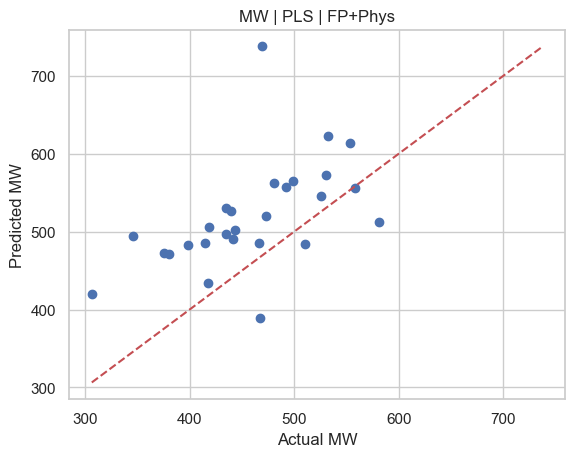

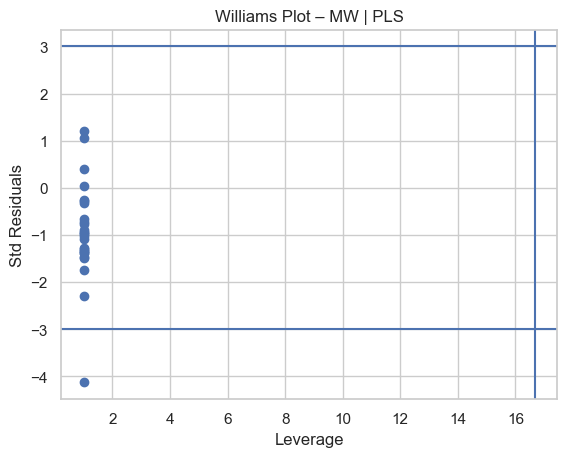

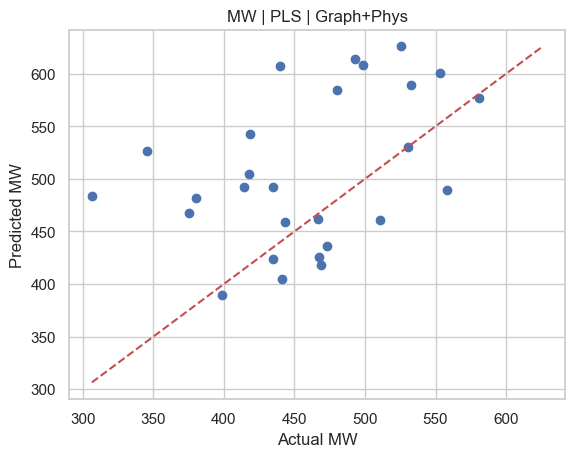

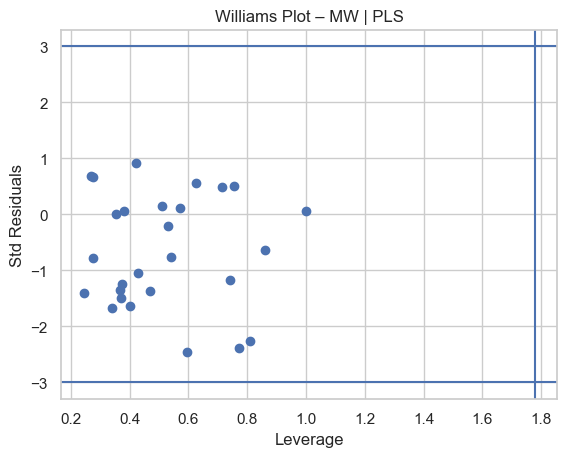

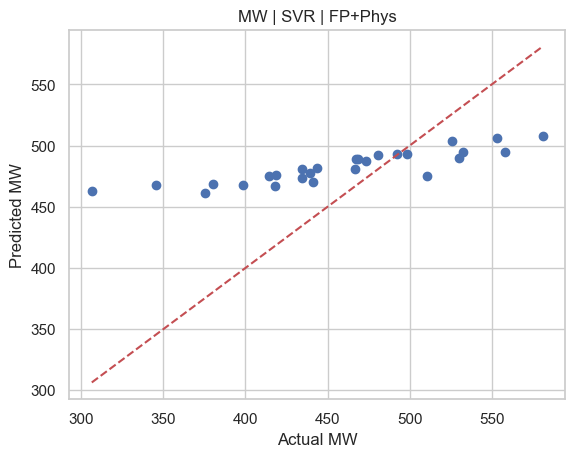

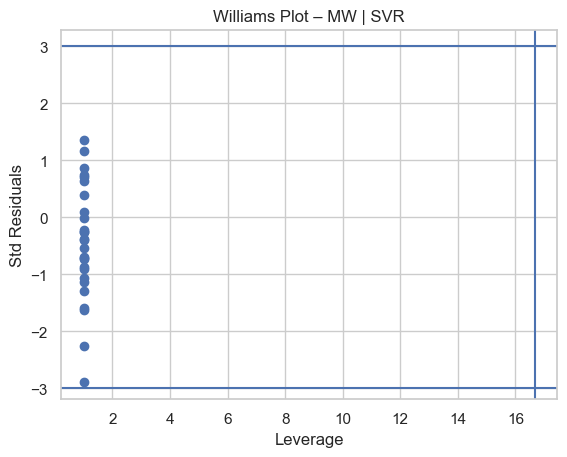

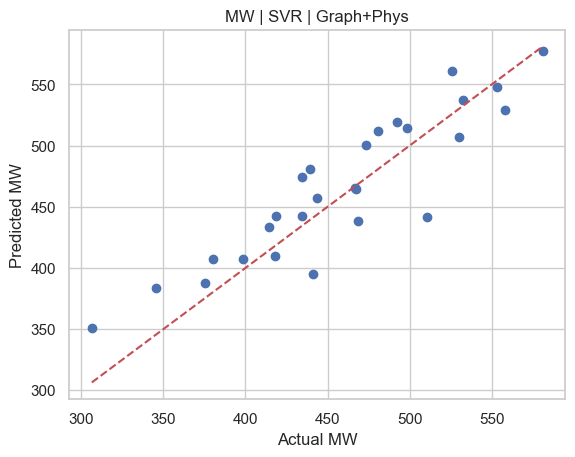

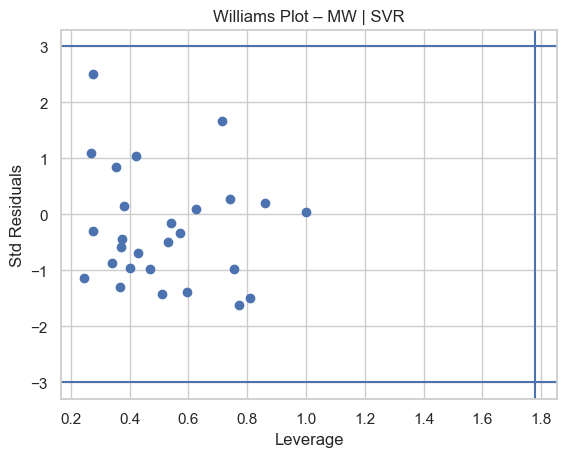

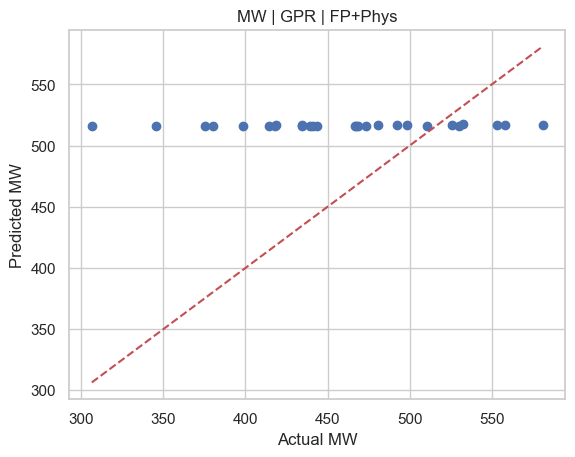

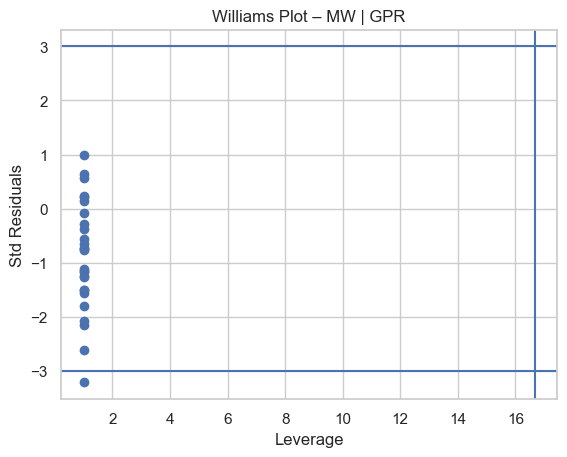

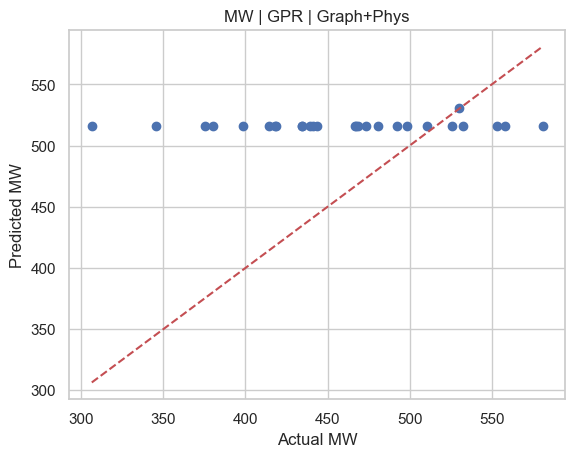

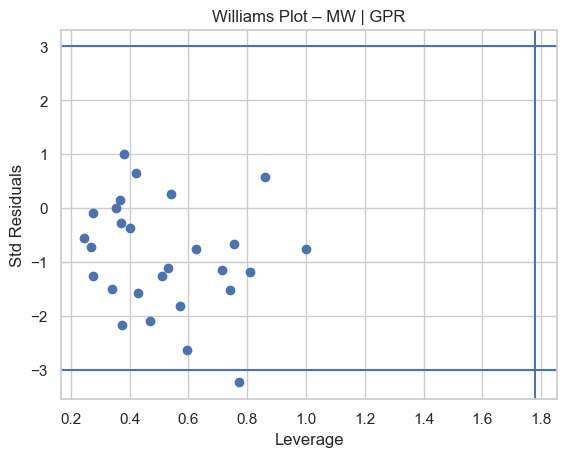

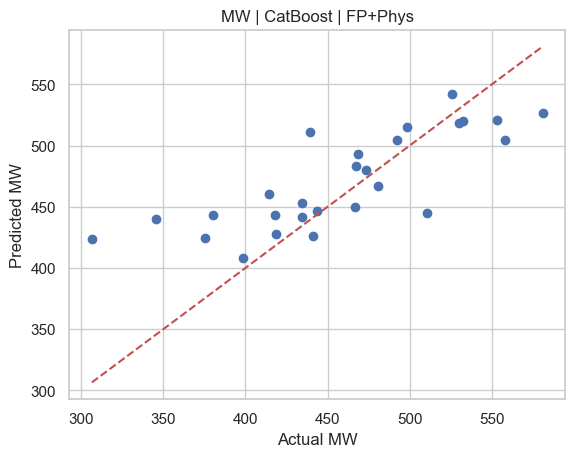

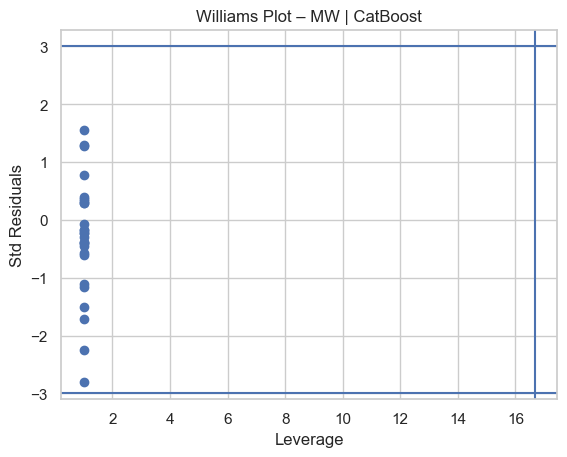

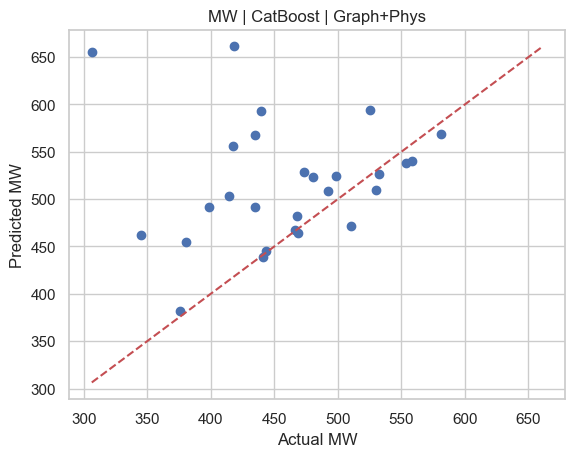

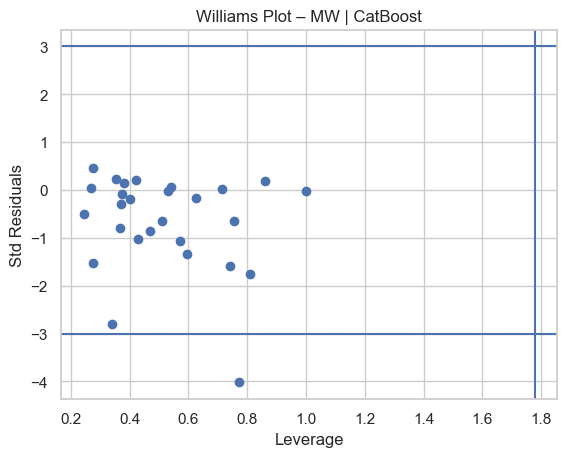

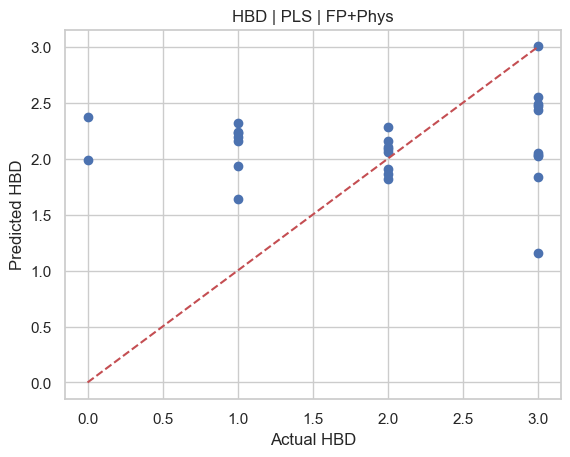

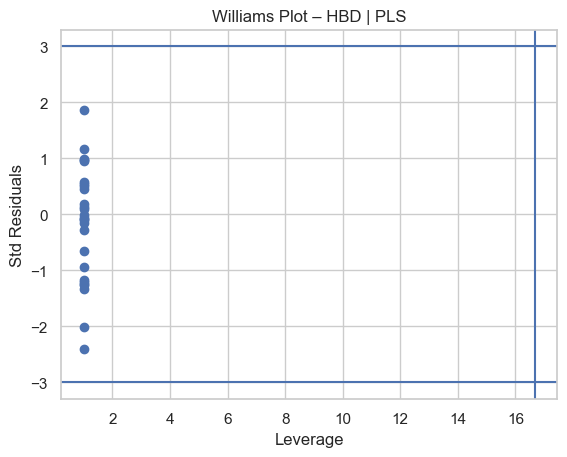

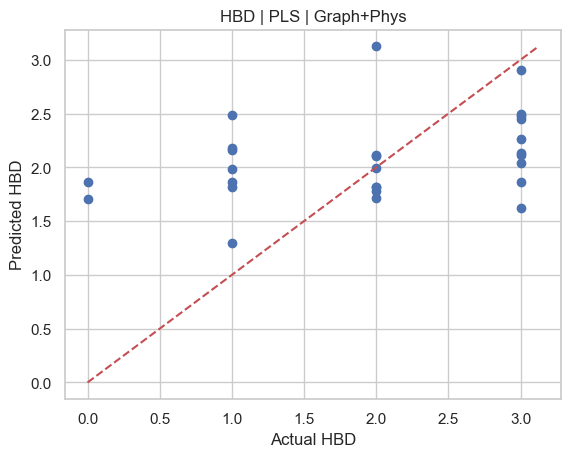

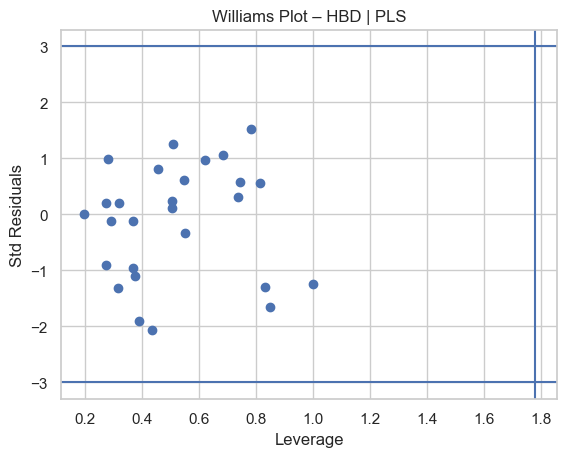

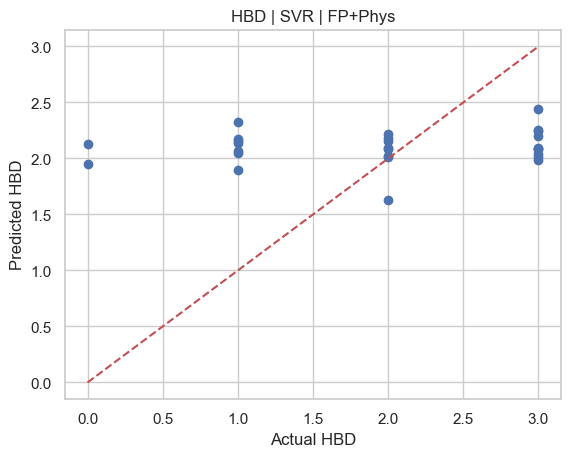

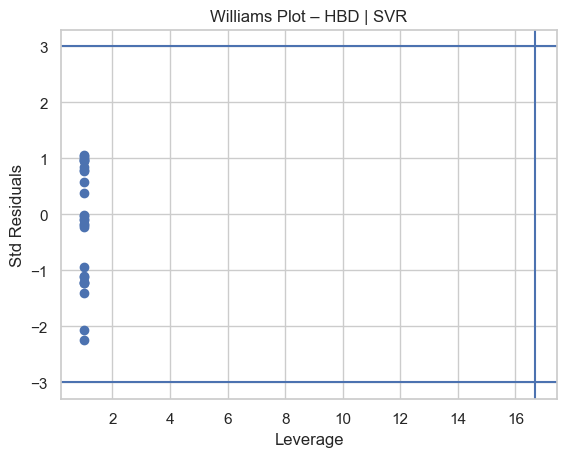

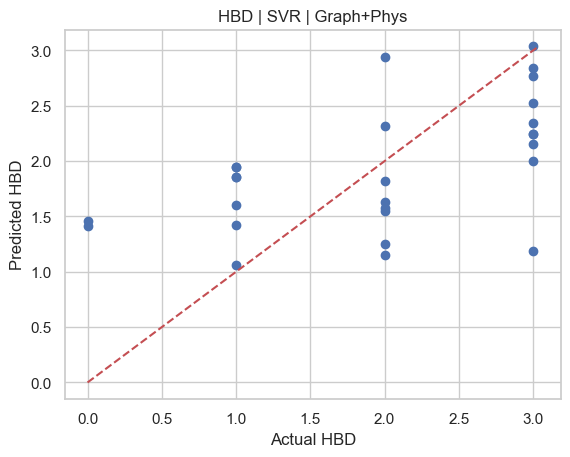

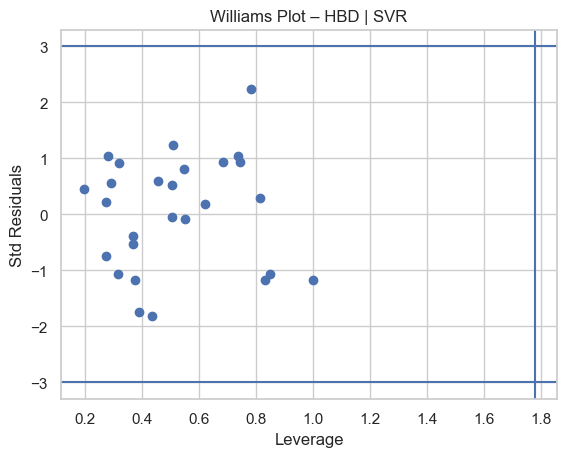

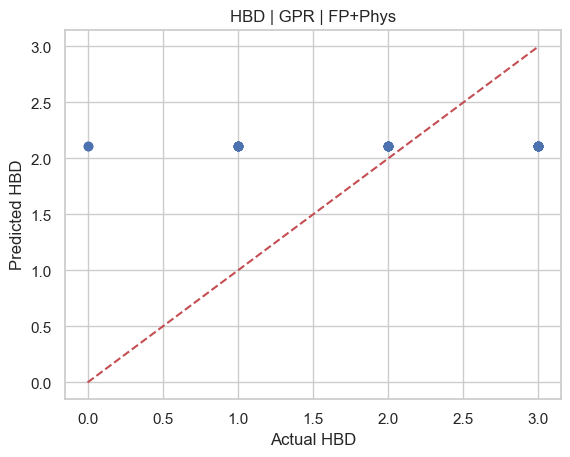

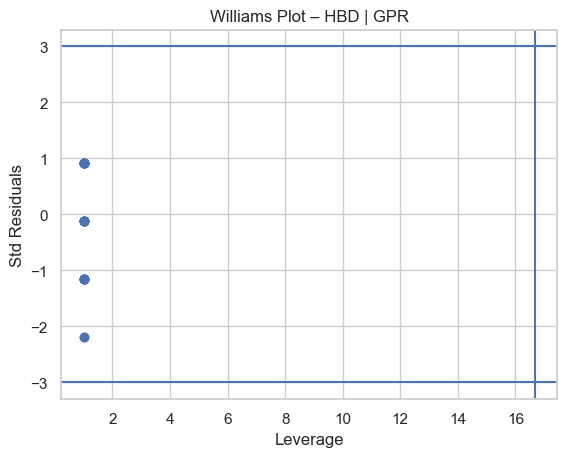

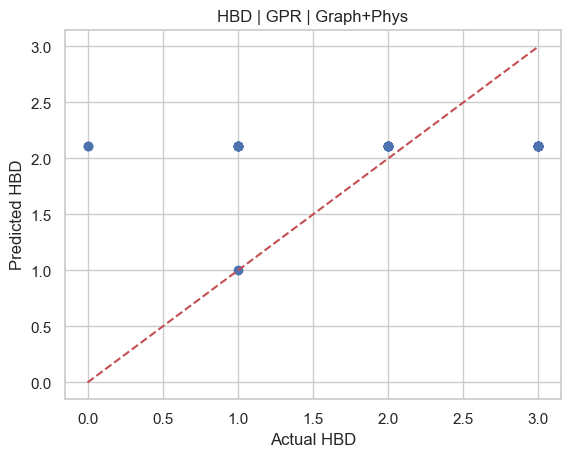

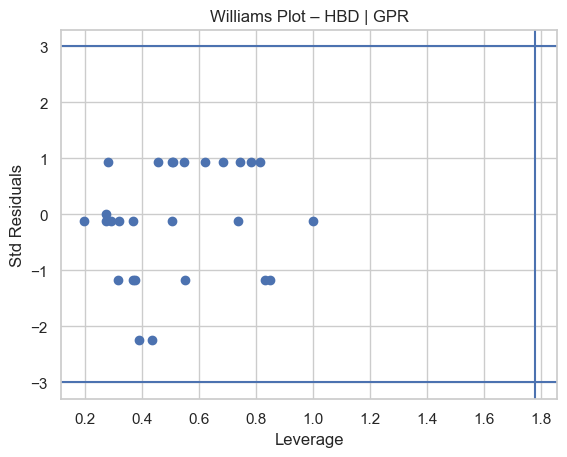

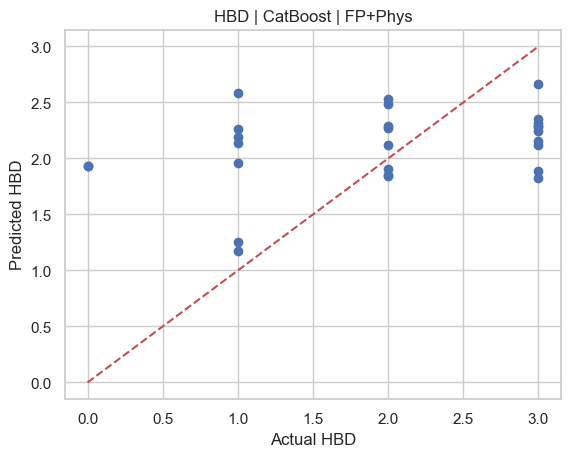

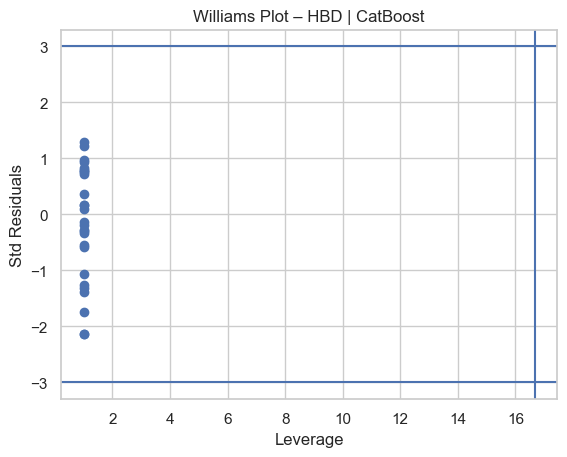

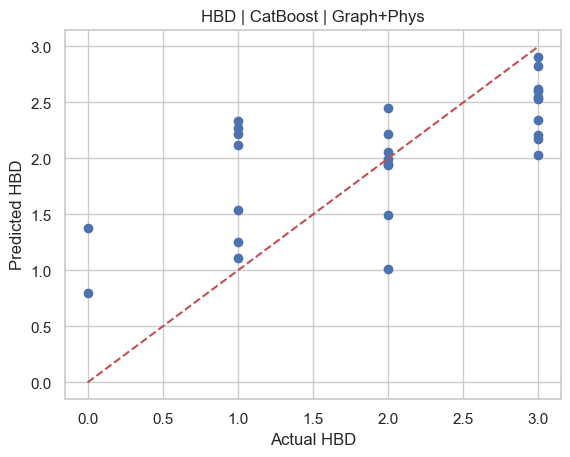

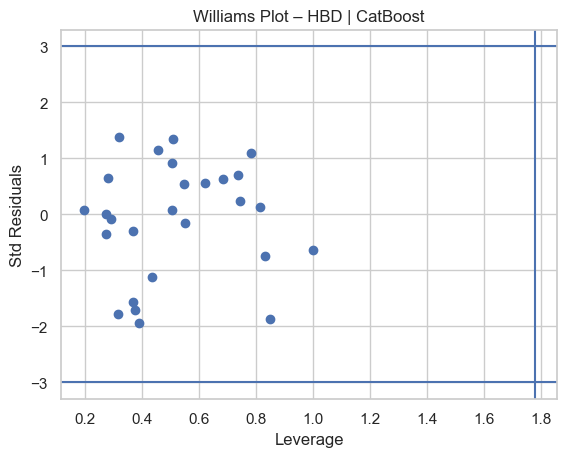

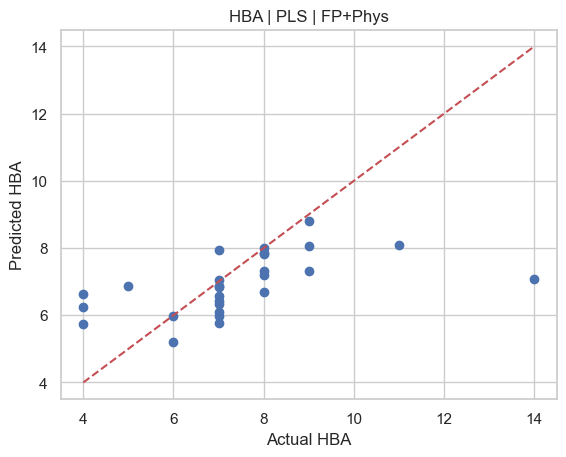

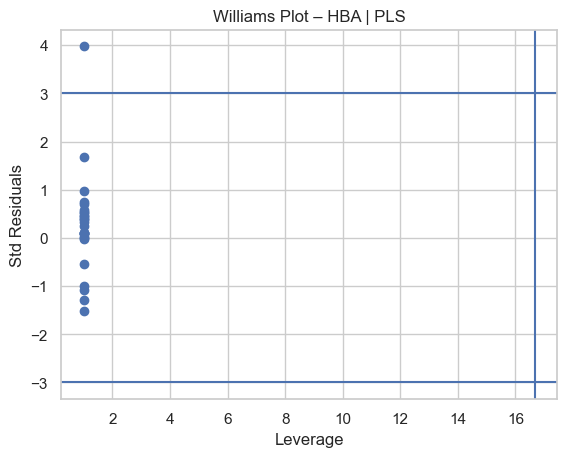

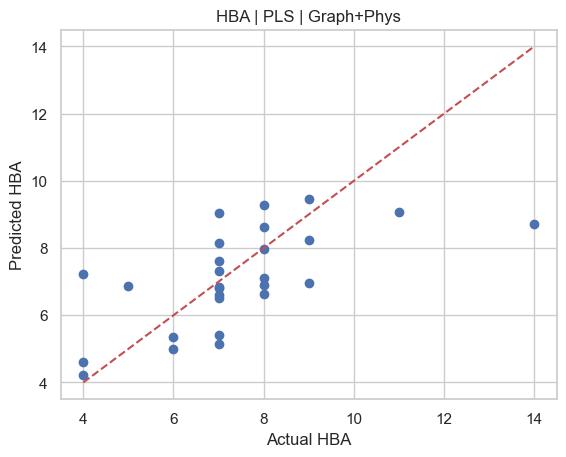

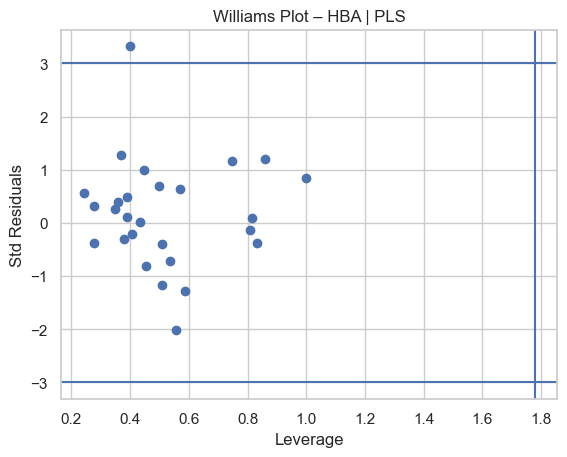

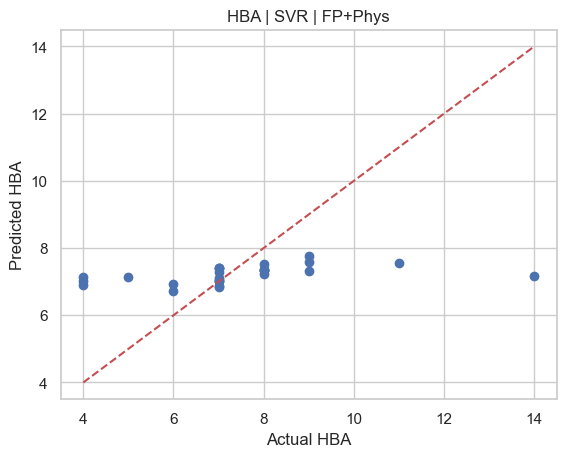

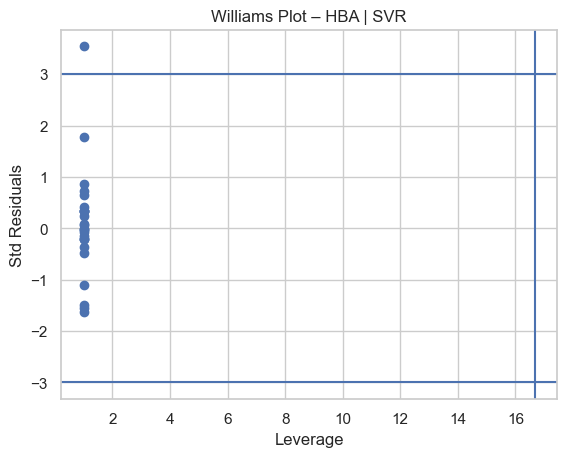

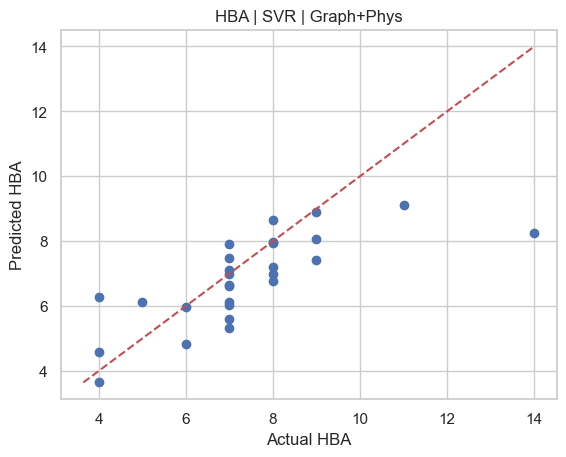

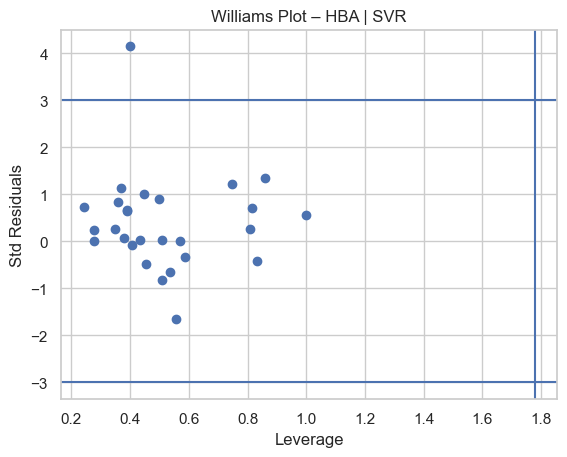

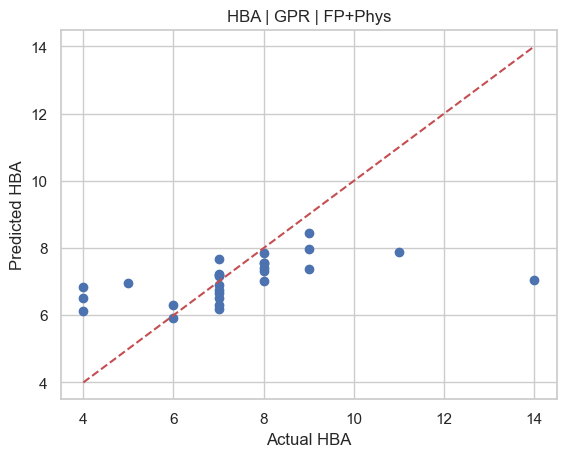

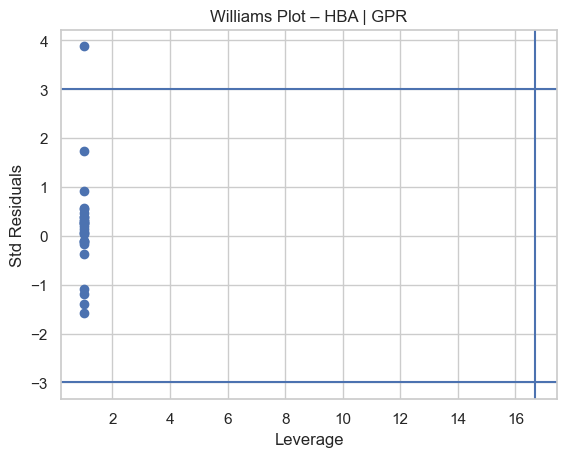

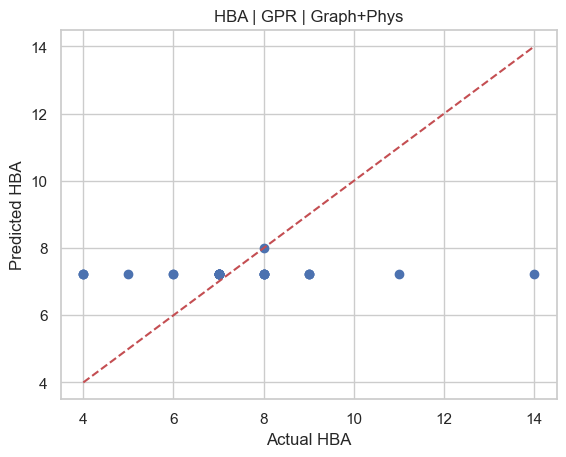

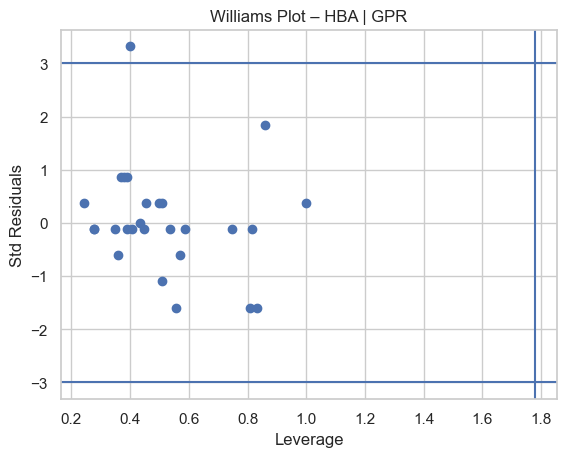

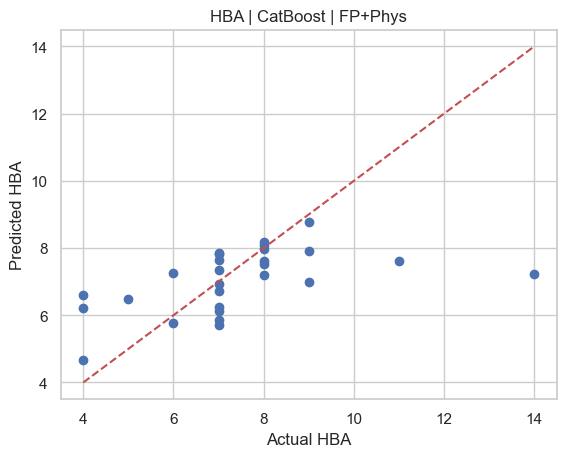

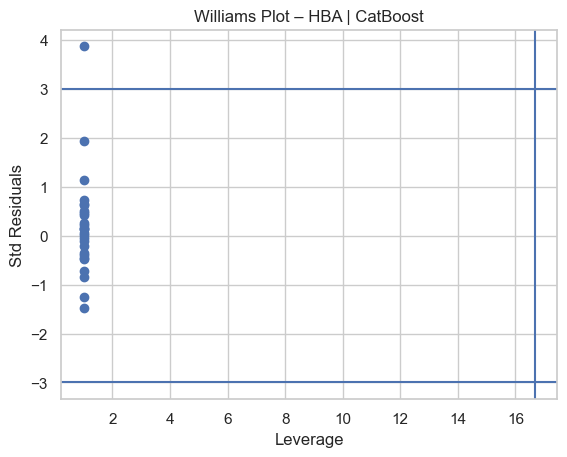

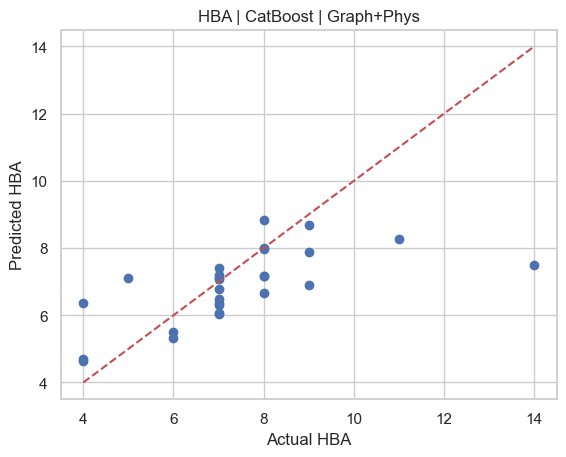

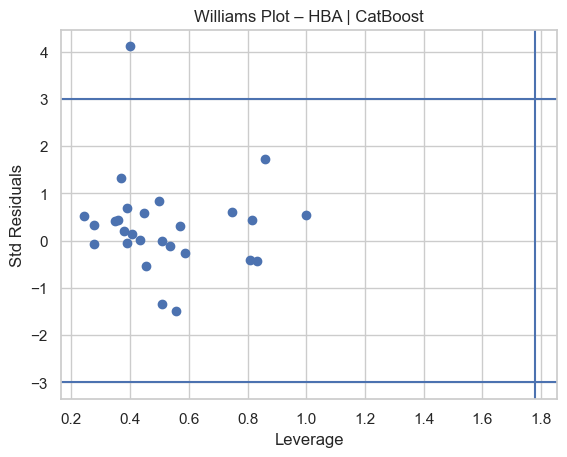

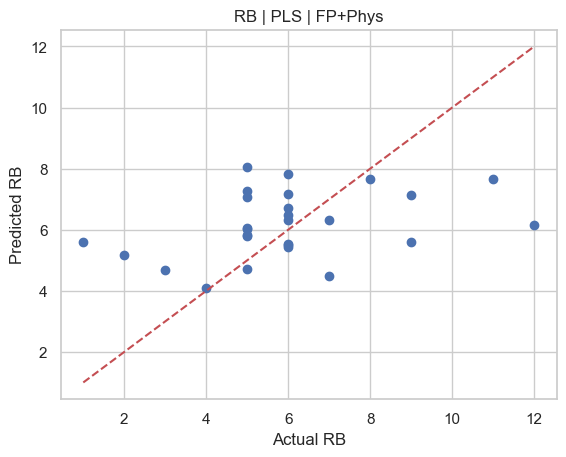

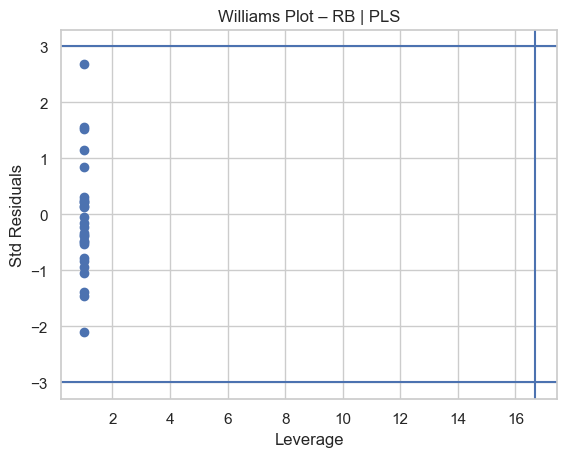

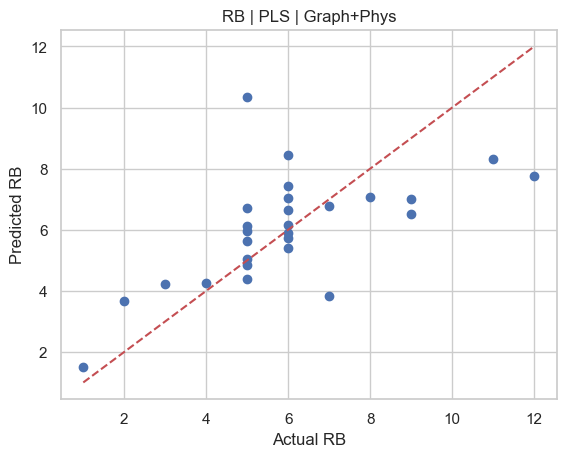

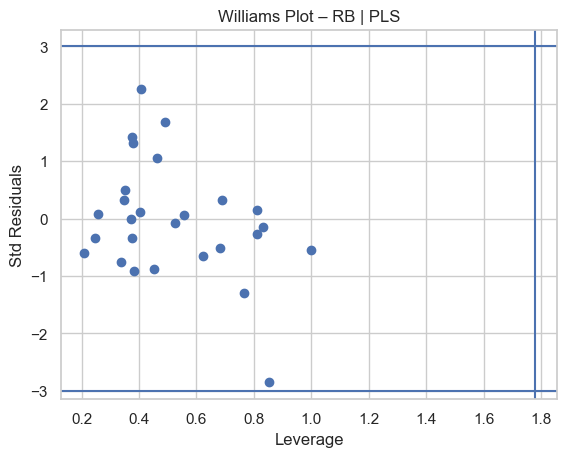

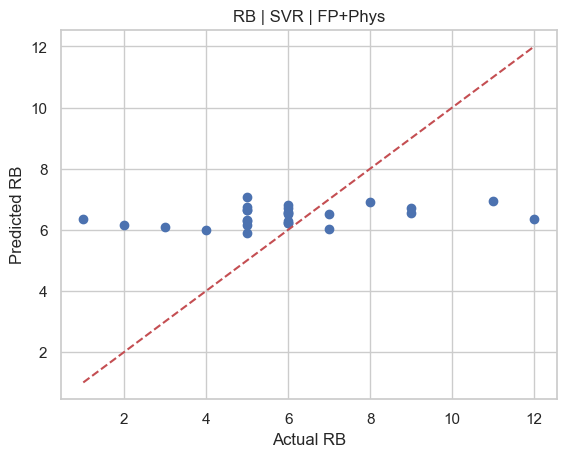

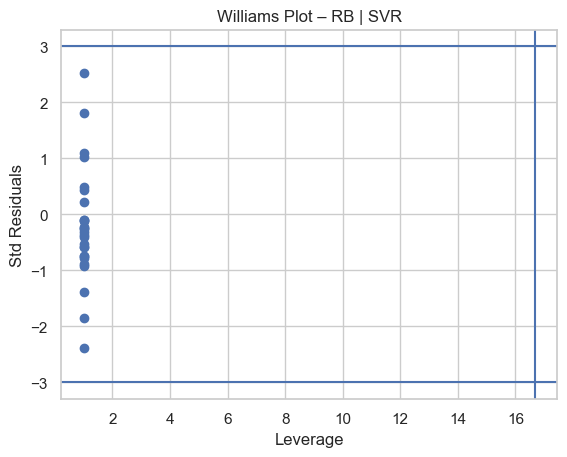

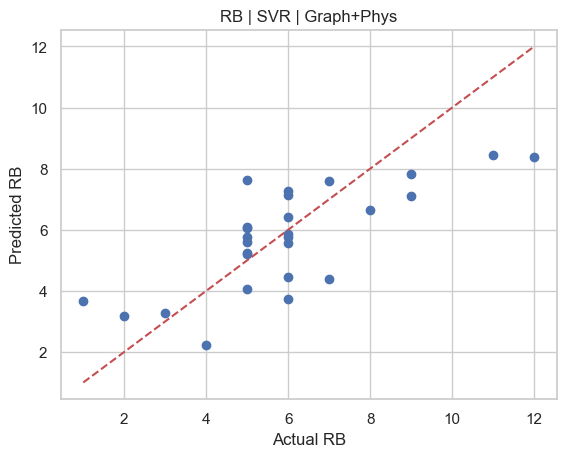

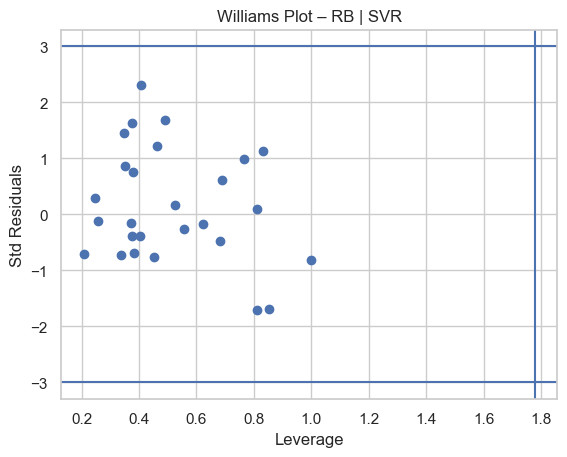

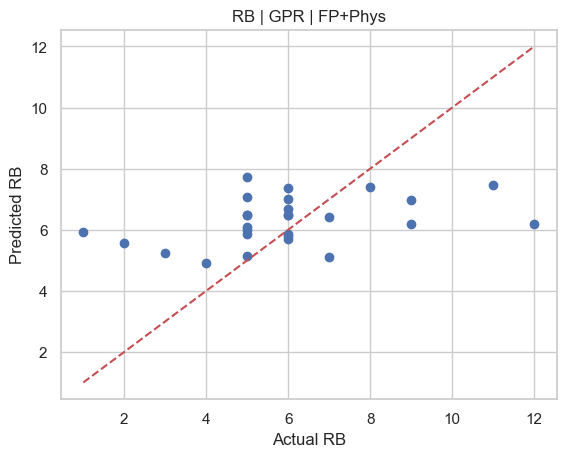

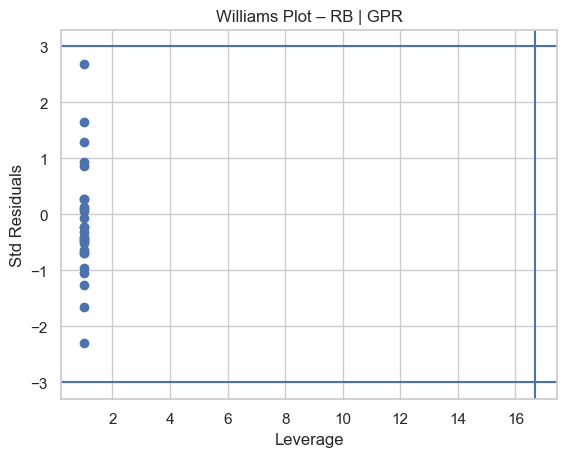

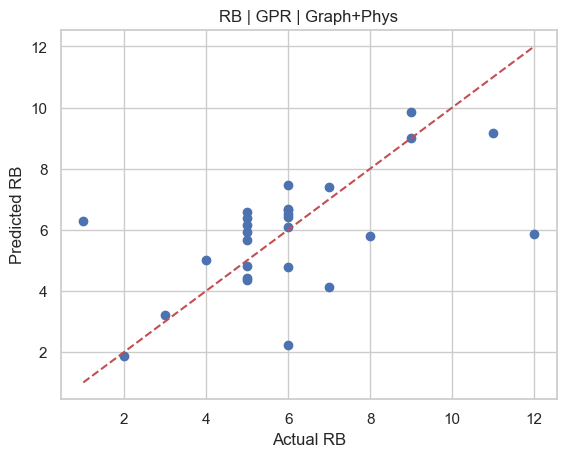

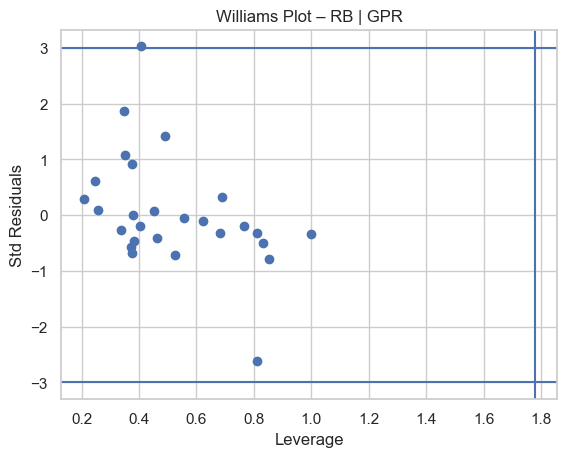

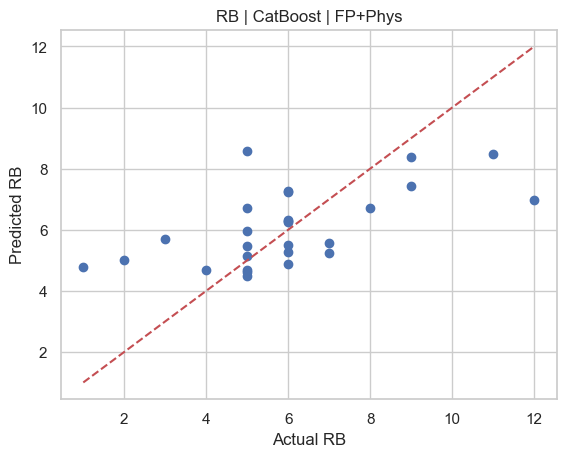

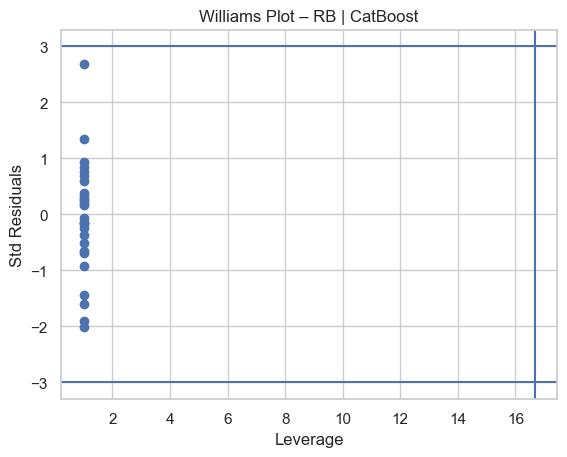

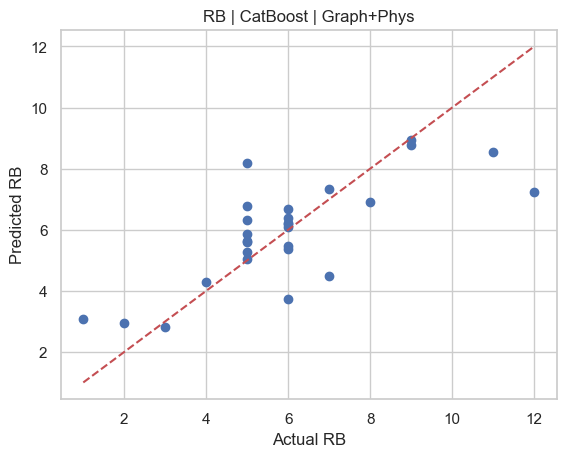

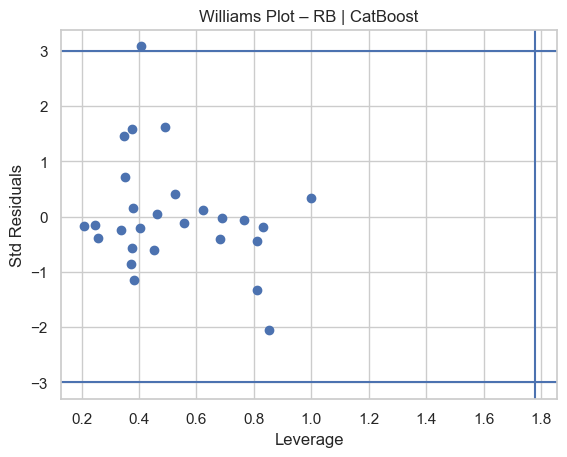

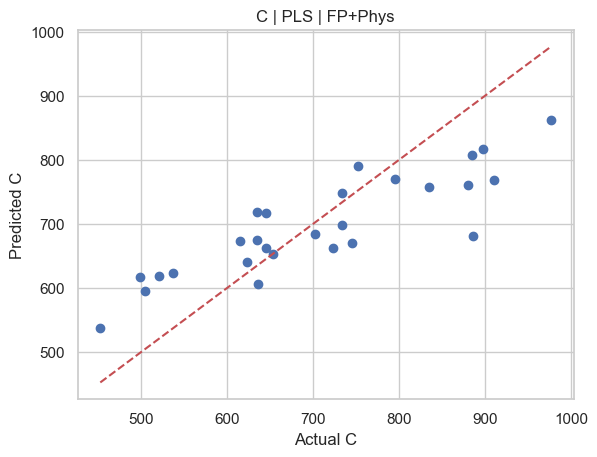

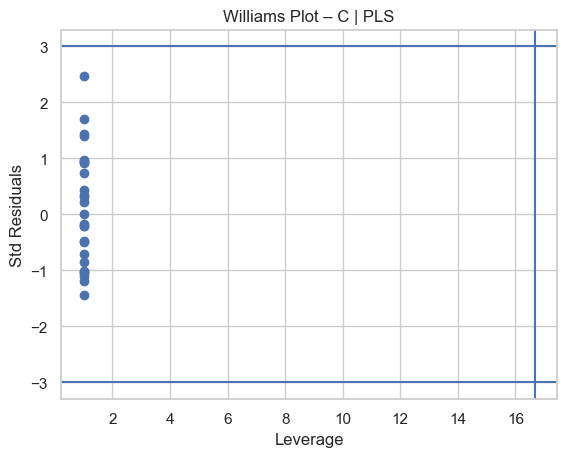

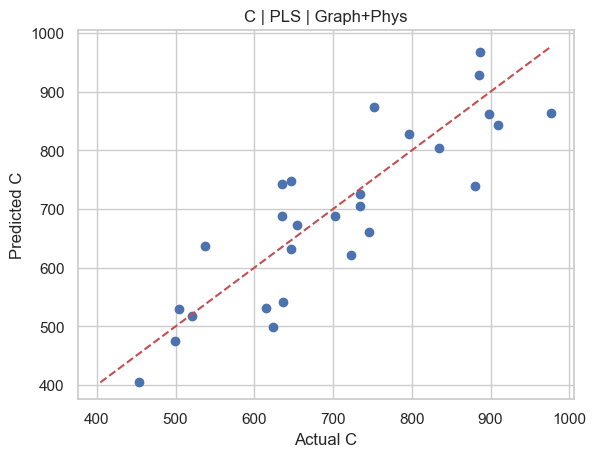

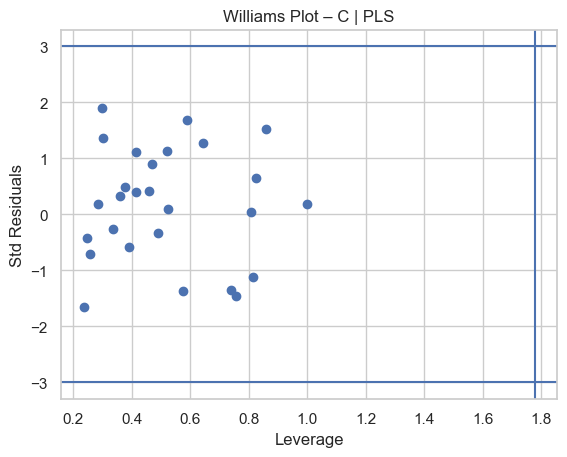

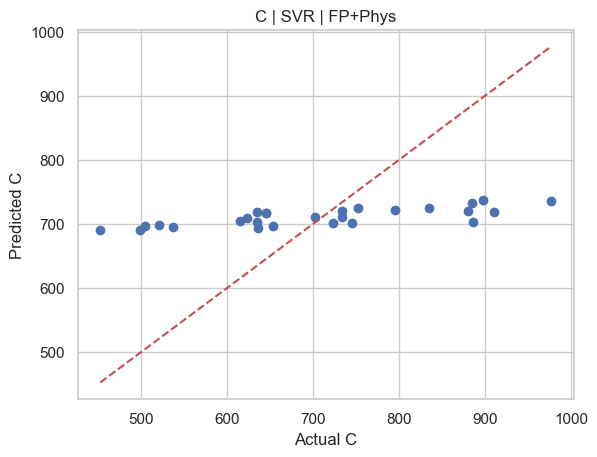

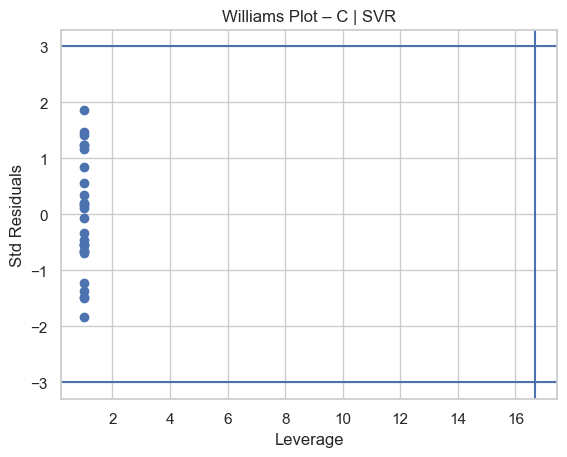

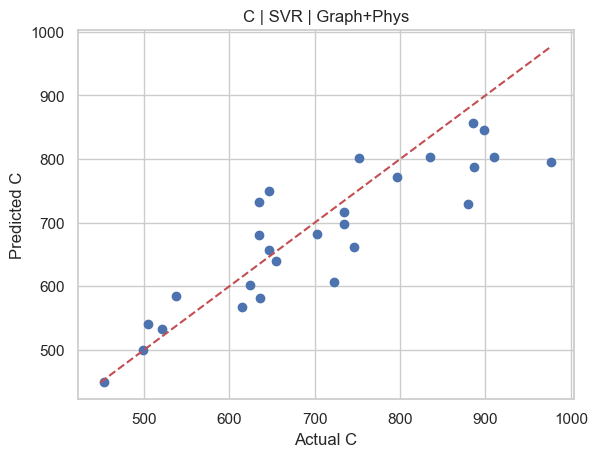

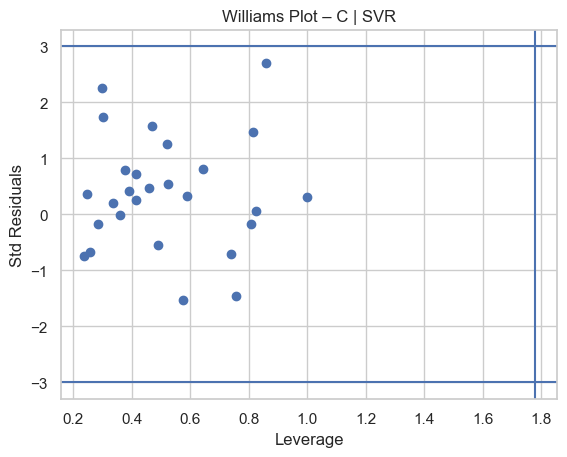

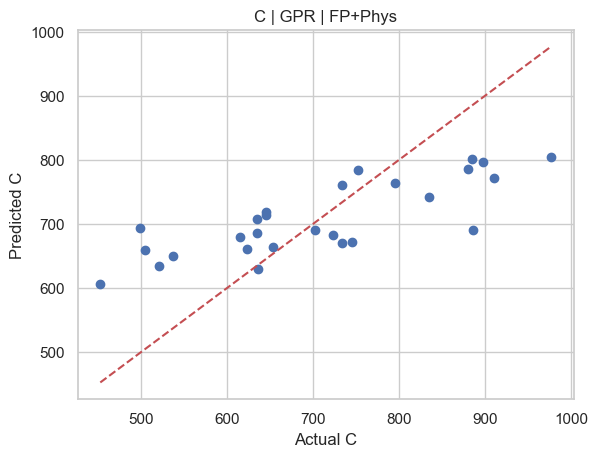

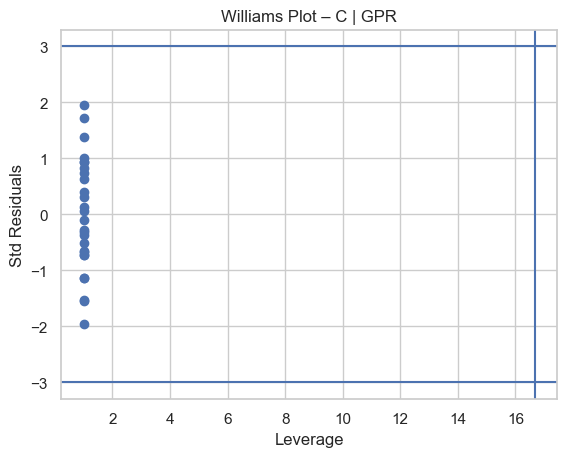

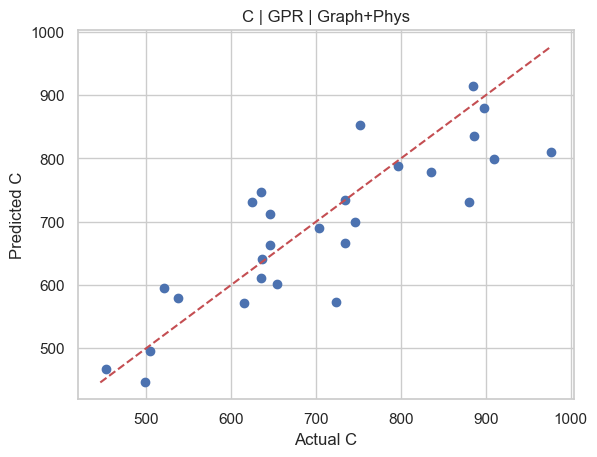

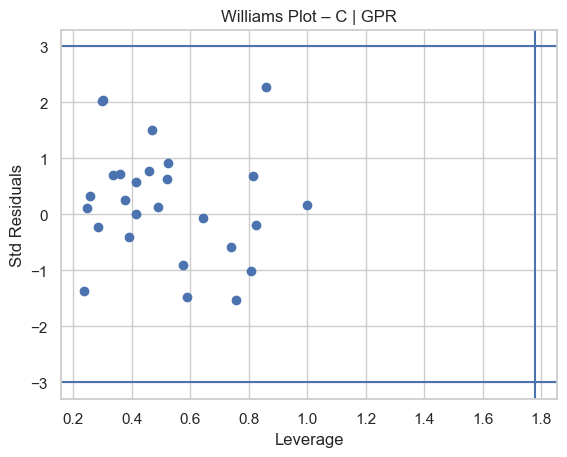

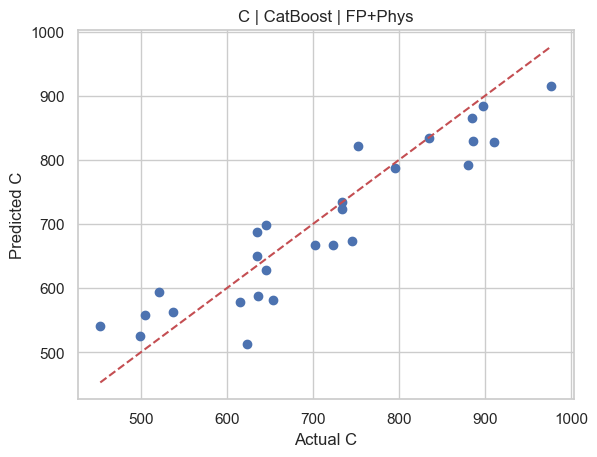

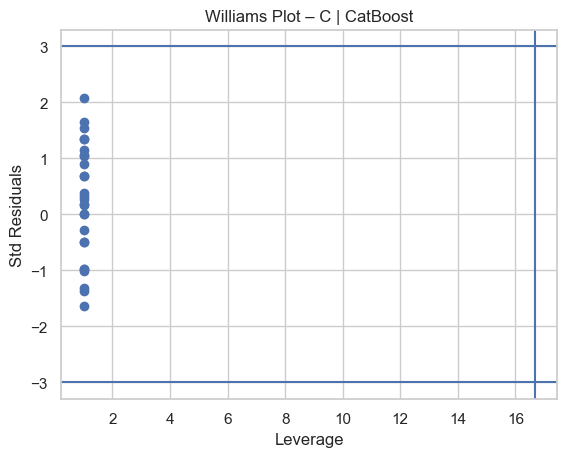

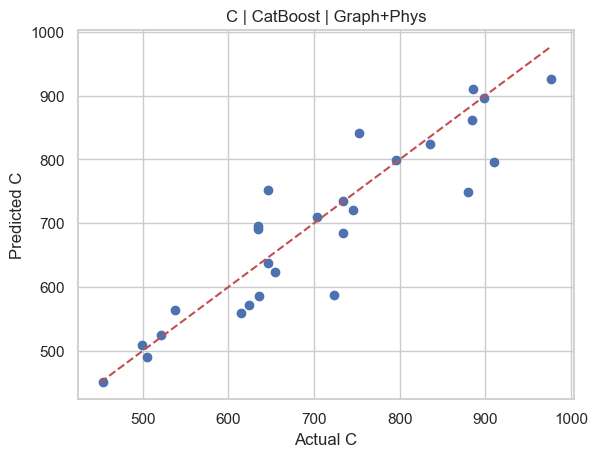

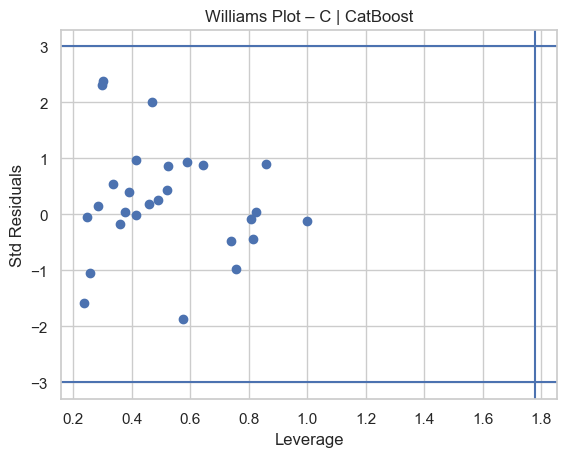

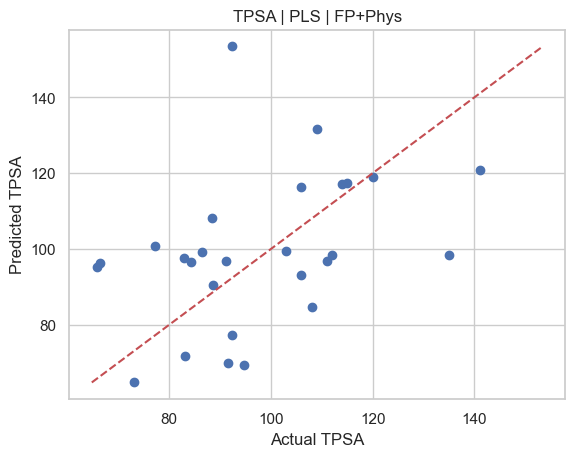

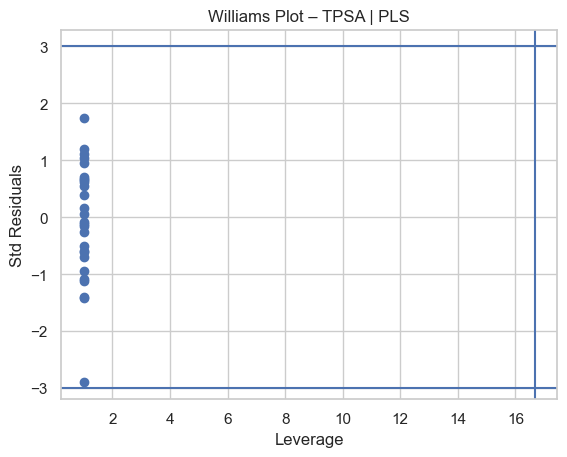

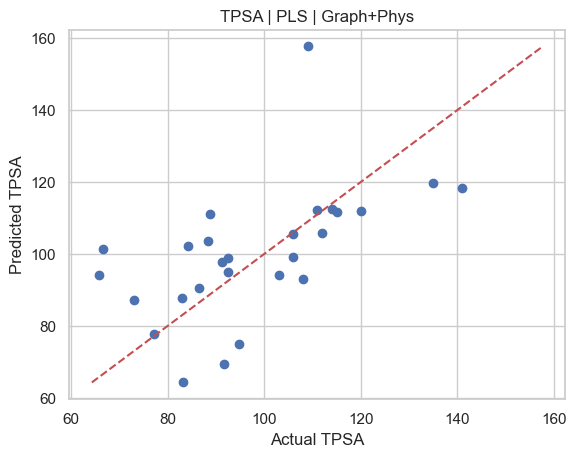

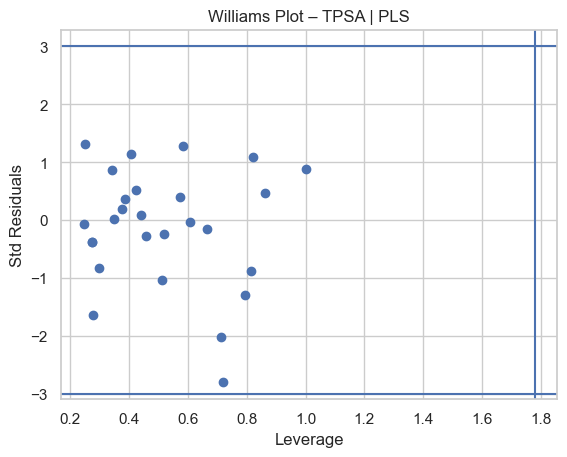

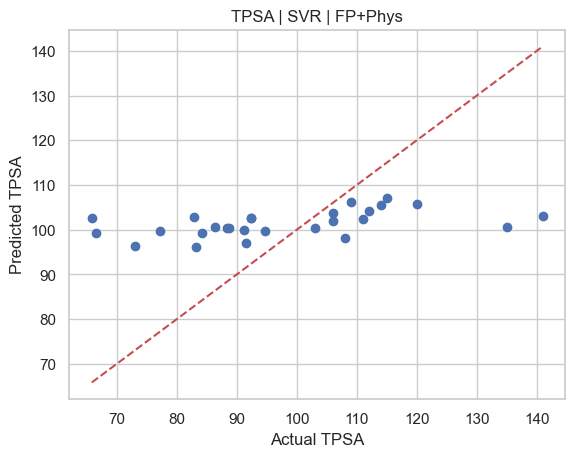

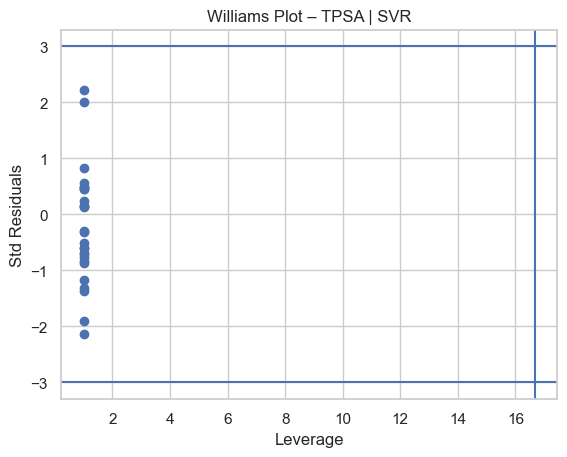

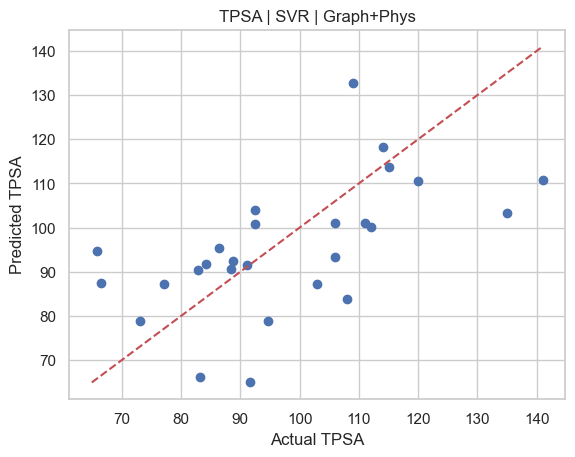

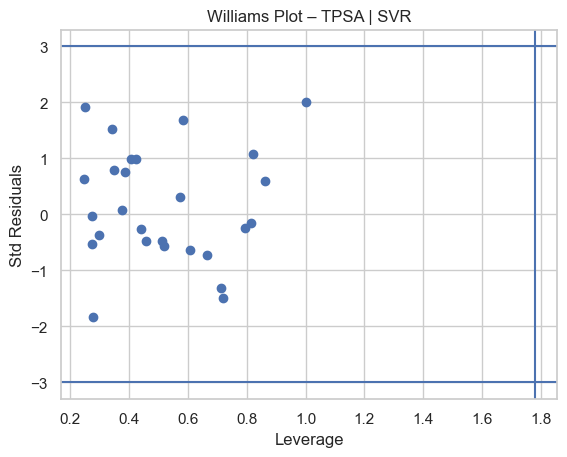

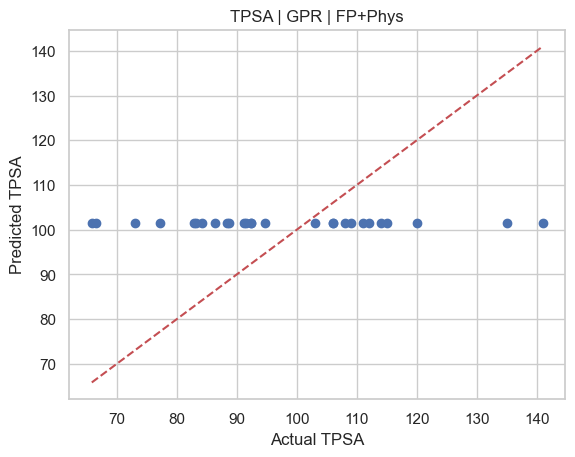

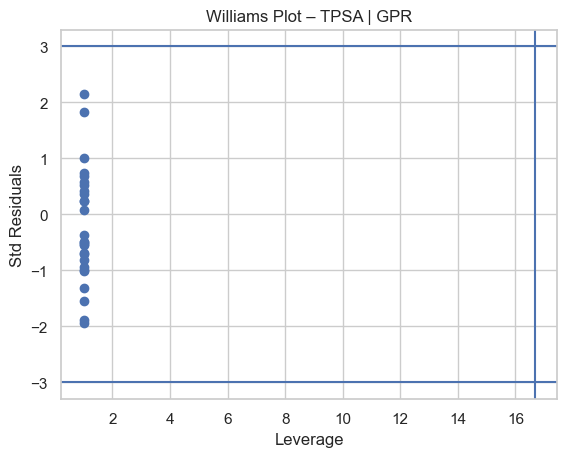

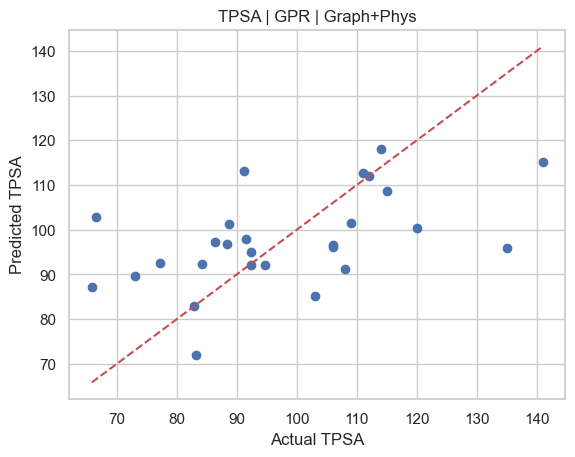

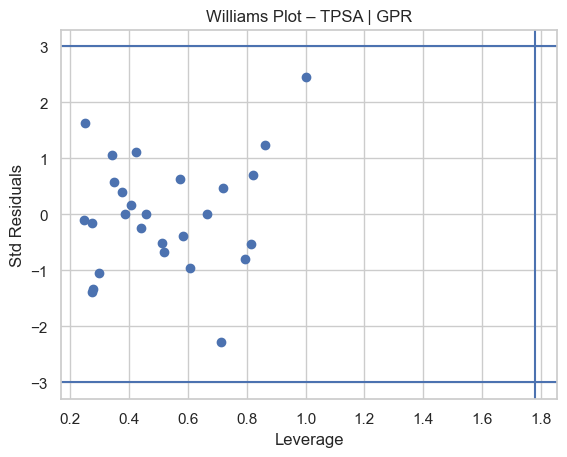

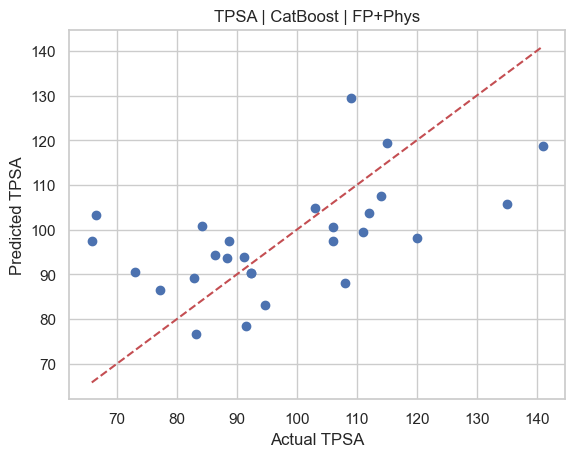

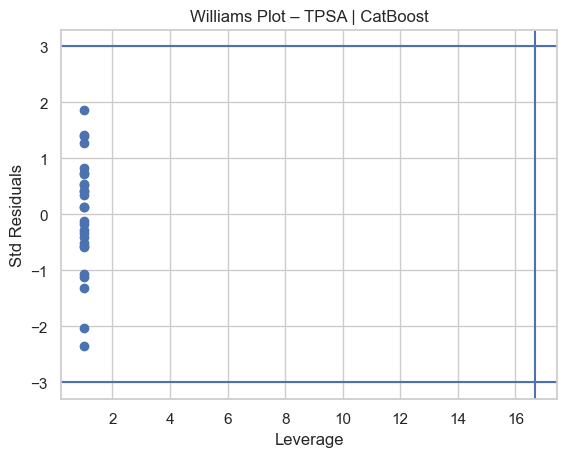

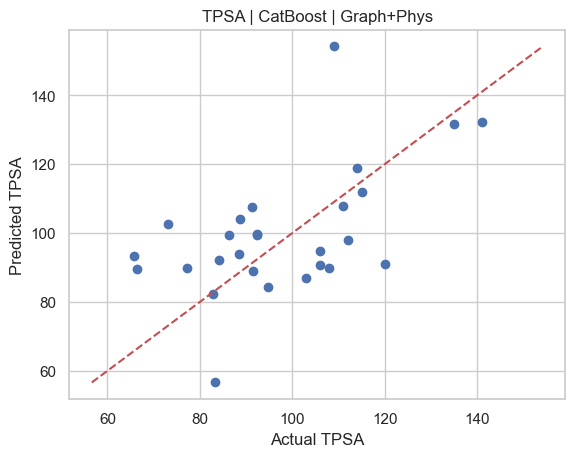

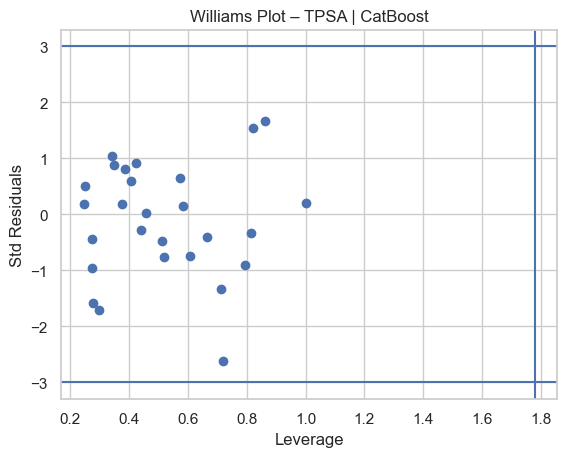

   Property     Model    Pipeline     R2_CV    R2_ext        Q2_ext  \
46     TPSA  CatBoost     FP+Phys  0.367355  0.279412  3.070690e-01   
45     TPSA       GPR  Graph+Phys  0.045709  0.252748  2.814285e-01   
43     TPSA       SVR  Graph+Phys  0.425302  0.244685  2.736748e-01   
47     TPSA  CatBoost  Graph+Phys  0.380188  0.107257  1.415219e-01   
41     TPSA       PLS  Graph+Phys  0.170103  0.100063  1.346038e-01   
42     TPSA       SVR     FP+Phys  0.070472  0.095006  1.297407e-01   
44     TPSA       GPR     FP+Phys -0.043359 -0.039913  2.997602e-15   
40     TPSA       PLS     FP+Phys  0.427972 -0.309079 -2.588349e-01   
31       RB  CatBoost  Graph+Phys  0.389546  0.559122  5.791734e-01   
27       RB       SVR  Graph+Phys  0.417740  0.542388  5.632001e-01   
25       RB       PLS  Graph+Phys -0.479580  0.353212  3.826280e-01   
30       RB  CatBoost     FP+Phys  0.345374  0.351851  3.813288e-01   
29       RB       GPR  Graph+Phys  0.201136  0.241818  2.762997e-01   
28    

In [3]:
# ============================================================
# COMPLETE MULTI-PROPERTY QSPR / ML PIPELINE
# Option A: One Property → One Model
# Enhanced with CV-R2, Hyperparameter Tuning & Accuracy Boost
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

from scipy.stats import pearsonr, spearmanr
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_excel(
    "D:/Phd/PhD/Papers on topological indices/Anti cancer Kinas inhibitor/Data/SMILES.xlsx"
)

# ============================================================
# 2. CLEAN SMILES
# ============================================================

def clean_smiles(s):
    if not isinstance(s, str):
        return None
    return s.replace("\xa0", "").strip().lstrip(":")

def safe_mol(sm):
    try:
        return Chem.MolFromSmiles(sm)
    except:
        return None

df["SMILES"] = df["SMILES"].apply(clean_smiles)
df["Mol"] = df["SMILES"].apply(safe_mol)
df = df[df["Mol"].notnull()].reset_index(drop=True)

# ============================================================
# 3. CLEAN PROPERTIES
# ============================================================

properties = ["MW","HBD","HBA","RB","C","TPSA","logP","Solubility","pKa"]

for c in properties:
    if c in df.columns:
        df[c] = df[c].astype(str).str.replace(",", ".").astype(float)

# ============================================================
# 4. GRAPH + TOPOLOGICAL INDICES
# ============================================================

def mol_to_graph(m):
    G = nx.Graph()
    for a in m.GetAtoms():
        G.add_node(a.GetIdx())
    for b in m.GetBonds():
        G.add_edge(b.GetBeginAtomIdx(), b.GetEndAtomIdx())
    return G

def sombor_index(G):
    return sum((G.degree(u)**2 + G.degree(v)**2)**0.5 for u,v in G.edges())

def szeged_index(G):
    s = 0
    for u,v in G.edges():
        nu = nv = 0
        for n in G.nodes():
            try:
                du = nx.shortest_path_length(G, n, u)
                dv = nx.shortest_path_length(G, n, v)
                if du < dv: nu += 1
                elif dv < du: nv += 1
            except:
                pass
        s += nu * nv
    return s

df["Graph"] = df["Mol"].apply(mol_to_graph)
df["SO"] = df["Graph"].apply(sombor_index)
df["Sz"] = df["Graph"].apply(szeged_index)

# ============================================================
# 5. MORGAN FP + PCA
# ============================================================

def morgan_fp(sm, n=2048):
    m = safe_mol(sm)
    if m is None:
        return np.zeros(n)
    return np.array(AllChem.GetMorganFingerprintAsBitVect(m, 3, nBits=n))

X_fp = np.vstack(df["SMILES"].apply(morgan_fp))
X_fp = VarianceThreshold(0.002).fit_transform(X_fp)
X_fp = StandardScaler().fit_transform(X_fp)

pca = PCA(n_components=min(150, X_fp.shape[0]-1), random_state=42)
X_fp = pca.fit_transform(X_fp)

# ============================================================
# 6. GRAPH EMBEDDINGS
# ============================================================

def graph_embed(G):
    return np.array([
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.average_clustering(G) if G.number_of_nodes()>1 else 0,
        nx.density(G),
        np.mean([d for _,d in G.degree()]),
        np.std([d for _,d in G.degree()]),
        nx.transitivity(G),
        nx.number_connected_components(G)
    ])

X_graph = np.vstack(df["Graph"].apply(graph_embed))

# ============================================================
# 7. MODELS + HYPERPARAMETERS
# ============================================================

models = {
    "PLS": (
        Pipeline([("sc", StandardScaler()), ("pls", PLSRegression())]),
        {"pls__n_components":[2,4,6,8]}
    ),
    "SVR": (
        Pipeline([("sc", StandardScaler()), ("svr", SVR())]),
        {"svr__C":[10,50,100], "svr__gamma":[0.01,0.05], "svr__epsilon":[0.01,0.05]}
    ),
    "GPR": (
        Pipeline([("sc", StandardScaler()),
                  ("gpr", GaussianProcessRegressor(normalize_y=True))]),
        {"gpr__kernel":[RBF(1.0)+WhiteKernel(1e-5),
                        RBF(2.0)+WhiteKernel(1e-6)]}
    ),
    "CatBoost": (
        CatBoostRegressor(verbose=0, random_seed=42),
        {"depth":[4,6], "learning_rate":[0.03,0.05], "iterations":[400,600]}
    )
}

# ============================================================
# 8. METRICS
# ============================================================

def evaluate(yte, ypred, ytr):
    r2 = r2_score(yte, ypred)
    rmse = np.sqrt(mean_squared_error(yte, ypred))
    mae = mean_absolute_error(yte, ypred)
    q2 = 1 - np.sum((yte-ypred)**2)/np.sum((yte-np.mean(ytr))**2)
    pr = pearsonr(yte, ypred)[0]
    sr = spearmanr(yte, ypred)[0]
    return r2, q2, rmse, mae, pr, sr

def cv_r2(model, X, y):
    kf = KFold(5, shuffle=True, random_state=42)
    scores = []
    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        scores.append(r2_score(y[te], model.predict(X[te])))
    return np.mean(scores)

# ============================================================
# 9. MAIN LOOP
# ============================================================

results = []

for target in properties:
    if target not in df.columns:
        continue

    desc = [c for c in properties if c!=target and c in df.columns] + ["SO","Sz"]
    data = df.dropna(subset=desc+[target])

    y = data[target].values
    X_phys = data[desc].values

    XA = np.hstack([X_fp[:len(data)], X_phys])
    XB = np.hstack([X_graph[:len(data)], X_phys])

    for name,(model,param) in models.items():
        for label,X in zip(["FP+Phys","Graph+Phys"],[XA,XB]):

            Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42)

            gs = GridSearchCV(model, param, cv=5, scoring="r2")
            gs.fit(Xtr,ytr)

            best = gs.best_estimator_
            ypred = best.predict(Xte).ravel()

            r2,q2,rmse,mae,pr,sr = evaluate(yte,ypred,ytr)
            r2cv = cv_r2(best, Xtr, ytr)

            results.append([target,name,label,r2cv,r2,q2,rmse,mae,pr,sr])

            # Parity
            lims=[min(yte.min(),ypred.min()),max(yte.max(),ypred.max())]
            plt.scatter(yte,ypred); plt.plot(lims,lims,"r--")
            plt.xlabel(f"Actual {target}"); plt.ylabel(f"Predicted {target}")
            plt.title(f"{target} | {name} | {label}")
            plt.show()

            # Williams
            H = Xte @ np.linalg.pinv(Xte.T @ Xte) @ Xte.T
            lev = np.diag(H)
            std = (yte-ypred)/np.std(yte-ypred)
            hstar = 3*(Xte.shape[1]+1)/Xte.shape[0]
            plt.scatter(lev,std); plt.axhline(3); plt.axhline(-3); plt.axvline(hstar)
            plt.title(f"Williams Plot – {target} | {name}")
            plt.xlabel("Leverage"); plt.ylabel("Std Residuals")
            plt.show()

# ============================================================
# 10. RESULTS
# ============================================================

res = pd.DataFrame(results,columns=[
    "Property","Model","Pipeline","R2_CV","R2_ext","Q2_ext",
    "RMSEP","MAE","Pearson_r","Spearman_r"
])

print(res.sort_values(["Property","R2_ext"],ascending=False))



Loading data...
Loaded 143 molecules
✓ MW: 139 values
✓ HBD: 140 values
✓ HBA: 141 values
✓ RB: 142 values
✓ C: 138 values
✓ TPSA: 141 values

Available properties for modeling: ['MW', 'HBD', 'HBA', 'RB', 'C', 'TPSA']

Removing outliers...
  MW: Removed 6 outliers
  HBD: Removed 2 outliers
  HBA: Removed 5 outliers
  RB: Removed 3 outliers
  C: Removed 3 outliers
Removed 19 total outliers
Remaining molecules: 124

CALCULATING MOLECULAR DESCRIPTORS


Calculating descriptors: 100%|██████████| 124/124 [00:00<00:00, 267.48it/s]


Calculated 17 descriptors

Calculating Morgan fingerprints...


Fingerprints: 100%|██████████| 124/124 [00:00<00:00, 1128.89it/s]


Combined features shape: (124, 1041)
Scaling features...
Final feature matrix shape: (124, 1041)

Generating scaffolds for splitting...

ADVANCED QSPR PIPELINE FOR ANTI-CANCER DRUG DESIGN

Dataset contains 124 molecules
Properties to model: ['MW', 'HBD', 'HBA', 'RB', 'C', 'TPSA']

MODELING: MW
  Available data points: 124

Training models for MW...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training MW: 100%|██████████| 5/5 [02:45<00:00, 33.11s/it]


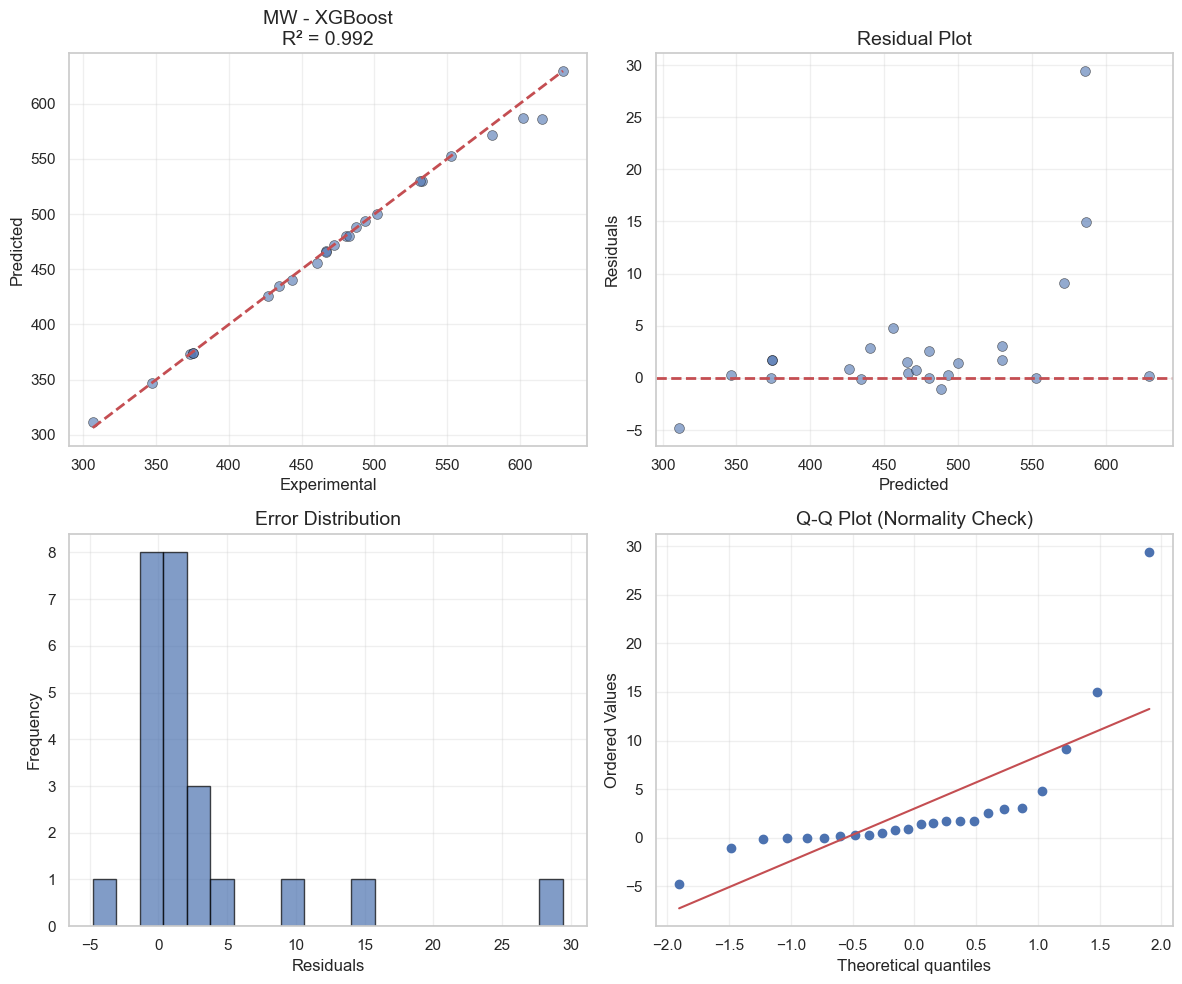


MODELING: HBD
  Available data points: 124

Training models for HBD...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training HBD: 100%|██████████| 5/5 [01:48<00:00, 21.62s/it]


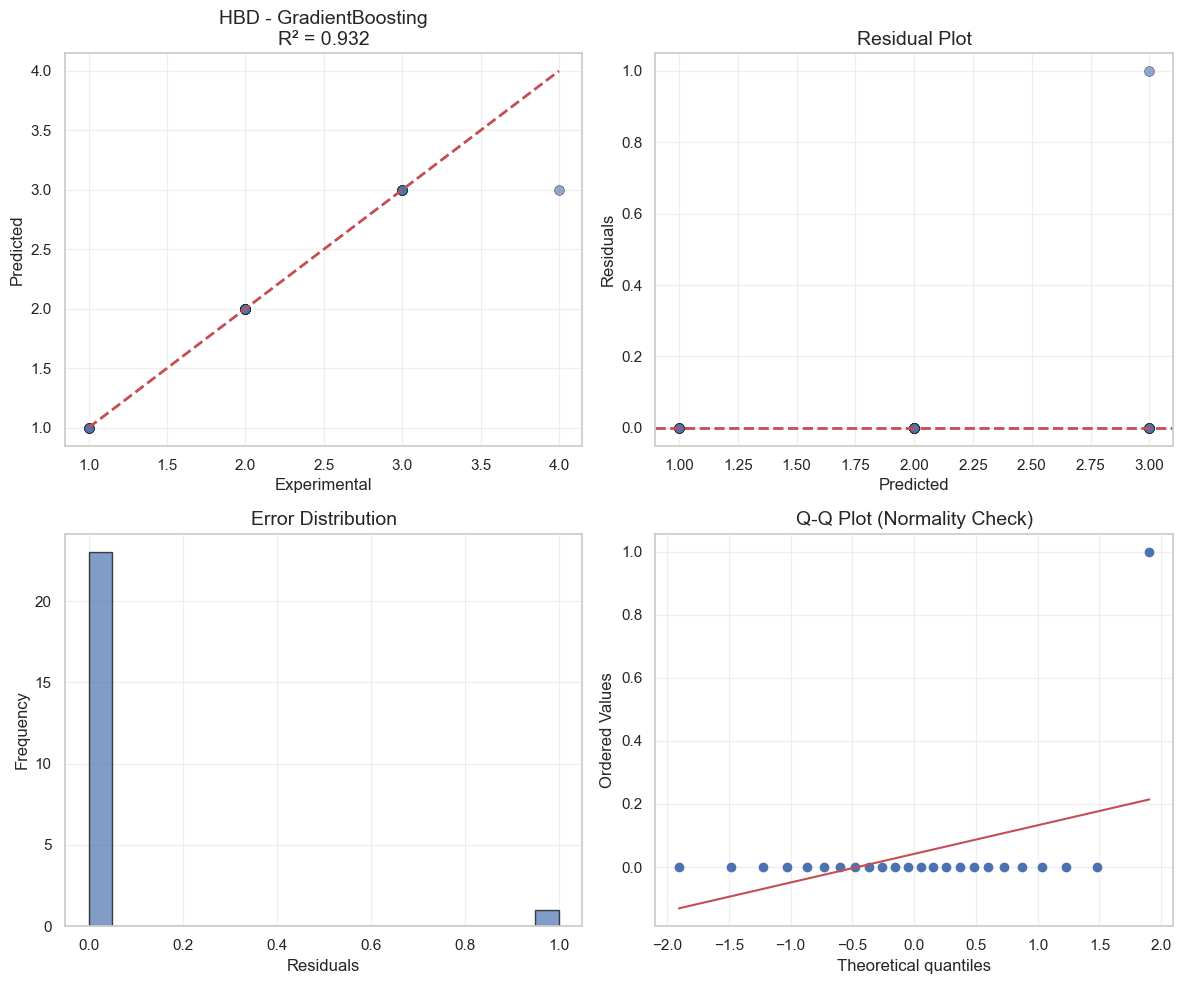


MODELING: HBA
  Available data points: 124

Training models for HBA...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training HBA: 100%|██████████| 5/5 [02:06<00:00, 25.38s/it]


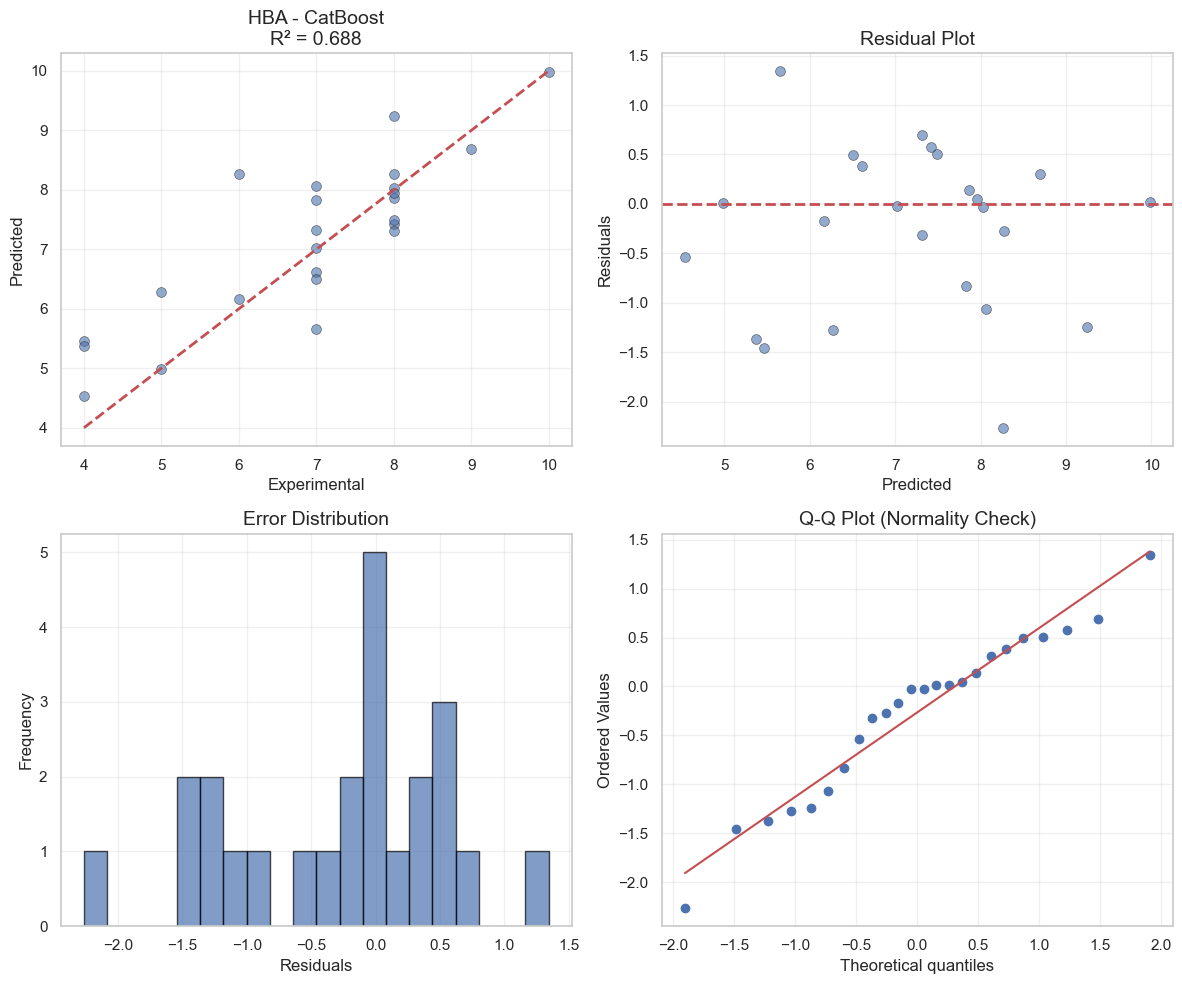


MODELING: RB
  Available data points: 124

Training models for RB...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training RB: 100%|██████████| 5/5 [01:52<00:00, 22.51s/it]


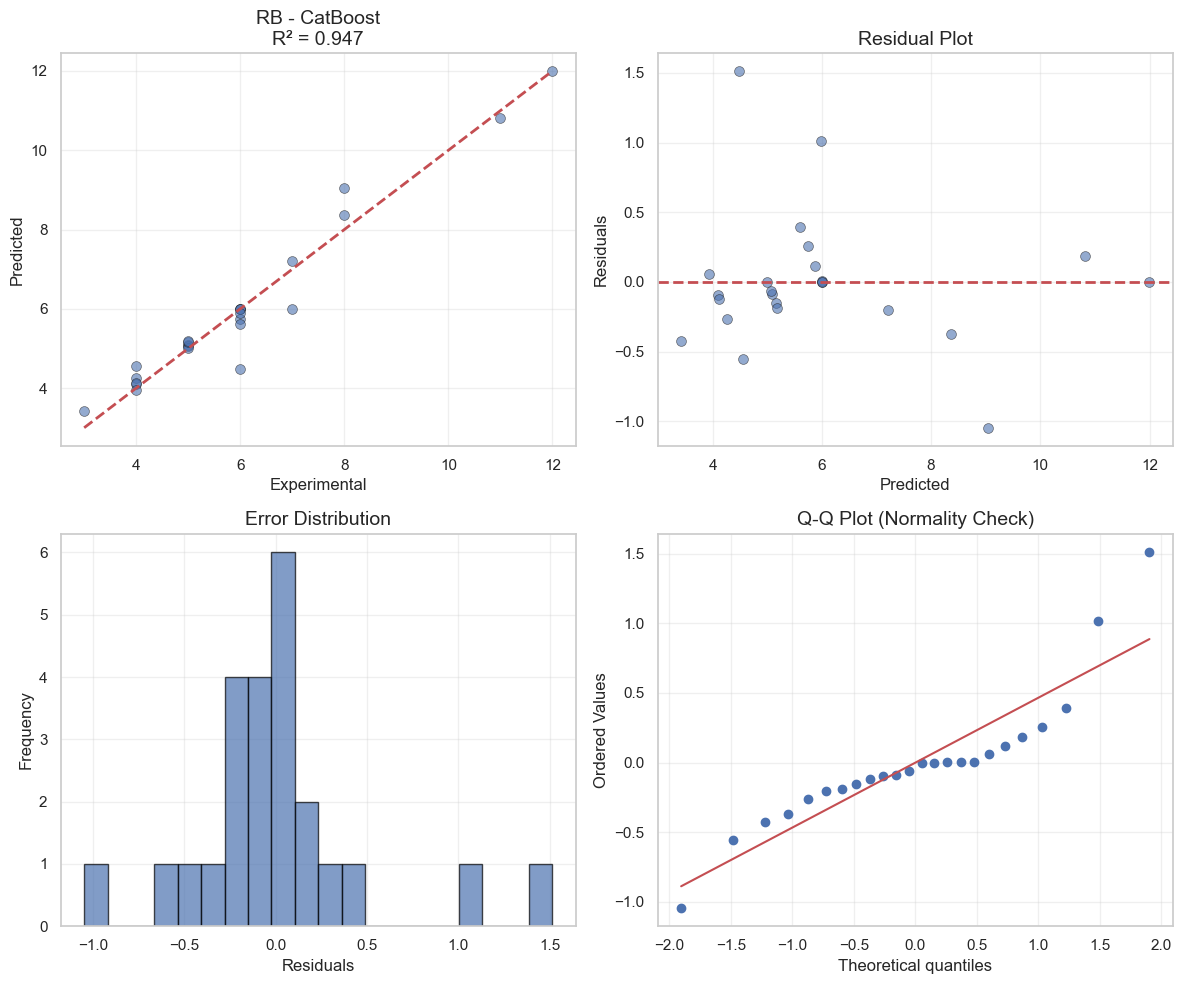


MODELING: C
  Available data points: 124

Training models for C...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training C: 100%|██████████| 5/5 [02:02<00:00, 24.47s/it]


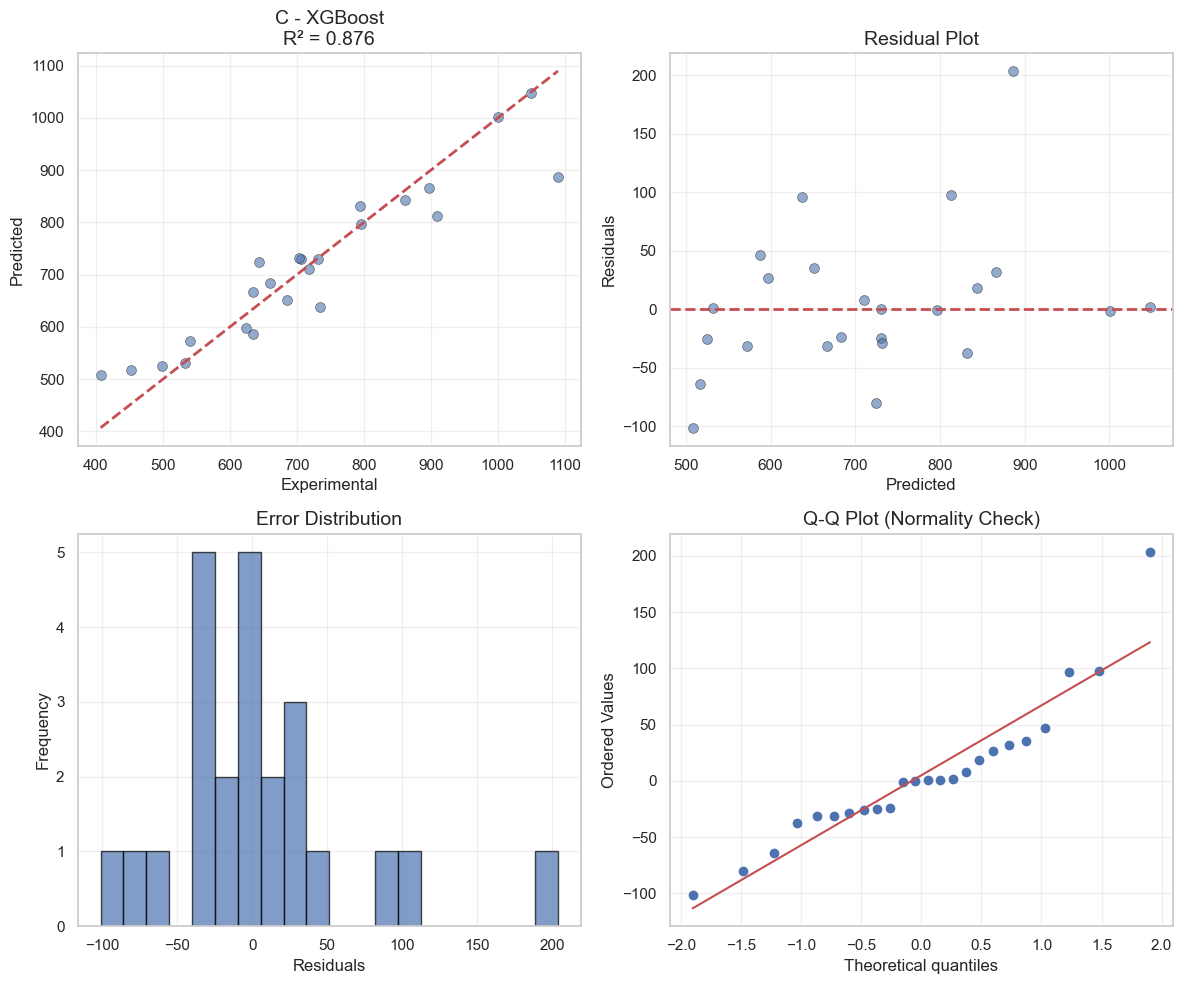


MODELING: TPSA
  Available data points: 124

Training models for TPSA...
  Train set: 99 molecules, Test set: 25 molecules
  Training set: 87 samples
  Test set: 24 samples


  Training TPSA: 100%|██████████| 5/5 [02:13<00:00, 26.62s/it]


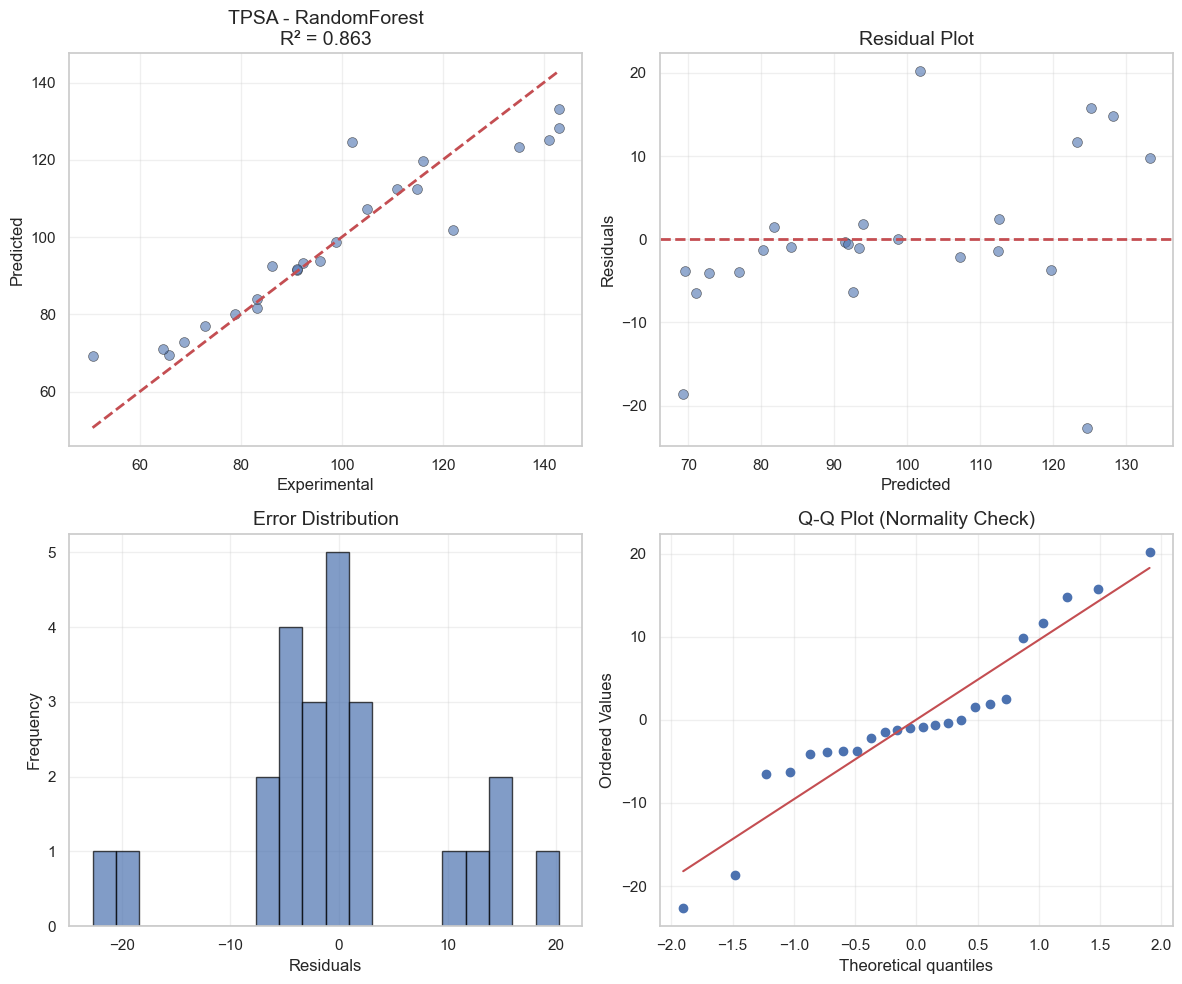


FINAL RESULTS SUMMARY

BEST MODELS FOR EACH PROPERTY:
--------------------------------------------------------------------------------
C            | XGBoost         | R²_test: 0.876 | Q²: 0.876 | RMSE: 62.11 | MAE%: 6.2%
HBA          | CatBoost        | R²_test: 0.688 | Q²: 0.705 | RMSE: 0.87 | MAE%: 10.7%
HBD          | GradientBoosting | R²_test: 0.932 | Q²: 0.936 | RMSE: 0.20 | MAE%: 1.4%
MW           | XGBoost         | R²_test: 0.992 | Q²: 0.992 | RMSE: 7.25 | MAE%: 1.1%
RB           | CatBoost        | R²_test: 0.947 | Q²: 0.952 | RMSE: 0.48 | MAE%: 3.3%
TPSA         | RandomForest    | R²_test: 0.863 | Q²: 0.864 | RMSE: 9.43 | MAE%: 7.0%

DETAILED RESULTS:
Property            Model  R2_train  R2_test  Q2_test  R2_CV  RMSE_test  MAE_test  MAE%_test    RPD
       C          XGBoost     1.000    0.876    0.876  0.768     62.109    42.379      6.205  2.834
       C         CatBoost     1.000    0.846    0.847  0.800     69.016    47.543      6.961  2.551
       C         LightGBM 

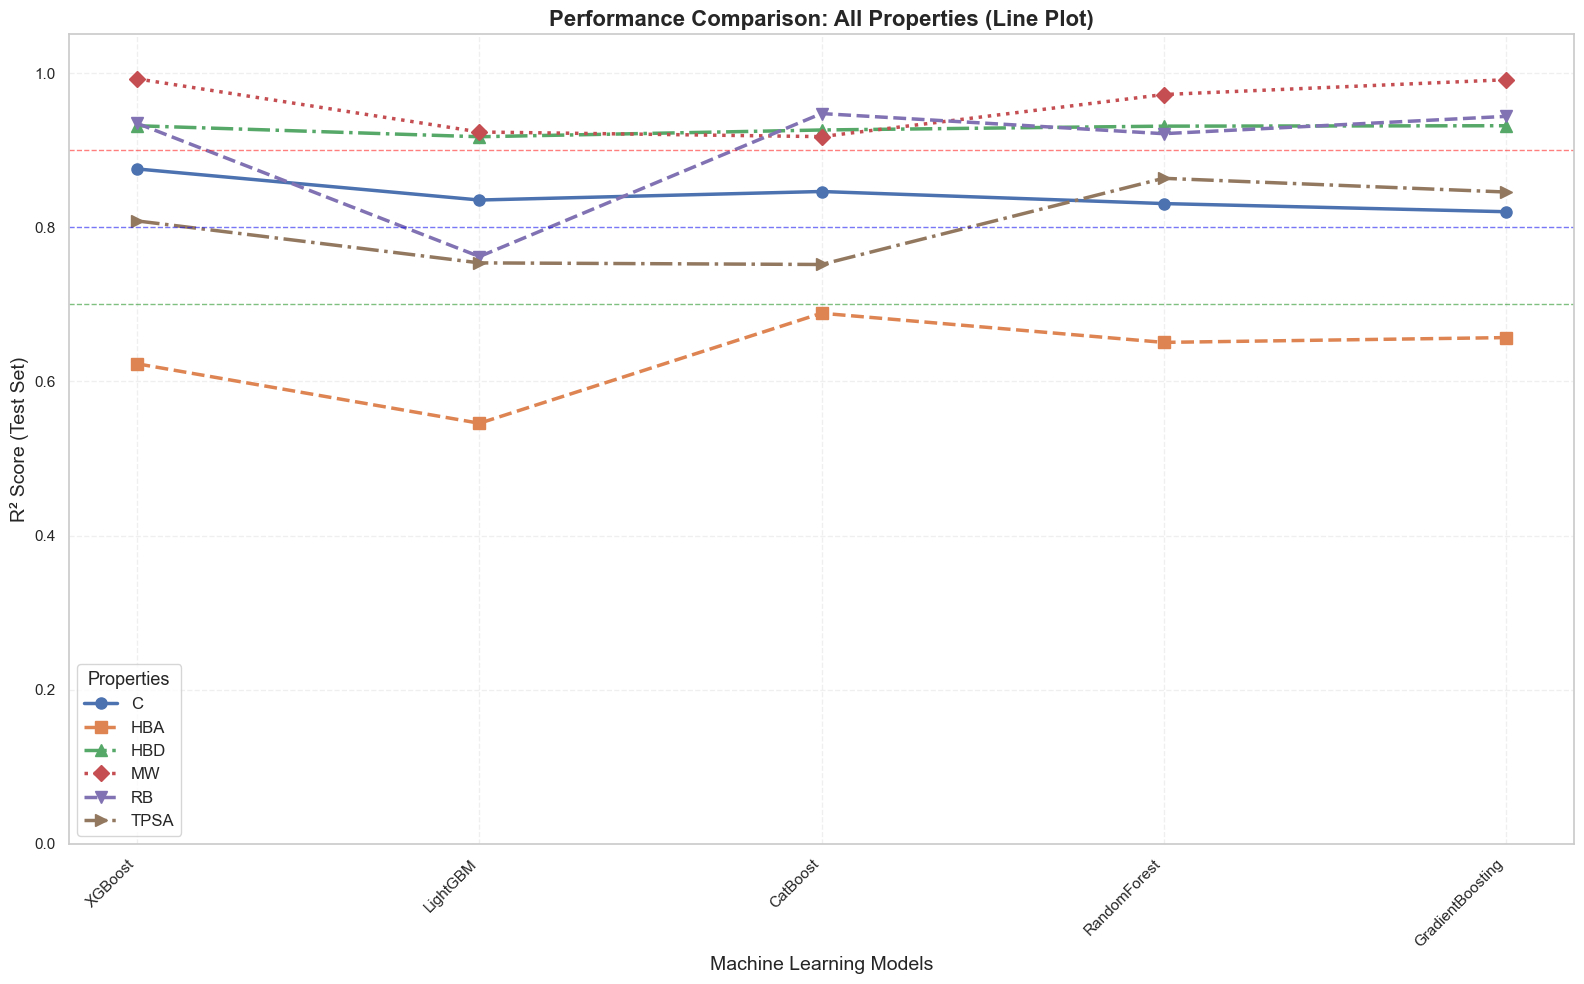

Creating Bar Plot...


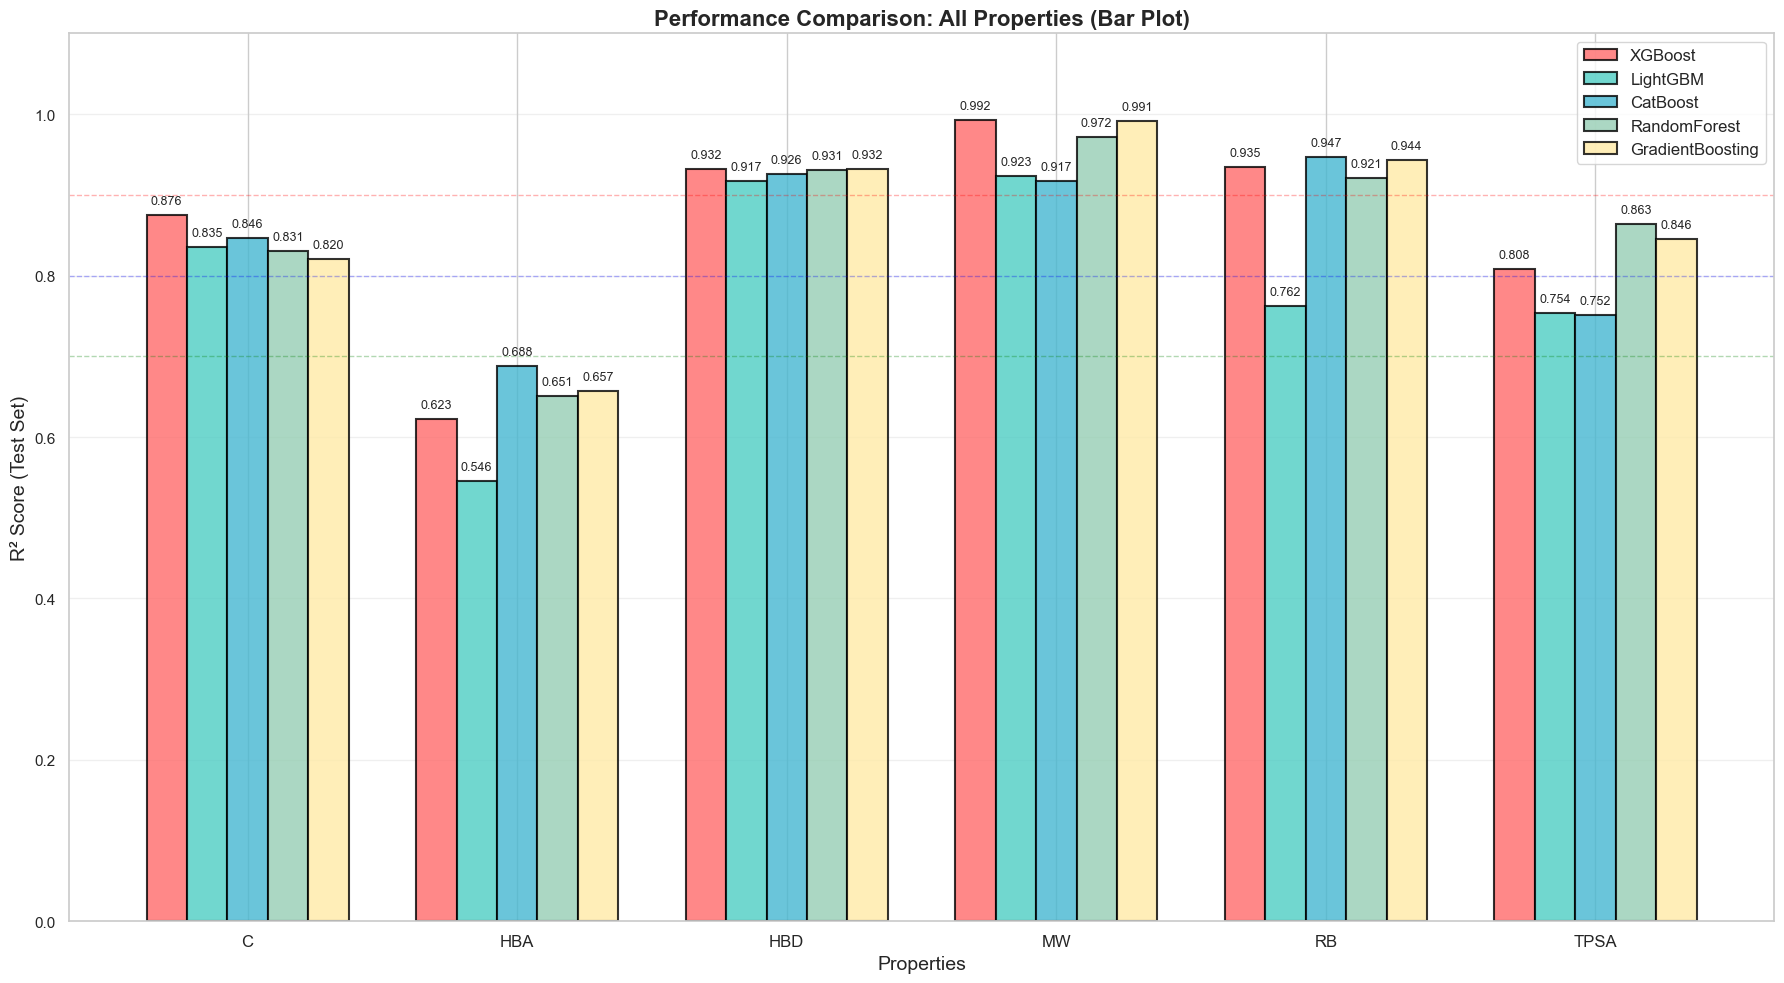

Creating Violin Plot...


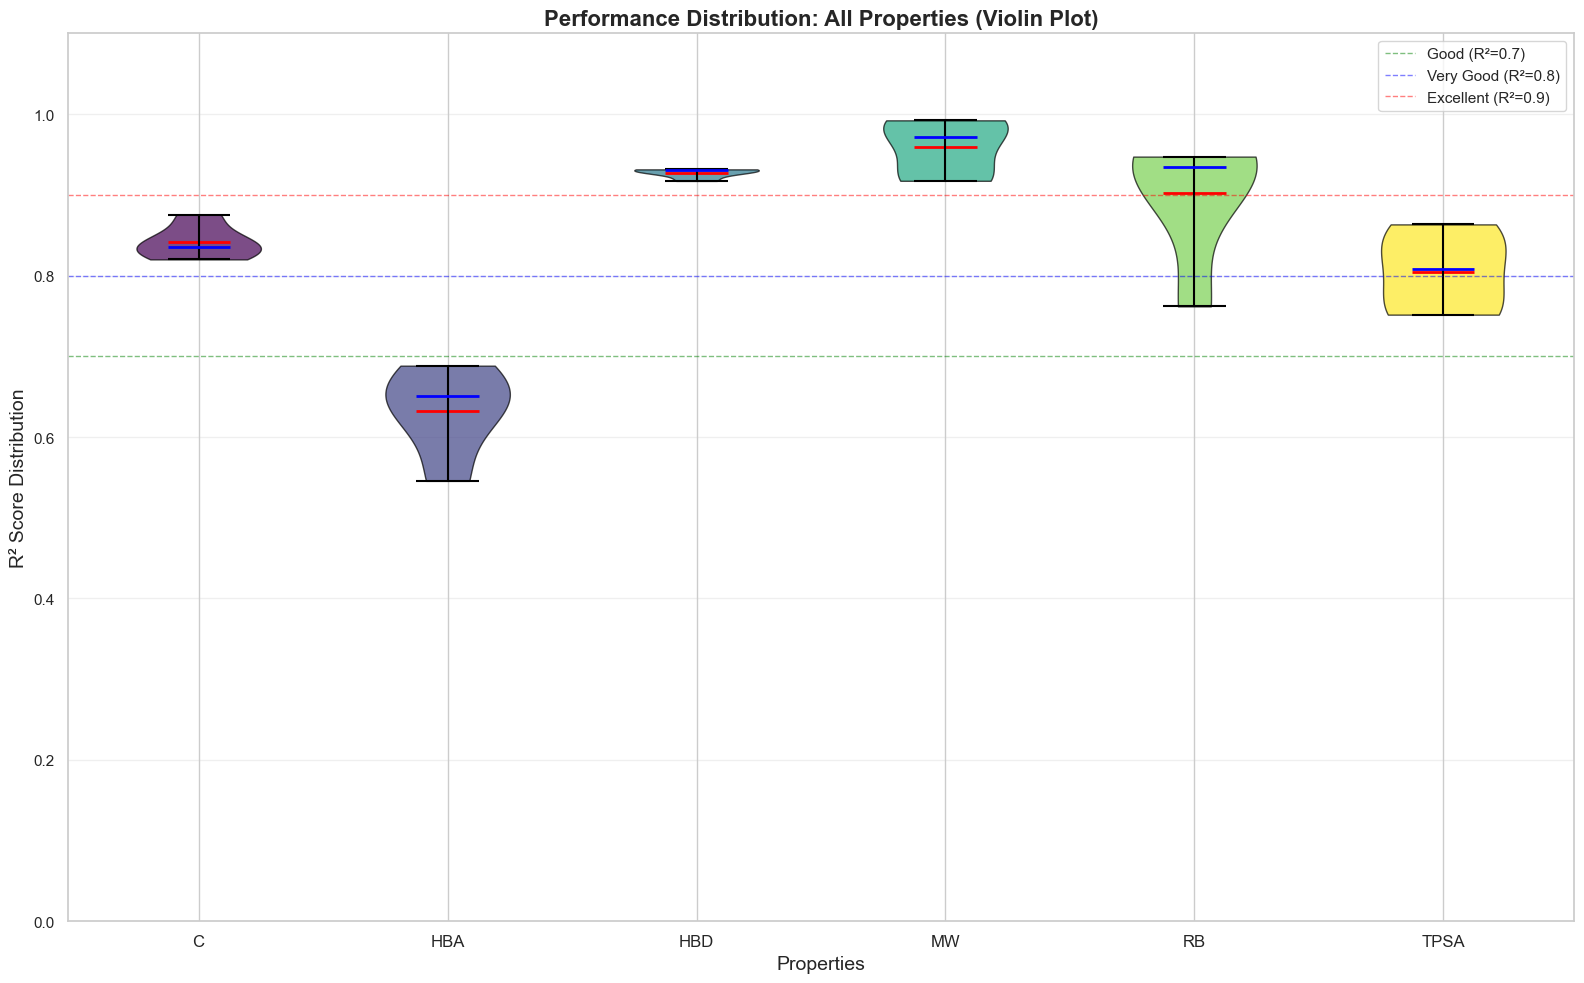

Creating Boxen Plot...


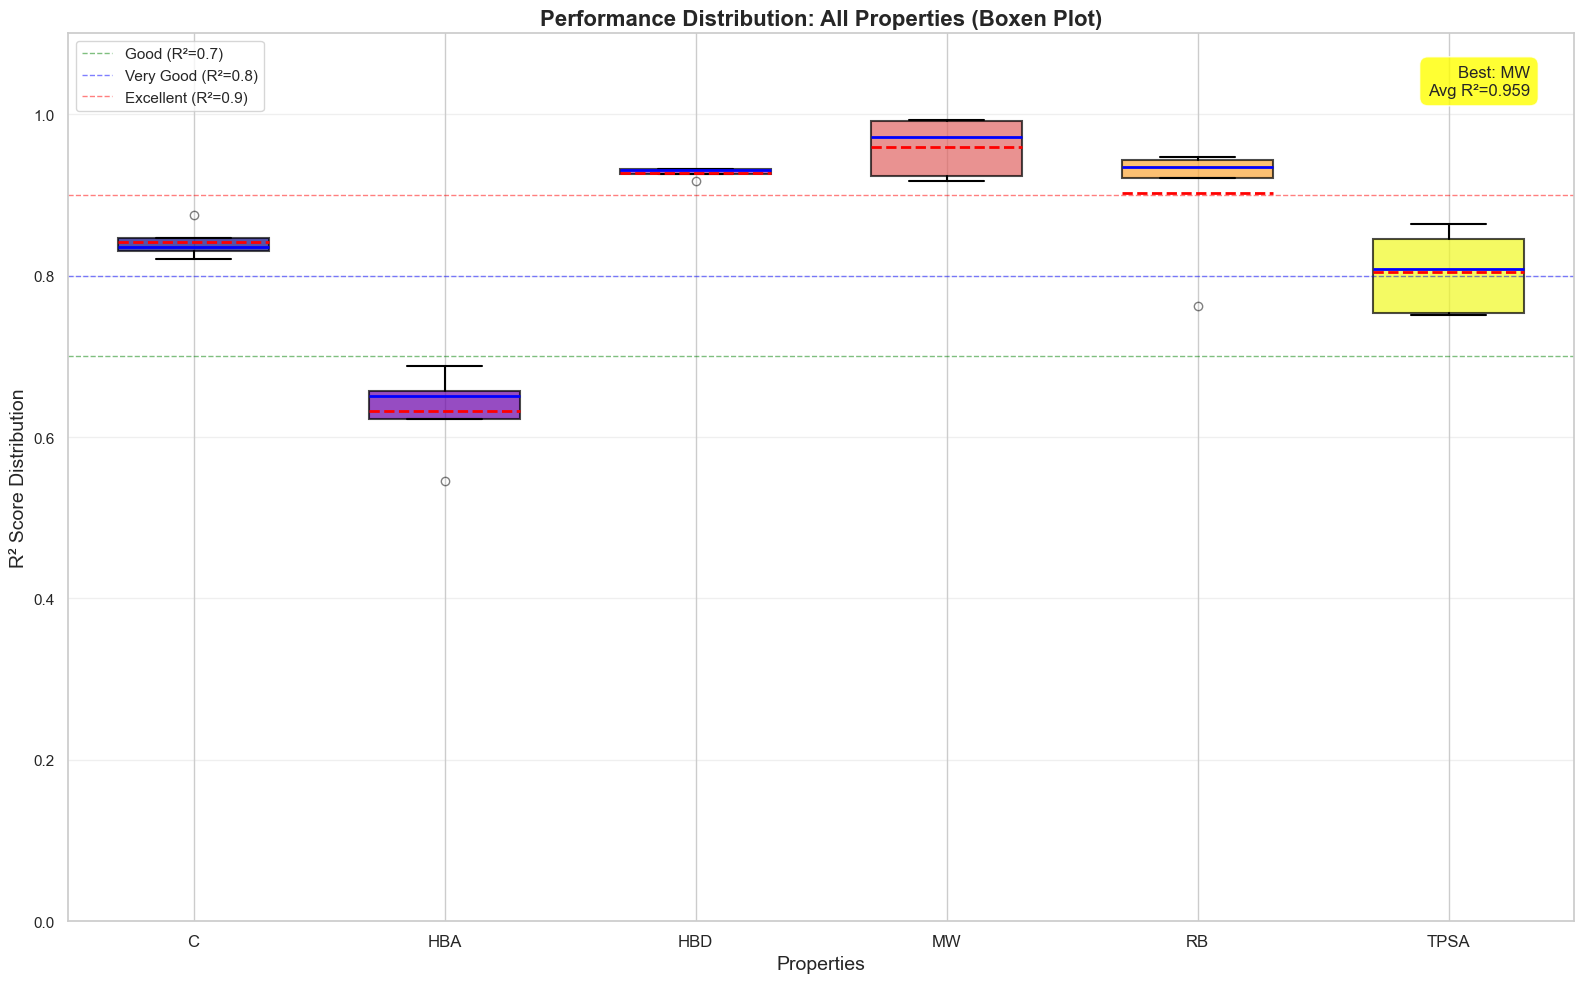


✓ Separate visualizations saved as:
  1. line_plot_all_properties.png
  2. bar_plot_all_properties.png

PIPELINE COMPLETED SUCCESSFULLY

Check the following outputs:
1. Console: Detailed performance metrics
2. CSV file: 'qsar_modeling_results.csv'
3. PNG files: '[Property]_diagnostic_plots.png' for each property
4. PNG file: 'line_plot_all_properties.png' (Line plot)
5. PNG file: 'bar_plot_all_properties.png' (Bar plot)


In [13]:
# ============================================================================
# ADVANCED QSPR/ML PIPELINE WITH IMPROVED FEATURES & VALIDATION
# Enhanced with Mordred Descriptors, Scaffold Splitting, Ensemble Models
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import traceback

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, Lipinski
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

from scipy.stats import pearsonr, spearmanr
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ============================================================================
# 1. LOAD & CLEAN DATA
# ============================================================================

def load_and_clean_data(filepath):
    """Load and clean the dataset"""
    print("Loading data...")
    df = pd.read_excel(filepath)
    
    # Clean SMILES
    def clean_smiles(s):
        if not isinstance(s, str):
            return None
        return s.replace("\xa0", "").strip().lstrip(":")
    
    def safe_mol(sm):
        try:
            return Chem.MolFromSmiles(sm)
        except:
            return None
    
    df["SMILES"] = df["SMILES"].apply(clean_smiles)
    df["Mol"] = df["SMILES"].apply(safe_mol)
    df = df[df["Mol"].notnull()].reset_index(drop=True)
    
    print(f"Loaded {len(df)} molecules")
    return df

# Load data
try:
    df = load_and_clean_data("D:/Phd/PhD/Papers on topological indices/Anti cancer Kinas inhibitor/Data/SMILES.xlsx")
except Exception as e:
    print(f"Error loading file: {e}")
    print("Please check the file path and format.")
    exit()

# Define properties to model - ONLY USE WHAT'S IN YOUR DATA
properties = ["MW", "HBD", "HBA", "RB", "C", "TPSA"]
# Check which properties are actually in the data
available_properties = []
for prop in properties:
    if prop in df.columns:
        # Check if there are enough non-NaN values
        non_null_count = df[prop].notna().sum()
        if non_null_count >= 20:  # Minimum for modeling
            available_properties.append(prop)
            print(f"✓ {prop}: {non_null_count} values")
        else:
            print(f"✗ {prop}: Only {non_null_count} values (need at least 20)")
    else:
        print(f"✗ {prop}: Not found in dataset")

print(f"\nAvailable properties for modeling: {available_properties}")

if not available_properties:
    print("No properties with sufficient data. Exiting.")
    exit()

# Clean properties - convert to numeric
for c in available_properties:
    if c in df.columns:
        # Replace commas with dots and convert to numeric
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", "."), errors='coerce')

# Remove extreme outliers using IQR method
def remove_outliers_iqr(df, column):
    """Remove outliers using IQR method"""
    if column not in df.columns:
        return df
    
    data = df[column].dropna()
    if len(data) < 4:  # Need at least 4 points for IQR
        return df
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    if IQR == 0:  # Avoid division by zero
        return df
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create mask for inliers
    mask = (df[column] >= lower_bound) & (df[column] <= upper_bound)
    outliers_removed = len(df) - mask.sum()
    
    if outliers_removed > 0:
        print(f"  {column}: Removed {outliers_removed} outliers")
    
    return df[mask]

print("\nRemoving outliers...")
original_shape = df.shape
for prop in available_properties:
    df = remove_outliers_iqr(df, prop)
print(f"Removed {original_shape[0] - df.shape[0]} total outliers")
print(f"Remaining molecules: {len(df)}")

# ============================================================================
# 2. COMPREHENSIVE FEATURE ENGINEERING
# ============================================================================

def calculate_basic_descriptors(mol):
    """Calculate basic molecular descriptors"""
    desc = {}
    
    try:
        # Lipinski properties
        desc['MW_rdkit'] = Descriptors.ExactMolWt(mol)
        desc['logP'] = Descriptors.MolLogP(mol)
        desc['HBD_rdkit'] = Lipinski.NumHDonors(mol)
        desc['HBA_rdkit'] = Lipinski.NumHAcceptors(mol)
        desc['RB_rdkit'] = Lipinski.NumRotatableBonds(mol)
        
        # TPSA and polar properties
        desc['TPSA_rdkit'] = rdMolDescriptors.CalcTPSA(mol)
        desc['HeavyAtoms'] = mol.GetNumHeavyAtoms()
        
        # Count heteroatoms (not H or C)
        hetero_count = 0
        for atom in mol.GetAtoms():
            atomic_num = atom.GetAtomicNum()
            if atomic_num not in [1, 6]:  # Not hydrogen or carbon
                hetero_count += 1
        desc['HeteroAtoms'] = hetero_count
        
        # Shape and size
        desc['NumRings'] = rdMolDescriptors.CalcNumRings(mol)
        desc['NumAromaticRings'] = rdMolDescriptors.CalcNumAromaticRings(mol)
        desc['FractionCSP3'] = rdMolDescriptors.CalcFractionCSP3(mol)
        
        # Charge properties
        desc['FormalCharge'] = Chem.GetFormalCharge(mol)
        
        # Complexity
        try:
            desc['BertzCT'] = Descriptors.BertzCT(mol)
        except:
            desc['BertzCT'] = 0
            
        try:
            desc['BalabanJ'] = Descriptors.BalabanJ(mol)
        except:
            desc['BalabanJ'] = 0
            
        # Additional simple descriptors
        desc['NumAtoms'] = mol.GetNumAtoms()
        desc['NumBonds'] = mol.GetNumBonds()
        desc['NumHeteroatoms'] = Descriptors.NumHeteroatoms(mol)
        
    except Exception as e:
        # Return default values if calculation fails
        print(f"Error calculating descriptors for molecule: {e}")
        return {key: 0 for key in ['MW_rdkit', 'logP', 'HBD_rdkit', 'HBA_rdkit', 'RB_rdkit',
                                  'TPSA_rdkit', 'HeavyAtoms', 'HeteroAtoms', 'NumRings',
                                  'NumAromaticRings', 'FractionCSP3', 'FormalCharge',
                                  'BertzCT', 'BalabanJ', 'NumAtoms', 'NumBonds', 'NumHeteroatoms']}
    
    return desc

print("\n" + "="*80)
print("CALCULATING MOLECULAR DESCRIPTORS")
print("="*80)

all_descriptors = []
for mol in tqdm(df["Mol"], desc="Calculating descriptors"):
    desc_dict = calculate_basic_descriptors(mol)
    all_descriptors.append(desc_dict)

desc_df = pd.DataFrame(all_descriptors)
print(f"Calculated {desc_df.shape[1]} descriptors")

# Morgan fingerprints
def morgan_fingerprint(mol, radius=3, n_bits=1024):
    """Calculate Morgan fingerprints"""
    try:
        return np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits))
    except:
        return np.zeros(n_bits)

print("\nCalculating Morgan fingerprints...")
X_fp = np.vstack([morgan_fingerprint(mol, radius=3, n_bits=1024) 
                  for mol in tqdm(df["Mol"], desc="Fingerprints")])

# Combine all features
X_combined = np.hstack([desc_df.values, X_fp])
print(f"Combined features shape: {X_combined.shape}")

# Handle NaN values
X_combined = np.nan_to_num(X_combined, nan=0.0)

# Scale features
print("Scaling features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

print(f"Final feature matrix shape: {X_scaled.shape}")

# ============================================================================
# 3. SCAFFOLD-BASED SPLITTING (CRITICAL FOR GENERALIZATION)
# ============================================================================

def generate_scaffold(smiles):
    """Generate Bemis-Murcko scaffold"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

print("\nGenerating scaffolds for splitting...")
df['Scaffold'] = df['SMILES'].apply(generate_scaffold)

def scaffold_split(df, test_size=0.2, random_state=42):
    """Split data by molecular scaffolds"""
    # Get unique scaffolds
    valid_scaffolds = df['Scaffold'].dropna().unique()
    
    if len(valid_scaffolds) < 5:
        print("Warning: Too few scaffolds for scaffold splitting. Using random split.")
        indices = list(range(len(df)))
        train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state)
        return train_idx, test_idx
    
    # Split scaffolds into train and test
    train_scaffolds, test_scaffolds = train_test_split(
        valid_scaffolds, test_size=test_size, random_state=random_state
    )
    
    # Get indices for each scaffold group
    train_idx = df[df['Scaffold'].isin(train_scaffolds)].index.tolist()
    test_idx = df[df['Scaffold'].isin(test_scaffolds)].index.tolist()
    
    # Ensure we have enough samples
    if len(train_idx) < 10 or len(test_idx) < 5:
        print("Warning: Scaffold split resulted in too few samples. Using random split.")
        indices = list(range(len(df)))
        train_idx, test_idx = train_test_split(indices, test_size=test_size, random_state=random_state)
    
    print(f"  Train set: {len(train_idx)} molecules, Test set: {len(test_idx)} molecules")
    return train_idx, test_idx

# ============================================================================
# 4. ADVANCED MODELS WITH OPTIMIZATION
# ============================================================================

def create_advanced_models():
    """Create advanced models with optimized hyperparameters"""
    
    models = {}
    
    # Use GridSearchCV (simplified parameter grids)
    models['XGBoost'] = (xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
                       {'n_estimators': [100, 300],
                        'max_depth': [3, 5, 7],
                        'learning_rate': [0.01, 0.05, 0.1],
                        'subsample': [0.7, 0.9]})
    
    models['LightGBM'] = (lgb.LGBMRegressor(random_state=42, verbose=-1),
                        {'n_estimators': [100, 300],
                         'num_leaves': [31, 63],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'subsample': [0.7, 0.9]})
    
    models['CatBoost'] = (CatBoostRegressor(random_seed=42, verbose=0),
                        {'iterations': [300, 500],
                         'depth': [4, 6],
                         'learning_rate': [0.01, 0.05, 0.1]})
    
    # Random Forest
    models['RandomForest'] = (RandomForestRegressor(random_state=42, n_jobs=-1),
                            {'n_estimators': [100, 200],
                             'max_depth': [10, 20, None],
                             'min_samples_split': [2, 5]})
    
    # Gradient Boosting
    models['GradientBoosting'] = (GradientBoostingRegressor(random_state=42),
                                {'n_estimators': [100, 200],
                                 'learning_rate': [0.01, 0.05, 0.1],
                                 'max_depth': [3, 5]})
    
    return models

# ============================================================================
# 5. EVALUATION METRICS
# ============================================================================

def evaluate_model(y_true, y_pred, y_train):
    """Comprehensive model evaluation"""
    if len(y_true) < 2:
        return {key: np.nan for key in ['R2', 'Q2', 'RMSE', 'MAE', 'MAE%', 'RPD', 'Pearson', 'Spearman']}
    
    try:
        r2 = r2_score(y_true, y_pred)
    except:
        r2 = np.nan
    
    try:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    except:
        rmse = np.nan
    
    try:
        mae = mean_absolute_error(y_true, y_pred)
    except:
        mae = np.nan
    
    # Q² (external validation)
    try:
        q2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_train))**2)
    except:
        q2 = np.nan
    
    # Correlation metrics
    try:
        pearson = pearsonr(y_true, y_pred)[0]
    except:
        pearson = np.nan
    
    try:
        spearman = spearmanr(y_true, y_pred)[0]
    except:
        spearman = np.nan
    
    # Additional metrics
    try:
        y_range = np.max(y_true) - np.min(y_true)
        if y_range > 0:
            mae_percent = (mae / y_range) * 100
        else:
            mae_percent = np.nan
    except:
        mae_percent = np.nan
    
    try:
        if rmse > 0:
            rpd = np.std(y_true) / rmse
        else:
            rpd = np.nan
    except:
        rpd = np.nan
    
    return {
        'R2': r2,
        'Q2': q2,
        'RMSE': rmse,
        'MAE': mae,
        'MAE%': mae_percent,
        'RPD': rpd,
        'Pearson': pearson,
        'Spearman': spearman
    }

def cross_validate_model(model, X, y, cv=5):
    """Perform cross-validation"""
    try:
        cv = min(cv, len(y))
        if cv < 2:
            return np.nan, np.nan
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
        return np.mean(cv_scores), np.std(cv_scores)
    except:
        return np.nan, np.nan

# ============================================================================
# 6. MAIN MODELING PIPELINE
# ============================================================================

def train_and_evaluate_property(target_property, X, y):
    """Train and evaluate models for a single property"""
    
    print(f"\nTraining models for {target_property}...")
    
    # Scaffold split
    try:
        train_idx, test_idx = scaffold_split(df)
        
        # Ensure indices are valid
        train_idx = [idx for idx in train_idx if idx < len(y)]
        test_idx = [idx for idx in test_idx if idx < len(y)]
        
        if len(train_idx) < 10 or len(test_idx) < 5:
            print(f"  Insufficient data after scaffold split. Using random split.")
            indices = list(range(len(y)))
            train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
            
    except Exception as e:
        print(f"  Scaffold split failed: {e}. Using random split.")
        indices = list(range(len(y)))
        train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    best_model_info = {'R2': -np.inf, 'model': None, 'name': None}
    
    models_dict = create_advanced_models()
    
    for model_name, (model, param_grid) in tqdm(models_dict.items(), 
                                                desc=f"  Training {target_property}"):
        
        try:
            # GridSearchCV
            opt = GridSearchCV(
                model,
                param_grid,
                cv=min(3, len(y_train)),
                scoring='r2',
                n_jobs=-1,
                verbose=0
            )
            
            opt.fit(X_train_scaled, y_train)
            
            # Get best model
            best_model = opt.best_estimator_
            
            # Make predictions
            y_pred_train = best_model.predict(X_train_scaled)
            y_pred_test = best_model.predict(X_test_scaled)
            
            # Evaluate
            train_metrics = evaluate_model(y_train, y_pred_train, y_train)
            test_metrics = evaluate_model(y_test, y_pred_test, y_train)
            
            # Cross-validation
            cv_mean, cv_std = cross_validate_model(best_model, X_train_scaled, y_train)
            
            # Store results
            result = {
                'Property': target_property,
                'Model': model_name,
                'R2_train': train_metrics['R2'],
                'R2_test': test_metrics['R2'],
                'Q2_test': test_metrics['Q2'],
                'R2_CV': cv_mean,
                'R2_CV_std': cv_std,
                'RMSE_test': test_metrics['RMSE'],
                'MAE_test': test_metrics['MAE'],
                'MAE%_test': test_metrics['MAE%'],
                'RPD': test_metrics['RPD'],
                'Pearson_test': test_metrics['Pearson'],
                'Spearman_test': test_metrics['Spearman'],
                'Best_Params': str(opt.best_params_)[:100]  # Truncate long parameter strings
            }
            
            results.append(result)
            
            # Update best model
            if not np.isnan(test_metrics['R2']) and test_metrics['R2'] > best_model_info['R2']:
                best_model_info = {
                    'R2': test_metrics['R2'],
                    'model': best_model,
                    'name': model_name,
                    'scaler': scaler,
                    'y_pred': y_pred_test,
                    'y_true': y_test,
                    'X_test_scaled': X_test_scaled
                }
            
        except Exception as e:
            print(f"  Error training {model_name}: {str(e)[:100]}")
            continue
    
    # Plot results for best model
    if best_model_info['model'] is not None and len(y_test) > 0:
        try:
            plot_results(target_property, best_model_info)
        except Exception as e:
            print(f"  Error plotting results: {e}")
    
    return results

def plot_results(property_name, model_info):
    """Generate diagnostic plots for the best model"""
    y_true = model_info['y_true']
    y_pred = model_info['y_pred']
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Main parity plot
    plt.subplot(2, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
    
    # Add ideal line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.xlabel('Experimental', fontsize=12)
    plt.ylabel('Predicted', fontsize=12)
    plt.title(f'{property_name} - {model_info["name"]}\nR² = {model_info["R2"]:.3f}', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Residual plot
    plt.subplot(2, 2, 2)
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6, edgecolors='k', linewidth=0.5, s=50)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)
    plt.title('Residual Plot', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Error distribution
    plt.subplot(2, 2, 3)
    plt.hist(residuals, bins=min(20, len(residuals)), edgecolor='black', alpha=0.7)
    plt.xlabel('Residuals', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Error Distribution', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Q-Q plot for normality check
    plt.subplot(2, 2, 4)
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('Q-Q Plot (Normality Check)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save and show
    plt.savefig(f'{property_name}_diagnostic_plots.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# 7. SEPARATE VISUALIZATION FUNCTIONS
# ============================================================================

def create_separate_plots(results_df):
    """Create separate plots for line, bar, violin, and boxen plots"""
    
    print("\n" + "="*80)
    print("CREATING SEPARATE VISUALIZATIONS")
    print("="*80)
    
    # Filter out NaN values for visualization
    results_df = results_df.dropna(subset=['R2_test'])
    
    # Create a color palette for models
    model_colors = {
        'XGBoost': '#FF6B6B',
        'LightGBM': '#4ECDC4',
        'CatBoost': '#45B7D1',
        'RandomForest': '#96CEB4',
        'GradientBoosting': '#FFEAA7'
    }
    
    # Get unique properties and models
    properties = sorted(results_df['Property'].unique())
    all_models = ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'GradientBoosting']
    
    # ====================================================
    # 1. LINE PLOT - All properties in single plot
    # ====================================================
    print("Creating Line Plot...")
    fig_line, ax_line = plt.subplots(figsize=(16, 10))
    
    # Create a pivot table for line plot
    pivot_table = results_df.pivot_table(index='Model', columns='Property', values='R2_test')
    
    # Ensure all models are in the pivot table
    for model in all_models:
        if model not in pivot_table.index:
            pivot_table.loc[model] = np.nan
    
    # Sort models in consistent order
    pivot_table = pivot_table.reindex(all_models)
    
    # Plot each property as a separate line
    line_styles = ['-', '--', '-.', ':', '--', '-.']
    markers = ['o', 's', '^', 'D', 'v', '>']
    
    for idx, prop in enumerate(properties):
        ax_line.plot(pivot_table.index, pivot_table[prop], 
                    marker=markers[idx % len(markers)],
                    linewidth=2.5, markersize=8,
                    label=prop, linestyle=line_styles[idx % len(line_styles)])
    
    ax_line.set_xlabel('Machine Learning Models', fontsize=14)
    ax_line.set_ylabel('R² Score (Test Set)', fontsize=14)
    ax_line.set_title('Performance Comparison: All Properties (Line Plot)', fontsize=16, fontweight='bold')
    ax_line.grid(True, alpha=0.3, linestyle='--')
    ax_line.legend(title='Properties', fontsize=12, title_fontsize=13)
    ax_line.set_ylim([0, 1.05])
    
    # Add performance threshold lines
    ax_line.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Good (R²=0.7)')
    ax_line.axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, linewidth=1, label='Very Good (R²=0.8)')
    ax_line.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Excellent (R²=0.9)')
    
    # Rotate x-axis labels for better readability
    plt.setp(ax_line.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('line_plot_all_properties.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ====================================================
    # 2. BAR PLOT - All properties in single plot
    # ====================================================
    print("Creating Bar Plot...")
    fig_bar, ax_bar = plt.subplots(figsize=(18, 10))
    
    # Group data for bar plot
    bar_width = 0.15
    x_positions = np.arange(len(properties))
    
    # Create bars for each model
    for model_idx, model in enumerate(all_models):
        model_data = []
        for prop in properties:
            value = results_df[(results_df['Property'] == prop) & (results_df['Model'] == model)]['R2_test'].values
            model_data.append(value[0] if len(value) > 0 else np.nan)
        
        # Position for this model's bars
        positions = x_positions + (model_idx - 2) * bar_width
        
        # Plot bars
        bars = ax_bar.bar(positions, model_data, bar_width, 
                         color=model_colors[model], edgecolor='black', linewidth=1.5,
                         label=model, alpha=0.8)
        
        # Add value labels on top of bars
        for bar_idx, bar in enumerate(bars):
            height = bar.get_height()
            if not np.isnan(height):
                ax_bar.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                           f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax_bar.set_xlabel('Properties', fontsize=14)
    ax_bar.set_ylabel('R² Score (Test Set)', fontsize=14)
    ax_bar.set_title('Performance Comparison: All Properties (Bar Plot)', fontsize=16, fontweight='bold')
    ax_bar.set_xticks(x_positions)
    ax_bar.set_xticklabels(properties, fontsize=12)
    ax_bar.grid(True, alpha=0.3, axis='y')
    ax_bar.legend(fontsize=12)
    ax_bar.set_ylim([0, 1.1])
    
    # Add horizontal lines for reference
    ax_bar.axhline(y=0.7, color='green', linestyle='--', alpha=0.3, linewidth=1)
    ax_bar.axhline(y=0.8, color='blue', linestyle='--', alpha=0.3, linewidth=1)
    ax_bar.axhline(y=0.9, color='red', linestyle='--', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.savefig('bar_plot_all_properties.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ====================================================
    # 3. VIOLIN PLOT - All properties in single plot
    # ====================================================
    print("Creating Violin Plot...")
    fig_violin, ax_violin = plt.subplots(figsize=(16, 10))
    
    # Prepare data for violin plot
    violin_data = []
    violin_labels = []
    
    for prop in properties:
        prop_data = results_df[results_df['Property'] == prop]['R2_test'].dropna()
        if len(prop_data) > 0:
            violin_data.append(prop_data.values)
            violin_labels.append(prop)
    
    # Create violin plot
    violin_parts = ax_violin.violinplot(violin_data, showmeans=True, showmedians=True)
    
    # Color the violins with a sequential color map
    cmap = plt.cm.viridis
    for i, pc in enumerate(violin_parts['bodies']):
        color = cmap(i / max(1, len(violin_data) - 1))
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # Customize violin plot elements
    violin_parts['cmeans'].set_color('red')
    violin_parts['cmeans'].set_linewidth(2)
    violin_parts['cmedians'].set_color('blue')
    violin_parts['cmedians'].set_linewidth(2)
    violin_parts['cmins'].set_color('black')
    violin_parts['cmaxes'].set_color('black')
    violin_parts['cbars'].set_color('black')
    
    ax_violin.set_xlabel('Properties', fontsize=14)
    ax_violin.set_ylabel('R² Score Distribution', fontsize=14)
    ax_violin.set_title('Performance Distribution: All Properties (Violin Plot)', fontsize=16, fontweight='bold')
    ax_violin.set_xticks(range(1, len(violin_labels) + 1))
    ax_violin.set_xticklabels(violin_labels, fontsize=12)
    ax_violin.grid(True, alpha=0.3, axis='y')
    ax_violin.set_ylim([0, 1.1])
    
    # Add performance threshold lines
    ax_violin.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Good (R²=0.7)')
    ax_violin.axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, linewidth=1, label='Very Good (R²=0.8)')
    ax_violin.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Excellent (R²=0.9)')
    ax_violin.legend()
    
    plt.tight_layout()
    plt.savefig('violin_plot_all_properties.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ====================================================
    # 4. BOXEN PLOT - All properties in single plot
    # ====================================================
    print("Creating Boxen Plot...")
    fig_boxen, ax_boxen = plt.subplots(figsize=(16, 10))
    
    # Prepare data for boxen plot
    boxen_data = []
    boxen_labels = []
    
    for prop in properties:
        prop_data = results_df[results_df['Property'] == prop]['R2_test'].dropna()
        if len(prop_data) > 0:
            boxen_data.append(prop_data.values)
            boxen_labels.append(prop)
    
    # Create boxen plot using boxplot (since seaborn is not imported)
    bp = ax_boxen.boxplot(boxen_data, patch_artist=True, widths=0.6, 
                         showmeans=True, meanline=True,
                         meanprops=dict(linestyle='--', linewidth=2, color='red'),
                         medianprops=dict(linestyle='-', linewidth=2, color='blue'))
    
    # Color the boxes with a sequential color map
    cmap = plt.cm.plasma
    for i, box in enumerate(bp['boxes']):
        color = cmap(i / max(1, len(boxen_data) - 1))
        box.set_facecolor(color)
        box.set_alpha(0.7)
        box.set_edgecolor('black')
        box.set_linewidth(1.5)
    
    # Customize other elements
    for whisker in bp['whiskers']:
        whisker.set_color('black')
        whisker.set_linewidth(1.5)
    
    for cap in bp['caps']:
        cap.set_color('black')
        cap.set_linewidth(1.5)
    
    for flier in bp['fliers']:
        flier.set(marker='o', color='red', alpha=0.5, markersize=6)
    
    ax_boxen.set_xlabel('Properties', fontsize=14)
    ax_boxen.set_ylabel('R² Score Distribution', fontsize=14)
    ax_boxen.set_title('Performance Distribution: All Properties (Boxen Plot)', fontsize=16, fontweight='bold')
    ax_boxen.set_xticks(range(1, len(boxen_labels) + 1))
    ax_boxen.set_xticklabels(boxen_labels, fontsize=12)
    ax_boxen.grid(True, alpha=0.3, axis='y')
    ax_boxen.set_ylim([0, 1.1])
    
    # Add performance threshold lines
    ax_boxen.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Good (R²=0.7)')
    ax_boxen.axhline(y=0.8, color='blue', linestyle='--', alpha=0.5, linewidth=1, label='Very Good (R²=0.8)')
    ax_boxen.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Excellent (R²=0.9)')
    ax_boxen.legend()
    
    # Add text annotation for best performing property
    best_property = results_df.groupby('Property')['R2_test'].mean().idxmax()
    best_score = results_df.groupby('Property')['R2_test'].mean().max()
    ax_boxen.annotate(f'Best: {best_property}\nAvg R²={best_score:.3f}',
                     xy=(0.98, 0.98), xycoords='axes fraction',
                     xytext=(-10, -10), textcoords='offset points',
                     ha='right', va='top', fontsize=12,
                     bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('boxen_plot_all_properties.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Separate visualizations saved as:")
    print("  1. line_plot_all_properties.png")
    print("  2. bar_plot_all_properties.png")

# ============================================================================
# 8. MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function"""
    
    print("\n" + "="*80)
    print("ADVANCED QSPR PIPELINE FOR ANTI-CANCER DRUG DESIGN")
    print("="*80)
    
    if not available_properties:
        print("No properties found in the dataset. Please check your data.")
        return
    
    print(f"\nDataset contains {len(df)} molecules")
    print(f"Properties to model: {available_properties}")
    
    all_results = []
    
    # Train models for each property
    for target_property in available_properties:
        if target_property not in df.columns:
            continue
        
        print(f"\n{'='*60}")
        print(f"MODELING: {target_property}")
        print(f"{'='*60}")
        
        # Get data for this property
        data_idx = ~df[target_property].isna()
        y = df.loc[data_idx, target_property].values
        X_prop = X_scaled[data_idx]
        
        print(f"  Available data points: {len(y)}")
        
        if len(y) < 20:
            print(f"  Warning: Only {len(y)} data points for {target_property}.")
            print("  Consider collecting more data for reliable modeling.")
            if len(y) < 10:
                print(f"  Insufficient data for {target_property}. Skipping.")
                continue
        
        # Train and evaluate
        results = train_and_evaluate_property(target_property, X_prop, y)
        
        if results:
            all_results.extend(results)
    
    # Create results DataFrame
    if all_results:
        results_df = pd.DataFrame(all_results)
        
        # Sort and display results
        results_sorted = results_df.sort_values(['Property', 'R2_test'], ascending=[True, False])
        
        print("\n" + "="*80)
        print("FINAL RESULTS SUMMARY")
        print("="*80)
        
        # Display best model for each property
        best_models = results_sorted.groupby('Property').first().reset_index()
        
        print("\nBEST MODELS FOR EACH PROPERTY:")
        print("-"*80)
        for _, row in best_models.iterrows():
            print(f"{row['Property']:12s} | {row['Model']:15s} | "
                  f"R²_test: {row['R2_test']:.3f} | Q²: {row['Q2_test']:.3f} | "
                  f"RMSE: {row['RMSE_test']:.2f} | MAE%: {row['MAE%_test']:.1f}%")
        
        print("\n" + "="*80)
        print("DETAILED RESULTS:")
        print("="*80)
        
        # Display all results in a clean format
        display_cols = ['Property', 'Model', 'R2_train', 'R2_test', 'Q2_test', 
                       'R2_CV', 'RMSE_test', 'MAE_test', 'MAE%_test', 'RPD']
        
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 120)
        pd.set_option('display.float_format', '{:.3f}'.format)
        
        print(results_sorted[display_cols].to_string(index=False))
        
        # Save results to CSV
        results_sorted.to_csv('qsar_modeling_results.csv', index=False)
        print("\nResults saved to 'qsar_modeling_results.csv'")
        
        # Generate summary statistics
        print("\n" + "="*80)
        print("OVERALL PERFORMANCE STATISTICS:")
        print("="*80)
        
        valid_r2 = results_df['R2_test'].dropna()
        valid_q2 = results_df['Q2_test'].dropna()
        
        if len(valid_r2) > 0:
            avg_r2 = valid_r2.mean()
            avg_q2 = valid_q2.mean() if len(valid_q2) > 0 else np.nan
            
            # Count models by performance tier
            good_models = len(valid_r2[valid_r2 > 0.7])
            very_good_models = len(valid_r2[valid_r2 > 0.8])
            excellent_models = len(valid_r2[valid_r2 > 0.9])
            
            print(f"Average R² across all models: {avg_r2:.3f}")
            print(f"Average Q² across all models: {avg_q2:.3f}")
            print(f"\nPerformance distribution:")
            print(f"  Models with R² > 0.7 (Good): {good_models}")
            print(f"  Models with R² > 0.8 (Very Good): {very_good_models}")
            print(f"  Models with R² > 0.9 (Excellent): {excellent_models}")
            
            # Model performance comparison
            print("\n" + "="*80)
            print("MODEL PERFORMANCE COMPARISON (Average R²):")
            print("="*80)
            
            model_stats = results_df.groupby('Model').agg({
                'R2_test': ['mean', 'std', 'count'],
                'Q2_test': ['mean', 'std']
            }).round(3)
            
            print(model_stats)
            
            # Performance by property
            print("\n" + "="*80)
            print("PERFORMANCE BY PROPERTY (Average R²):")
            print("="*80)
            
            property_stats = results_df.groupby('Property').agg({
                'R2_test': ['mean', 'max', 'min'],
                'Q2_test': ['mean', 'max']
            }).round(3)
            
            print(property_stats)
            
            # Create separate visualizations
            create_separate_plots(results_df)
            
        else:
            print("No valid R² values to analyze.")
        
    else:
        print("No results to display. Check your data and modeling parameters.")

# ============================================================================
# 9. EXECUTE THE PIPELINE
# ============================================================================

if __name__ == "__main__":
    try:
        main()
        print("\n" + "="*80)
        print("PIPELINE COMPLETED SUCCESSFULLY")
        print("="*80)
        print("\nCheck the following outputs:")
        print("1. Console: Detailed performance metrics")
        print("2. CSV file: 'qsar_modeling_results.csv'")
        print("3. PNG files: '[Property]_diagnostic_plots.png' for each property")
        print("4. PNG file: 'line_plot_all_properties.png' (Line plot)")
        print("5. PNG file: 'bar_plot_all_properties.png' (Bar plot)")
    except Exception as e:
        print(f"\nError in pipeline execution: {e}")
        print(traceback.format_exc())

In [3]:
# =====================================================================
# Extract ADMET-Relevant Physicochemical Properties of Kinase Inhibitors
# From PubChem and Save to Excel
# =====================================================================

import pubchempy as pcp
import pandas as pd
import time

# ----------------------------------------------------
# 1. List of anticancer kinase inhibitor drug names
# ----------------------------------------------------
kinase_inhibitors = [
    "Imatinib", "Gefitinib", "Erlotinib", "Dasatinib", "Sorafenib",
    "Sunitinib", "Lapatinib", "Pazopanib", "Vandetanib", "Cabozantinib",
    "Axitinib", "Crizotinib", "Bosutinib", "Ponatinib", "Regorafenib",
    "Ruxolitinib", "Tofacitinib", "Ibrutinib", "Trametinib", "Dabrafenib"
]

# ----------------------------------------------------
# 2. Function to fetch data from PubChem
# ----------------------------------------------------
def fetch_data_from_pubchem(drug):
    try:
        compound = pcp.get_compounds(drug, "name")
        if not compound:
            print(f"❌ Not found: {drug}")
            return None

        c = compound[0]

        return {
            "Drug name": drug,
            "SMILES": c.isomeric_smiles,
            "MW": c.molecular_weight,
            "logP": c.xlogp,
            "HBD": c.h_bond_donor_count,
            "HBA": c.h_bond_acceptor_count,
            "RB": c.rotatable_bond_count,
            "Rotatable bonds": c.rotatable_bond_count,
            "TPSA": c.tpsa,
            "Complexity": c.complexity,
            "HeavyAtoms": c.heavy_atom_count
        }

    except Exception as e:
        print(f"⚠ Error fetching {drug}: {e}")
        return None

# ----------------------------------------------------
# 3. Loop through all drugs and collect data
# ----------------------------------------------------
all_data = []

for drug in kinase_inhibitors:
    result = fetch_data_from_pubchem(drug)
    if result:
        all_data.append(result)
    time.sleep(0.3)  # avoid API rate limiting

# ----------------------------------------------------
# 4. Convert results to DataFrame
# ----------------------------------------------------
df = pd.DataFrame(all_data)

# Reorder columns exactly as requested
df = df[
    [
        "Drug name", "SMILES", "MW", "logP", "HBD", "HBA",
        "RB", "TPSA", "Complexity", "HeavyAtoms", "Rotatable bonds"
    ]
]

# ----------------------------------------------------
# 5. Save to Excel
# ----------------------------------------------------
output_file = "Kinase_Inhibitors_ADMET_Data.xlsx"
df.to_excel(output_file, index=False)

print("\n✔ Data extraction completed successfully!")
print(f"✔ Excel file generated: {output_file}")
print(df.head())



✔ Data extraction completed successfully!
✔ Excel file generated: Kinase_Inhibitors_ADMET_Data.xlsx
   Drug name SMILES     MW  logP  HBD  HBA  RB   TPSA  Complexity  HeavyAtoms  \
0   Imatinib   None  493.6   3.5    2    7   7   86.3         706          37   
1  Gefitinib   None  446.9   4.1    1    8   8   68.7         545          31   
2  Erlotinib   None  393.4   3.3    1    7  11   74.7         525          29   
3  Dasatinib   None  488.0   3.6    3    9   7  135.0         642          33   
4  Sorafenib   None  464.8   4.1    3    7   5   92.4         646          32   

   Rotatable bonds  
0                7  
1                8  
2               11  
3                7  
4                5  


In [1]:
import pandas as pd
import pubchempy as pcp
import re
import time
import os

# -------------------------------
# 1. Clean Drug Names
# -------------------------------
def clean_drug_name(name):
    if pd.isna(name):
        return ""

    name = str(name)

    name = re.sub(r"\(.*?\)", "", name)       # remove ( )
    name = re.sub(r"[^A-Za-z\s-]", "", name)  # keep only letters and spaces
    name = re.sub(r"\s+", " ", name)          # remove extra spaces

    return name.strip()


# -------------------------------
# 2. Fetch Properties from PubChem
# -------------------------------
def fetch_pubchem_properties(drug_name=None, smiles=None):
    try:
        if smiles and pd.notna(smiles):
            compounds = pcp.get_compounds(smiles, 'smiles')
        else:
            compounds = pcp.get_compounds(drug_name, 'name')

        if not compounds:
            return None

        c = compounds[0]

        return {
            "MW": c.molecular_weight,
            "logP": c.xlogp,
            "HBD": c.h_bond_donor_count,
            "HBA": c.h_bond_acceptor_count,
            "RB": c.rotatable_bond_count,
            "TPSA": c.tpsa,
            "Complexity": c.complexity,
            "HeavyAtoms": c.heavy_atom_count,
            "Rotatable bonds": c.rotatable_bond_count
        }
    except Exception as e:
        print(f"Error fetching: {drug_name} → {e}")
        return None


# -------------------------------
# 3. Load Excel File
# -------------------------------
file_path = r"D:\Phd\PhD\Papers on topological indices\Project 1 Cancer disease\Large dataset on kinas anti cancer drugs.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = (
    df.columns.map(str)
               .str.replace("\u00A0", " ", regex=False)
               .str.replace(r"\s+", " ", regex=True)
               .str.strip()
)

# Check essential column
if "Drug name" not in df.columns:
    print("\n⚠ Column 'Drug name' not found.")
    print("Available columns:")
    print(df.columns.tolist())
    raise SystemExit("\n❌ Fix the Excel column name.\n")

# Clean drug names
df["Drug name"] = df["Drug name"].apply(clean_drug_name)


# -------------------------------
# 4. Ensure All Required Columns Exist
# -------------------------------
properties = ["MW", "logP", "HBD", "HBA", "RB", "TPSA",
              "Complexity", "HeavyAtoms", "Rotatable bonds"]

for col in properties:
    if col not in df.columns:
        df[col] = None


# -------------------------------
# 5. Fetch Data for Missing Properties
# -------------------------------
for idx, row in df.iterrows():
    drug = row["Drug name"]
    smiles = row.get("SMILES", None)

    missing_values = any(pd.isna(row[prop]) for prop in properties)

    if missing_values:
        print(f"Fetching properties for: {drug}")

        data = fetch_pubchem_properties(drug, smiles)

        if data:
            for key, value in data.items():
                if pd.isna(df.at[idx, key]) or df.at[idx, key] is None:
                    df.at[idx, key] = value

        time.sleep(0.3)  # API rate limit protection


# -------------------------------
# 6. Save Output Safely
# -------------------------------
output_path = r"D:\Phd\PhD\Papers on topological indices\Project 1 Cancer disease\Large_dataset_updated.xlsx"

# Prevent overwriting an open/locked file
try:
    df.to_excel(output_path, index=False)
    print("\n✔ Processing completed successfully!")
    print(f"✔ Updated dataset saved at:\n{output_path}")
except PermissionError:
    print("\n❌ PermissionError: Excel file is open or locked.")
    print("➡ Close the file or save to a different path.\n")


Fetching properties for: THZCDKinhibitor
Fetching properties for: Fostamatinibprecursor
Fetching properties for: IPI-
Fetching properties for: MK-AKTinhibitor
Fetching properties for: AZD


C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_17804\18824561.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '428.21' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, key] = value


Fetching properties for: BI-
Fetching properties for: OHSPindirectkinaseinhibitorsnotinyourlist
Fetching properties for: WX-analog
Fetching properties for: CEP-
Fetching properties for: SNS-
Fetching properties for: BTK-IN-
Fetching properties for: Cerdulatinib
Fetching properties for: AZD
Fetching properties for: CEP-RXDX-
Fetching properties for: PF-analog
Fetching properties for: BrivanibprecursorARQ-
Fetching properties for: SAR
Fetching properties for: CDK-IN-
Fetching properties for: HM
Fetching properties for: Eprecursor
Fetching properties for: Ro--
Fetching properties for: PF-
Fetching properties for: MSC-B
Fetching properties for: HM-B
Fetching properties for: Dovitinibanalog
Fetching properties for: GDC-
Fetching properties for: DCC-
Fetching properties for: VX-
Fetching properties for: XMD--
Fetching properties for: MK-
Fetching properties for: RoscovitineanalogCY-T
Fetching properties for: BosutinibanalogSKI-
Fetching properties for: CC-analog
Fetching properties for: AZDe

In [6]:
# ============================================================================
# MULTI-SOURCE SMILES EXTRACTION PIPELINE
# Updates SMILES column directly in existing Excel file
# PubChem → ChEMBL → ZINC (fallback)
# ============================================================================

import pandas as pd
import re
import time
import requests
from tqdm import tqdm
from rdkit import Chem
import pubchempy as pcp


# ==========================================================
# 1. DRUG NAME CLEANING
# ==========================================================

REMOVE_WORDS = [
    "inhibitor", "precursor", "compound", "analog", "analogs",
    "derivative", "agonist", "antagonist", "blocker", "activator",
    "cdk", "akt", "pi3k", "mek", "erk", "pathway", "kinase"
]

def clean_drug_name(raw):

    if not isinstance(raw, str):
        return None

    name = raw.strip()

    # Remove leading numbers
    name = re.sub(r"^\d+", "", name)

    # Remove parentheses content
    name = re.sub(r"\(.*?\)", "", name)

    # Remove special characters except dash and space
    name = re.sub(r"[^A-Za-z0-9\- ]", " ", name)

    # Remove junk words
    name_lower = name.lower()
    for w in REMOVE_WORDS:
        name_lower = re.sub(rf"\b{w}\b", " ", name_lower)

    # Normalize spaces
    name = re.sub(r"\s+", " ", name_lower).strip().title()

    # Minimum length protection
    if len(name) < 3:
        return None

    return name


# ==========================================================
# 2. SMILES VALIDATION
# ==========================================================

def is_valid_smiles(smiles):

    if not smiles or not isinstance(smiles, str):
        return False

    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False


# ==========================================================
# 3. PUBCHEM QUERY
# ==========================================================

def fetch_pubchem(name):

    try:
        compounds = pcp.get_compounds(name, "name", timeout=15)

        if compounds:
            smi = compounds[0].isomeric_smiles
            if is_valid_smiles(smi):
                return smi
    except:
        pass

    return None


# ==========================================================
# 4. ChEMBL QUERY
# ==========================================================

def fetch_chembl(name):

    try:
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/search?q={name}&limit=1&format=json"
        r = requests.get(url, timeout=15)

        if r.status_code != 200:
            return None

        data = r.json()
        mols = data.get("molecules", [])

        if mols:
            smi = mols[0].get("molecule_structures", {}).get("canonical_smiles")
            if is_valid_smiles(smi):
                return smi
    except:
        pass

    return None


# ==========================================================
# 5. ZINC QUERY (Fallback)
# ==========================================================

def fetch_zinc(name):

    try:
        url = f"https://zinc15.docking.org/substances/search/?q={name}"
        r = requests.get(url, timeout=15)

        if r.status_code == 200:
            match = re.search(r"smiles=([^&\"'>]+)", r.text)
            if match:
                smi = match.group(1)
                if is_valid_smiles(smi):
                    return smi
    except:
        pass

    return None


# ==========================================================
# 6. MASTER FETCH FUNCTION
# ==========================================================

def fetch_smiles(name):

    smi = fetch_pubchem(name)
    if smi:
        return smi

    smi = fetch_chembl(name)
    if smi:
        return smi

    smi = fetch_zinc(name)
    if smi:
        return smi

    return None


# ==========================================================
# 7. LOAD INPUT FILE
# ==========================================================

input_file = r"D:\Phd\PhD\Papers on topological indices\Project 1 Cancer disease\Large dataset on kinas anti cancer drugs.xlsx"
df = pd.read_excel(input_file)

# Normalize column names
df.columns = df.columns.map(str).str.strip()

# ✔ Your column is exactly: "Drug name"
if "Drug name" not in df.columns:
    raise ValueError("❌ Column 'Drug name' not found in Excel file.")

# ✔ Ensure SMILES column exists
if "SMILES" not in df.columns:
    df["SMILES"] = None


# ==========================================================
# 8. PROCESS AND UPDATE SMILES COLUMN
# ==========================================================

for idx, raw_name in tqdm(df["Drug name"].items(), total=len(df)):

    print(f"\n🧪 Processing: {raw_name}")

    clean_name = clean_drug_name(raw_name)
    print(f"   ➤ Cleaned name: {clean_name}")

    # Skip if already has SMILES
    if pd.notna(df.at[idx, "SMILES"]):
        print("   ✔ SMILES already exists — skipping")
        continue

    if not clean_name:
        print("   ❌ Invalid drug name")
        continue

    smiles = fetch_smiles(clean_name)

    if smiles:
        print(f"   ✅ SMILES found")
        df.at[idx, "SMILES"] = smiles
    else:
        print(f"   ❌ Not found in any database")

    time.sleep(0.3)   # polite delay


# ==========================================================
# 9. SAVE UPDATED FILE
# ==========================================================

output_file = r"D:\Phd\PhD\Papers on topological indices\Project 1 Cancer disease\Large dataset on kinas anti cancer drugs_WITH_SMILES.xlsx"
df.to_excel(output_file, index=False)

print("\n====================================")
print("✅ SMILES extraction completed.")
print("✔ Updated file saved at:")
print(output_file)
print("====================================")


  0%|          | 0/1093 [00:00<?, ?it/s]


🧪 Processing: Duvelisib
   ➤ Cleaned name: Duvelisib
   ✅ SMILES found


C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_18940\49816554.py:204: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'C[C@@H](Nc1ncnc2[nH]cnc12)c1cc2cccc(Cl)c2c(=O)n1-c1ccccc1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[idx, "SMILES"] = smiles
  0%|          | 1/1093 [00:10<3:07:10, 10.28s/it]


🧪 Processing: 94THZ1CDK7inhibitor
   ➤ Cleaned name: Thz1Cdk7Inhibitor
   ❌ Not found in any database


  0%|          | 2/1093 [00:43<7:13:16, 23.83s/it]

...


🧪 Processing: nan
   ➤ Cleaned name: None
   ❌ Invalid drug name

🧪 Processing: CEP-33779
   ➤ Cleaned name: Cep-33779
   ✅ SMILES found


100%|█████████▉| 1091/1093 [1:49:16<00:02,  1.41s/it]


🧪 Processing: nan
   ➤ Cleaned name: None
   ❌ Invalid drug name

🧪 Processing: BMS-911543
   ➤ Cleaned name: Bms-911543
   ✅ SMILES found


100%|██████████| 1093/1093 [1:49:20<00:00,  6.00s/it]



✅ SMILES extraction completed.
✔ Updated file saved at:
D:\Phd\PhD\Papers on topological indices\Project 1 Cancer disease\Large dataset on kinas anti cancer drugs_WITH_SMILES.xlsx


In [ ]:
# ============================================================================
# MULTI-SOURCE SMILES EXTRACTION PIPELINE
# Updates SMILES column directly in existing Excel file
# PubChem → ChEMBL → ZINC (fallback)
# ============================================================================

import pandas as pd
import re
import time
import requests
from tqdm import tqdm
from rdkit import Chem
import pubchempy as pcp


# ==========================================================
# 1. DRUG NAME CLEANING
# ==========================================================

REMOVE_WORDS = [
    "inhibitor", "precursor", "compound", "analog", "analogs",
    "derivative", "agonist", "antagonist", "blocker", "activator",
    "cdk", "akt", "pi3k", "mek", "erk", "pathway", "kinase"
]

def clean_drug_name(raw):

    if not isinstance(raw, str):
        return None

    name = raw.strip()

    # Remove leading numbers
    name = re.sub(r"^\d+", "", name)

    # Remove parentheses content
    name = re.sub(r"\(.*?\)", "", name)

    # Remove special characters except dash and space
    name = re.sub(r"[^A-Za-z0-9\- ]", " ", name)

    # Remove junk words
    name_lower = name.lower()
    for w in REMOVE_WORDS:
        name_lower = re.sub(rf"\b{w}\b", " ", name_lower)

    # Normalize spaces
    name = re.sub(r"\s+", " ", name_lower).strip().title()

    # Minimum length protection
    if len(name) < 3:
        return None

    return name


# ==========================================================
# 2. SMILES VALIDATION
# ==========================================================

def is_valid_smiles(smiles):

    if not smiles or not isinstance(smiles, str):
        return False

    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False


# ==========================================================
# 3. PUBCHEM QUERY
# ==========================================================

def fetch_pubchem(name):

    try:
        compounds = pcp.get_compounds(name, "name", timeout=15)

        if compounds:
            smi = compounds[0].isomeric_smiles
            if is_valid_smiles(smi):
                return smi
    except:
        pass

    return None


# ==========================================================
# 4. ChEMBL QUERY
# ==========================================================

def fetch_chembl(name):

    try:
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/search?q={name}&limit=1&format=json"
        r = requests.get(url, timeout=15)

        if r.status_code != 200:
            return None

        data = r.json()
        mols = data.get("molecules", [])

        if mols:
            smi = mols[0].get("molecule_structures", {}).get("canonical_smiles")
            if is_valid_smiles(smi):
                return smi
    except:
        pass

    return None


# ==========================================================
# 5. ZINC QUERY (Fallback)
# ==========================================================

def fetch_zinc(name):

    try:
        url = f"https://zinc15.docking.org/substances/search/?q={name}"
        r = requests.get(url, timeout=15)

        if r.status_code == 200:
            match = re.search(r"smiles=([^&\"'>]+)", r.text)
            if match:
                smi = match.group(1)
                if is_valid_smiles(smi):
                    return smi
    except:
        pass

    return None


# ==========================================================
# 6. MASTER FETCH FUNCTION
# ==========================================================

def fetch_smiles(name):

    smi = fetch_pubchem(name)
    if smi:
        return smi

    smi = fetch_chembl(name)
    if smi:
        return smi

    smi = fetch_zinc(name)
    if smi:
        return smi

    return None


# ==========================================================
# 7. LOAD INPUT FILE
# ==========================================================

input_file = r"D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\Anti HIV Drugs.xlsx"
df = pd.read_excel(input_file)

# Normalize column names
df.columns = df.columns.map(str).str.strip()

# ✔ Your column is exactly: "Drug name"
if "Drug name" not in df.columns:
    raise ValueError("❌ Column 'Drug name' not found in Excel file.")

# ✔ Ensure SMILES column exists
if "SMILES" not in df.columns:
    df["SMILES"] = None


# ==========================================================
# 8. PROCESS AND UPDATE SMILES COLUMN
# ==========================================================

for idx, raw_name in tqdm(df["Drug name"].items(), total=len(df)):

    print(f"\n🧪 Processing: {raw_name}")

    clean_name = clean_drug_name(raw_name)
    print(f"   ➤ Cleaned name: {clean_name}")

    # Skip if already has SMILES
    if pd.notna(df.at[idx, "SMILES"]):
        print("   ✔ SMILES already exists — skipping")
        continue

    if not clean_name:
        print("   ❌ Invalid drug name")
        continue

    smiles = fetch_smiles(clean_name)
# =====================================================================
# Extract ADMET-Relevant Physicochemical Properties of Kinase Inhibitors
# From PubChem and Save to Excel
# =====================================================================

import pubchempy as pcp
import pandas as pd
import time

# # ----------------------------------------------------
# # 1. List of anticancer kinase inhibitor drug names
# # ----------------------------------------------------
# kinase_inhibitors = [
#     "Imatinib", "Gefitinib", "Erlotinib", "Dasatinib", "Sorafenib",
#     "Sunitinib", "Lapatinib", "Pazopanib", "Vandetanib", "Cabozantinib",
#     "Axitinib", "Crizotinib", "Bosutinib", "Ponatinib", "Regorafenib",
#     "Ruxolitinib", "Tofacitinib", "Ibrutinib", "Trametinib", "Dabrafenib"
# ]

# ----------------------------------------------------
# 2. Function to fetch data from PubChem
# ----------------------------------------------------
def fetch_data_from_pubchem(drug):
    try:
        compound = pcp.get_compounds(drug, "name")
        if not compound:
            print(f"❌ Not found: {drug}")
            return None

        c = compound[0]

        return {
            "Drug name": drug,
            "SMILES": c.isomeric_smiles,
            "MW": c.molecular_weight,
            "logP": c.xlogp,
            "HBD": c.h_bond_donor_count,
            "HBA": c.h_bond_acceptor_count,
            "RB": c.rotatable_bond_count,
            "Rotatable bonds": c.rotatable_bond_count,
            "TPSA": c.tpsa,
            "Complexity": c.complexity,
            "HeavyAtoms": c.heavy_atom_count
        }

    except Exception as e:
        print(f"⚠ Error fetching {drug}: {e}")
        return None

# ----------------------------------------------------
# 3. Loop through all drugs and collect data
# ----------------------------------------------------
all_data = []

for drug in kinase_inhibitors:
    result = fetch_data_from_pubchem(drug)
    if result:
        all_data.append(result)
    time.sleep(0.3)  # avoid API rate limiting

# ----------------------------------------------------
# 4. Convert results to DataFrame
# ----------------------------------------------------
df = pd.DataFrame(all_data)

# Reorder columns exactly as requested
df = df[
    [
        "Drug name", "SMILES", "MW", "logP", "HBD", "HBA",
        "RB", "TPSA", "Complexity", "HeavyAtoms", "Rotatable bonds"
    ]
]

# ----------------------------------------------------
# 5. Save to Excel
# ----------------------------------------------------
output_file = "Kinase_Inhibitors_ADMET_Data.xlsx"
df.to_excel(output_file, index=False)

print("\n✔ Data extraction completed successfully!")
print(f"✔ Excel file generated: {output_file}")
print(df.head())

    if smiles:
        print(f"   ✅ SMILES found")
        df.at[idx, "SMILES"] = smiles
    else:
        print(f"   ❌ Not found in any database")

    time.sleep(0.3)   # polite delay


# ==========================================================
# 9. SAVE UPDATED FILE
# ==========================================================

output_file = r"D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\SMILES.xlsx"
df.to_excel(output_file, index=False)

print("\n====================================")
print("✅ SMILES extraction completed.")
print("✔ Updated file saved at:")
print(output_file)
print("====================================")


  0%|          | 0/50 [00:00<?, ?it/s]


🧪 Processing: Abacavir
   ➤ Cleaned name: Abacavir
   ✅ SMILES found


  2%|▏         | 1/50 [00:02<02:21,  2.89s/it]


🧪 Processing: Lamivudine
   ➤ Cleaned name: Lamivudine
   ✅ SMILES found


  4%|▍         | 2/50 [00:05<02:11,  2.75s/it]

...


🧪 Processing: Complera
   ➤ Cleaned name: Complera
   ✅ SMILES found


 98%|█████████▊| 49/50 [02:44<00:02,  2.90s/it]


🧪 Processing: Cabenuva
   ➤ Cleaned name: Cabenuva
   ✅ SMILES found


100%|██████████| 50/50 [02:47<00:00,  3.35s/it]



✅ SMILES extraction completed.
✔ Updated file saved at:
D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\SMILES.xlsx


In [8]:
# ============================================================
# QSPR + ADMET FULL PIPELINE FOR ANTI-HIV DRUGS
# Includes:
#  - Automatic RDKit descriptor generation from SMILES
#  - Data cleaning and scaling
#  - Hyperparameter optimization
#  - Multi-target learning
#  - Manuscript-ready plots
#  - Export of all results to Excel
# ============================================================

import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputRegressor

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 1. LOAD DATA  ✅ FIXED PATH
# ============================================================

DATA_PATH = r"D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\All data.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found:\n{DATA_PATH}")

df = pd.read_excel(DATA_PATH)

print("\nDataset shape:", df.shape)
print(df.head())

# ============================================================
# 2. AUTOMATIC RDKit DESCRIPTOR GENERATION FROM SMILES
# ============================================================

def compute_rdkit_descriptors(smiles):
    """
    Compute RDKit molecular descriptors from SMILES safely
    """
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return [np.nan] * 8

        return [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.RingCount(mol),
            Descriptors.FractionCSP3(mol)
        ]
    except Exception:
        return [np.nan] * 8


RDKit_cols = [
    "RD_MW", "RD_LogP", "RD_TPSA", "RD_HBD",
    "RD_HBA", "RD_RB", "RD_Rings", "RD_FractionCSP3"
]

print("\nComputing RDKit descriptors...")
df[RDKit_cols] = df["SMILES"].apply(
    lambda x: pd.Series(compute_rdkit_descriptors(x))
)

# Remove invalid SMILES rows
df = df.dropna().reset_index(drop=True)
print("After RDKit cleaning:", df.shape)

# ============================================================
# 3. DATA CLEANING
# ============================================================

# Fill missing logP if exists
if "logP" in df.columns and df["logP"].isna().sum() > 0:
    df["logP"] = df["logP"].fillna(df["logP"].median())

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# ============================================================
# 4. FEATURE AND TARGET SELECTION
# ============================================================

DESCRIPTORS = [
    "Mostar", "PI", "Szeged", "GA",
    "RD_MW", "RD_LogP", "RD_TPSA", "RD_HBD",
    "RD_HBA", "RD_RB", "RD_Rings", "RD_FractionCSP3"
]

TARGETS = [
    "MW", "logP", "TPSA", "HBD", "HBA",
    "RB", "Complexity", "HeavyAtoms"
]

# Safety check
missing_cols = [c for c in DESCRIPTORS + TARGETS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

X = df[DESCRIPTORS].astype(float).values
Y = df[TARGETS].astype(float).values

# ============================================================
# 5. SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

# ============================================================
# 7. HYPERPARAMETER OPTIMIZATION
# ============================================================

print("\nRunning hyperparameter optimization...")

param_grid = {
    "estimator__n_estimators": [200, 400],
    "estimator__max_depth": [None, 10, 20],
    "estimator__min_samples_split": [2, 5]
}

base_model = MultiOutputRegressor(
    RandomForestRegressor(random_state=42)
)

grid = GridSearchCV(
    base_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, Y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ============================================================
# 8. MULTI-TARGET PREDICTION
# ============================================================

Y_pred = best_model.predict(X_test)

metrics_table = []

for i, target in enumerate(TARGETS):

    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    mae = mean_absolute_error(Y_test[:, i], Y_pred[:, i])

    metrics_table.append([target, r2, rmse, mae])

metrics_df = pd.DataFrame(
    metrics_table,
    columns=["Property", "R2", "RMSE", "MAE"]
)

print("\nModel Performance:")
print(metrics_df)

# ============================================================
# 9. MANUSCRIPT-READY PLOTS
# ============================================================

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

for i, target in enumerate(TARGETS):

    y_true = Y_test[:, i]
    y_pred = Y_pred[:, i]

    # Parity Plot
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Parity Plot - {target}")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"parity_{target}.png"), dpi=300)
    plt.close()

    # Residual Plot
    residuals = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(0)
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot - {target}")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"residual_{target}.png"), dpi=300)
    plt.close()

# ---------- Feature Importance ----------
importances = []

for estimator in best_model.estimators_:
    importances.append(estimator.feature_importances_)

mean_importance = np.mean(importances, axis=0)

importance_df = pd.DataFrame({
    "Descriptor": DESCRIPTORS,
    "Importance": mean_importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Descriptor"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Global Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "feature_importance.png"), dpi=300)
plt.close()

# ============================================================
# 10. SIMPLE ADMET PROXY MODEL
# ============================================================

df["HighAbsorption"] = (df["TPSA"] < 120).astype(int)
y_admet = df["HighAbsorption"].values

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_scaled, y_admet, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=300, random_state=42)
clf.fit(X_train_A, y_train_A)

y_pred_A = clf.predict(X_test_A)
admet_accuracy = (y_pred_A == y_test_A).mean()

print("\nADMET Classification Accuracy:", round(admet_accuracy, 3))

# ============================================================
# 11. EXPORT RESULTS TO EXCEL
# ============================================================

OUTPUT_FILE = "QSPR_Results.xlsx"

with pd.ExcelWriter(OUTPUT_FILE, engine="xlsxwriter") as writer:

    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)
    metrics_df.to_excel(writer, sheet_name="Regression_Metrics", index=False)
    importance_df.to_excel(writer, sheet_name="Feature_Importance", index=False)

    pred_df = pd.DataFrame(
        Y_pred,
        columns=[f"{t}_Predicted" for t in TARGETS]
    )
    true_df = pd.DataFrame(
        Y_test,
        columns=[f"{t}_Actual" for t in TARGETS]
    )

    pd.concat([true_df, pred_df], axis=1).to_excel(
        writer, sheet_name="Predictions", index=False
    )

print("\nAll results exported to:", OUTPUT_FILE)
print("Plots saved in folder:", PLOT_DIR)

# ============================================================
# END OF PIPELINE
# ============================================================



Dataset shape: (50, 15)
                       Drug name                                             SMILES  Mostar      PI  Szeged         GA      MW  logP  HBD   HBA    RB   TPSA  Complexity  HeavyAtoms  Rotatable bonds
0                       Abacavir  Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1....   500.0   796.0  1812.0  29.525837  286.33   0.9  3.0   6.0   4.0  102.0       414.0        21.0              4.0
1                     Lamivudine                Nc1ccn([C@@H]2CS[C@H](CO)O2)c(=O)n1   117.0   193.0   339.0  10.810832  229.26  -0.9  2.0   4.0   2.0  113.0       331.0        15.0              2.0
2                  Emtricitabine               Nc1nc(=O)n([C@@H]2CS[C@H](CO)O2)cc1F   138.0   222.0   404.0  10.894805  247.25  -0.6  2.0   5.0   2.0  113.0       374.0        16.0              2.0
3                     Zidovudine  Cc1cn([C@H]2C[C@@H](N=[N+]=[N-])[C@@H](CO)O2)c...   205.0   321.0   648.0  12.346407  267.24   0.0  2.0   6.0   3.0   93.2       484.0        19.0   

[23:38:57] SMILES Parse Error: syntax error while parsing: nan
[23:38:57] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'


Best Parameters: {'estimator__max_depth': None, 'estimator__min_samples_split': 5, 'estimator__n_estimators': 400}

Model Performance:
     Property        R2         RMSE          MAE
0          MW  0.002047  1399.353073   553.908202
1        logP  0.183374     6.072957     2.840750
2        TPSA -0.093757   654.530363   266.293957
3         HBD -0.094684    22.183693     8.774440
4         HBA  0.118485    19.776372     8.602179
5          RB -0.030837    50.846229    20.349762
6  Complexity  0.014172  3623.590566  1470.524971
7  HeavyAtoms -0.021834   100.533674    39.166748

ADMET Classification Accuracy: 0.857

All results exported to: QSPR_Results.xlsx
Plots saved in folder: plots


In [10]:
# ============================================================
# QSPR SINGLE-DESCRIPTOR POLYNOMIAL REGRESSION
# Statistics:
#   R2, RMSE, MAE, Pearson r, Spearman rho
#
# Plots for each model:
#   - Line Plot  (Actual vs Predicted)
#   - Bar Plot   (Mean comparison)
#   - Box Plot   (Distribution comparison)
#
# Output:
#   - Excel summary tables
#   - HTML report with all plots and results
# ============================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr

# ============================================================
# 1. LOAD DATA
# ============================================================

DATA_PATH = r"D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\All data.xlsx"
df = pd.read_excel(DATA_PATH)

print("Initial shape:", df.shape)

# ============================================================
# 2. CLEANING
# ============================================================

if "SMILES" in df.columns:
    df = df.drop(columns=["SMILES"])

for col in df.columns:
    if col != "Drug name":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

print("After cleaning shape:", df.shape)

# ============================================================
# 3. DESCRIPTORS & TARGETS
# ============================================================

DESCRIPTORS = ["Mo", "PI", "Sz", "GA"]
TARGETS = [c for c in df.columns if c not in ["Drug name"] + DESCRIPTORS]

print("\nDescriptors:", DESCRIPTORS)
print("Targets:", TARGETS)

# ============================================================
# 4. POLYNOMIAL FIT FUNCTION
# ============================================================

def fit_best_polynomial(x, y, max_degree=5):
    best_degree = 1
    best_r2 = -np.inf
    best_pred = None
    best_model = None
    best_poly = None

    x = x.reshape(-1, 1)

    for degree in range(1, max_degree + 1):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(x)

        model = LinearRegression()
        model.fit(X_poly, y)

        y_pred = model.predict(X_poly)
        r2 = r2_score(y, y_pred)

        if r2 > best_r2 + 0.005:
            best_r2 = r2
            best_degree = degree
            best_pred = y_pred
            best_model = model
            best_poly = poly

    return best_degree, best_pred, best_model, best_poly

# ============================================================
# 5. STATISTICS FUNCTION
# ============================================================

def compute_statistics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    pearson_r, pearson_p = pearsonr(y_true, y_pred)
    spearman_r, spearman_p = spearmanr(y_true, y_pred)

    return r2, rmse, mae, pearson_r, pearson_p, spearman_r, spearman_p

# ============================================================
# 6. PLOT TO BASE64 FUNCTION
# ============================================================

def plot_to_base64():
    """Convert current matplotlib figure to base64 string"""
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close()
    buf.seek(0)
    img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    buf.close()
    return img_base64

# ============================================================
# 7. EQUATION STRING FUNCTION
# ============================================================

def get_equation_string(model, poly, descriptor):
    """Generate equation string from polynomial model"""
    if model is None or poly is None:
        return "N/A"
    
    coef = model.coef_
    intercept = model.intercept_
    
    # Get feature names
    feature_names = poly.get_feature_names_out([descriptor])
    
    # Build equation
    terms = []
    for name, coeff in zip(feature_names, coef):
        if abs(coeff) > 1e-10:  # Only include significant terms
            terms.append(f"{coeff:.4f}*{name}")
    
    equation = f"y = {intercept:.4f}"
    if terms:
        equation += " + " + " + ".join(terms)
    
    return equation

# ============================================================
# 8. CREATE OUTPUT DIRECTORY
# ============================================================

# Create output directory in the same path as the data
output_dir = r"D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\QSPR_Results"
os.makedirs(output_dir, exist_ok=True)

print(f"\nOutput directory created: {output_dir}")

# ============================================================
# 9. MODELING LOOP
# ============================================================

results = []
predictions_table = []
models_data = []

print("\n" + "="*60)
print("STARTING MODELING")
print("="*60)

for descriptor in DESCRIPTORS:
    x = df[descriptor].values
    
    for target in TARGETS:
        y = df[target].values
        
        degree, y_pred, model, poly = fit_best_polynomial(x, y, max_degree=5)
        r2, rmse, mae, pearson_r, pearson_p, spearman_r, spearman_p = compute_statistics(y, y_pred)
        
        print(f"\n{target:15} vs {descriptor:5} | Degree: {degree} | R²: {r2:.4f} | Pearson: {pearson_r:.4f} | Spearman: {spearman_r:.4f}")
        
        # Store results for Excel
        results.append([
            target,
            descriptor,
            degree,
            r2,
            rmse,
            mae,
            pearson_r,
            spearman_r
        ])
        
        # Save predictions
        temp_df = pd.DataFrame({
            "Drug name": df["Drug name"],
            "Descriptor": descriptor,
            "Property": target,
            "Actual": y,
            "Predicted": y_pred,
            "Residual": y - y_pred
        })
        predictions_table.append(temp_df)
        
        # ====================================================
        # CREATE PLOTS
        # ====================================================
        
        # LINE PLOT
        plt.figure(figsize=(10, 6))
        plt.plot(y, 'bo-', label="Actual", markersize=6, linewidth=2, alpha=0.7)
        plt.plot(y_pred, 'rs--', label="Predicted", markersize=6, linewidth=2, alpha=0.7)
        plt.xlabel("Compound Index", fontsize=12)
        plt.ylabel(target, fontsize=12)
        plt.title(f"{target} vs {descriptor} (Degree {degree})\nR² = {r2:.4f}, Pearson r = {pearson_r:.4f}, Spearman ρ = {spearman_r:.4f}", 
                 fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        line_plot = plot_to_base64()
        
        # BAR PLOT (Mean comparison)
        plt.figure(figsize=(8, 6))
        means = [np.mean(y), np.mean(y_pred)]
        stds = [np.std(y), np.std(y_pred)]
        bars = plt.bar(["Actual", "Predicted"], means, yerr=stds, 
                       capsize=10, alpha=0.7, color=['blue', 'red'])
        plt.ylabel("Mean Value", fontsize=12)
        plt.title(f"Mean Comparison: {target} vs {descriptor}\nActual Mean: {means[0]:.4f}, Predicted Mean: {means[1]:.4f}", 
                 fontsize=14, fontweight='bold')
        for bar, mean in zip(bars, means):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01*max(means),
                    f'{mean:.4f}', ha='center', va='bottom', fontsize=11)
        bar_plot = plot_to_base64()
        
        # BOX PLOT (Distribution comparison)
        plt.figure(figsize=(8, 6))
        box = plt.boxplot([y, y_pred], labels=["Actual", "Predicted"], 
                         patch_artist=True, widths=0.6)
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        plt.ylabel(target, fontsize=12)
        plt.title(f"Distribution Comparison: {target} vs {descriptor}", 
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3, axis='y')
        box_plot = plot_to_base64()
        
        # SCATTER PLOT (Actual vs Predicted)
        plt.figure(figsize=(8, 8))
        plt.scatter(y, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
        
        # Add perfect prediction line
        min_val = min(y.min(), y_pred.min())
        max_val = max(y.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, 
                label='Perfect Prediction')
        
        plt.xlabel(f"Actual {target}", fontsize=12)
        plt.ylabel(f"Predicted {target}", fontsize=12)
        plt.title(f"Actual vs Predicted: {target} vs {descriptor}\nR² = {r2:.4f}", 
                 fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        scatter_plot = plot_to_base64()
        
        # Store model data for HTML report
        models_data.append({
            'target': target,
            'descriptor': descriptor,
            'degree': degree,
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'pearson_r': pearson_r,
            'spearman_r': spearman_r,
            'line_plot': line_plot,
            'bar_plot': bar_plot,
            'box_plot': box_plot,
            'scatter_plot': scatter_plot,
            'equation': get_equation_string(model, poly, descriptor) if model and poly else "N/A"
        })

# ============================================================
# 10. CREATE HTML REPORT
# ============================================================

# Create HTML report
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>QSPR Single-Descriptor Polynomial Regression Report</title>
    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 20px;
            background-color: #f5f5f5;
        }}
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px;
            border-radius: 10px;
            margin-bottom: 30px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.1);
        }}
        .summary {{
            background: white;
            padding: 20px;
            border-radius: 10px;
            margin-bottom: 20px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }}
        .model-card {{
            background: white;
            padding: 20px;
            margin: 20px 0;
            border-radius: 10px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
            transition: transform 0.2s;
        }}
        .model-card:hover {{
            transform: translateY(-2px);
            box-shadow: 0 4px 8px rgba(0,0,0,0.15);
        }}
        .model-header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 15px;
            border-radius: 5px;
            margin-bottom: 15px;
        }}
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 10px;
            margin-bottom: 20px;
        }}
        .stat-box {{
            background: #f8f9fa;
            padding: 15px;
            border-radius: 5px;
            text-align: center;
            border-left: 4px solid #667eea;
        }}
        .stat-value {{
            font-size: 24px;
            font-weight: bold;
            color: #333;
        }}
        .stat-label {{
            font-size: 14px;
            color: #666;
        }}
        .plots-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(400px, 1fr));
            gap: 20px;
            margin-top: 20px;
        }}
        .plot-container {{
            text-align: center;
            padding: 10px;
            background: #f8f9fa;
            border-radius: 5px;
        }}
        img {{
            max-width: 100%;
            height: auto;
            border-radius: 5px;
            box-shadow: 0 2px 4px rgba(0,0,0,0.1);
        }}
        .equation {{
            background: #e8f4f8;
            padding: 15px;
            border-radius: 5px;
            font-family: monospace;
            margin: 15px 0;
            border-left: 4px solid #2196F3;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
        }}
        th, td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        th {{
            background-color: #667eea;
            color: white;
        }}
        tr:hover {{
            background-color: #f5f5f5;
        }}
        .tabs {{
            display: flex;
            margin-bottom: 20px;
            border-bottom: 2px solid #ddd;
        }}
        .tab {{
            padding: 10px 20px;
            cursor: pointer;
            background: #f1f1f1;
            margin-right: 5px;
            border-radius: 5px 5px 0 0;
        }}
        .tab.active {{
            background: #667eea;
            color: white;
        }}
        .tab-content {{
            display: none;
        }}
        .tab-content.active {{
            display: block;
        }}
        .scroll-to-top {{
            position: fixed;
            bottom: 30px;
            right: 30px;
            background: #667eea;
            color: white;
            width: 50px;
            height: 50px;
            border-radius: 50%;
            text-align: center;
            line-height: 50px;
            cursor: pointer;
            display: none;
            box-shadow: 0 2px 10px rgba(0,0,0,0.2);
        }}
        .scroll-to-top:hover {{
            background: #764ba2;
        }}
        .badge {{
            display: inline-block;
            padding: 3px 8px;
            border-radius: 12px;
            font-size: 12px;
            font-weight: bold;
            margin-left: 5px;
        }}
        .badge-high {{
            background-color: #28a745;
            color: white;
        }}
        .badge-medium {{
            background-color: #ffc107;
            color: black;
        }}
        .badge-low {{
            background-color: #dc3545;
            color: white;
        }}
    </style>
    <script>
        function showTab(tabName) {{
            // Hide all tab contents
            var tabContents = document.getElementsByClassName('tab-content');
            for (var i = 0; i < tabContents.length; i++) {{
                tabContents[i].classList.remove('active');
            }}
            
            // Remove active class from all tabs
            var tabs = document.getElementsByClassName('tab');
            for (var i = 0; i < tabs.length; i++) {{
                tabs[i].classList.remove('active');
            }}
            
            // Show selected tab
            document.getElementById(tabName).classList.add('active');
            event.currentTarget.classList.add('active');
        }}
        
        function scrollToTop() {{
            window.scrollTo({{top: 0, behavior: 'smooth'}});
        }}
        
        // Show scroll to top button when scrolling down
        window.onscroll = function() {{
            var scrollBtn = document.getElementById('scrollToTop');
            if (document.body.scrollTop > 100 || document.documentElement.scrollTop > 100) {{
                scrollBtn.style.display = "block";
            }} else {{
                scrollBtn.style.display = "none";
            }}
        }};
        
        // Initialize when page loads
        window.onload = function() {{
            showTab('summary');
        }};
        
        function getR2Badge(r2) {{
            if (r2 >= 0.8) return '<span class="badge badge-high">Excellent</span>';
            if (r2 >= 0.6) return '<span class="badge badge-medium">Good</span>';
            if (r2 >= 0.4) return '<span class="badge badge-medium">Moderate</span>';
            return '<span class="badge badge-low">Poor</span>';
        }}
    </script>
</head>
<body>

<div class="header">
    <h1>📊 QSPR Single-Descriptor Polynomial Regression Report</h1>
    <p>Comprehensive analysis of {len(DESCRIPTORS)} descriptors vs {len(TARGETS)} targets</p>
    <p>Total Models: {len(results)} | Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
</div>

<div class="tabs">
    <div class="tab active" onclick="showTab('summary')">📈 Summary</div>
    <div class="tab" onclick="showTab('all-models')">🔍 All Models</div>
    <div class="tab" onclick="showTab('statistics')">📊 Statistics Table</div>
    <div class="tab" onclick="showTab('best-models')">🏆 Best Models</div>
</div>

<div id="summary" class="tab-content active">
    <div class="summary">
        <h2>📋 Dataset Summary</h2>
        <p><strong>Number of Compounds:</strong> {df.shape[0]}</p>
        <p><strong>Descriptors:</strong> {', '.join(DESCRIPTORS)}</p>
        <p><strong>Target Properties:</strong> {', '.join(TARGETS)}</p>
        <p><strong>Total Models Generated:</strong> {len(results)}</p>
    </div>
    
    <div class="summary">
        <h2>📈 Overall Statistics</h2>
        <div class="stats-grid">
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.mean([m['r2'] for m in models_data]):.4f}" + """</div>
                <div class="stat-label">Average R²</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.max([m['r2'] for m in models_data]):.4f}" + """</div>
                <div class="stat-label">Best R²</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.mean([m['pearson_r'] for m in models_data]):.4f}" + """</div>
                <div class="stat-label">Avg Pearson r</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.mean([m['spearman_r'] for m in models_data]):.4f}" + """</div>
                <div class="stat-label">Avg Spearman ρ</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.mean([m['rmse'] for m in models_data]):.4f}" + """</div>
                <div class="stat-label">Avg RMSE</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">""" + f"{np.mean([m['degree'] for m in models_data]):.2f}" + """</div>
                <div class="stat-label">Avg Degree</div>
            </div>
        </div>
    </div>
    
    <div class="summary">
        <h2>📊 Model Performance Distribution</h2>
        <p><strong>R² Score Distribution:</strong></p>
        <ul>
            <li>Excellent (R² ≥ 0.8): {len([m for m in models_data if m['r2'] >= 0.8])} models</li>
            <li>Good (0.6 ≤ R² < 0.8): {len([m for m in models_data if 0.6 <= m['r2'] < 0.8])} models</li>
            <li>Moderate (0.4 ≤ R² < 0.6): {len([m for m in models_data if 0.4 <= m['r2'] < 0.6])} models</li>
            <li>Poor (R² < 0.4): {len([m for m in models_data if m['r2'] < 0.4])} models</li>
        </ul>
    </div>
</div>

<div id="all-models" class="tab-content">
    <h2>🔍 All Models Detailed View</h2>
"""

# Add all models
for i, model in enumerate(models_data, 1):
    r2_badge = ""
    if model['r2'] >= 0.8:
        r2_badge = '<span class="badge badge-high">Excellent</span>'
    elif model['r2'] >= 0.6:
        r2_badge = '<span class="badge badge-medium">Good</span>'
    elif model['r2'] >= 0.4:
        r2_badge = '<span class="badge badge-medium">Moderate</span>'
    else:
        r2_badge = '<span class="badge badge-low">Poor</span>'
    
    html_content += f"""
    <div class="model-card">
        <div class="model-header">
            <h3>Model {i}: {model['target']} vs {model['descriptor']} {r2_badge}</h3>
        </div>
        
        <div class="stats-grid">
            <div class="stat-box">
                <div class="stat-value">{model['r2']:.4f}</div>
                <div class="stat-label">R² Score</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">{model['degree']}</div>
                <div class="stat-label">Polynomial Degree</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">{model['rmse']:.4f}</div>
                <div class="stat-label">RMSE</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">{model['mae']:.4f}</div>
                <div class="stat-label">MAE</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">{model['pearson_r']:.4f}</div>
                <div class="stat-label">Pearson r</div>
            </div>
            <div class="stat-box">
                <div class="stat-value">{model['spearman_r']:.4f}</div>
                <div class="stat-label">Spearman ρ</div>
            </div>
        </div>
        
        <div class="equation">
            <strong>Model Equation:</strong><br>
            {model['equation']}
        </div>
        
        <div class="plots-grid">
            <div class="plot-container">
                <h4>Actual vs Predicted Plot</h4>
                <img src="data:image/png;base64,{model['line_plot']}" alt="Line Plot">
            </div>
            <div class="plot-container">
                <h4>Scatter Plot (Actual vs Predicted)</h4>
                <img src="data:image/png;base64,{model['scatter_plot']}" alt="Scatter Plot">
            </div>
            <div class="plot-container">
                <h4>Mean Comparison</h4>
                <img src="data:image/png;base64,{model['bar_plot']}" alt="Bar Plot">
            </div>
            <div class="plot-container">
                <h4>Distribution Comparison</h4>
                <img src="data:image/png;base64,{model['box_plot']}" alt="Box Plot">
            </div>
        </div>
    </div>
    """

html_content += """
</div>

<div id="statistics" class="tab-content">
    <h2>📊 Complete Statistics Table</h2>
    <table>
        <tr>
            <th>Target</th>
            <th>Descriptor</th>
            <th>Degree</th>
            <th>R²</th>
            <th>RMSE</th>
            <th>MAE</th>
            <th>Pearson r</th>
            <th>Spearman ρ</th>
            <th>Quality</th>
        </tr>
"""

# Add statistics table
for model in models_data:
    quality = ""
    if model['r2'] >= 0.8:
        quality = "Excellent"
    elif model['r2'] >= 0.6:
        quality = "Good"
    elif model['r2'] >= 0.4:
        quality = "Moderate"
    else:
        quality = "Poor"
    
    html_content += f"""
        <tr>
            <td>{model['target']}</td>
            <td>{model['descriptor']}</td>
            <td>{model['degree']}</td>
            <td>{model['r2']:.4f}</td>
            <td>{model['rmse']:.4f}</td>
            <td>{model['mae']:.4f}</td>
            <td>{model['pearson_r']:.4f}</td>
            <td>{model['spearman_r']:.4f}</td>
            <td>{quality}</td>
        </tr>
    """

html_content += """
    </table>
</div>

<div id="best-models" class="tab-content">
    <h2>🏆 Best Performing Models by Target</h2>
    <table>
        <tr>
            <th>Target</th>
            <th>Best Descriptor</th>
            <th>Degree</th>
            <th>R²</th>
            <th>RMSE</th>
            <th>Pearson r</th>
            <th>Spearman ρ</th>
            <th>Quality</th>
        </tr>
"""

# Find best models for each target
for target in TARGETS:
    target_models = [m for m in models_data if m['target'] == target]
    if target_models:
        best_model = max(target_models, key=lambda x: x['r2'])
        quality = ""
        if best_model['r2'] >= 0.8:
            quality = "Excellent"
        elif best_model['r2'] >= 0.6:
            quality = "Good"
        elif best_model['r2'] >= 0.4:
            quality = "Moderate"
        else:
            quality = "Poor"
        
        html_content += f"""
        <tr>
            <td>{best_model['target']}</td>
            <td>{best_model['descriptor']}</td>
            <td>{best_model['degree']}</td>
            <td><strong>{best_model['r2']:.4f}</strong></td>
            <td>{best_model['rmse']:.4f}</td>
            <td>{best_model['pearson_r']:.4f}</td>
            <td>{best_model['spearman_r']:.4f}</td>
            <td>{quality}</td>
        </tr>
        """

html_content += """
    </table>
</div>

<div class="scroll-to-top" id="scrollToTop" onclick="scrollToTop()">
    ↑
</div>

<script>
    // Show first tab by default
    document.getElementsByClassName('tab')[0].click();
</script>

</body>
</html>
"""

# Save HTML report
html_file = os.path.join(output_dir, "QSPR_Complete_Report.html")
with open(html_file, 'w', encoding='utf-8') as f:
    f.write(html_content)

# ============================================================
# 11. EXPORT RESULTS TO EXCEL (WITH FIXED FORMATTING)
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Property",
        "Descriptor",
        "Best_Degree",
        "R2",
        "RMSE",
        "MAE",
        "Pearson_r",
        "Spearman_rho"
    ]
)

pred_df = pd.concat(predictions_table, ignore_index=True)

# Create summary statistics
summary_stats = []
for descriptor in DESCRIPTORS:
    descriptor_models = [m for m in models_data if m['descriptor'] == descriptor]
    for target in TARGETS:
        target_models = [m for m in descriptor_models if m['target'] == target]
        if target_models:
            model = target_models[0]
            summary_stats.append([
                target,
                descriptor,
                model['degree'],
                model['r2'],
                model['rmse'],
                model['mae'],
                model['pearson_r'],
                model['spearman_r'],
                model['equation']
            ])

summary_df = pd.DataFrame(
    summary_stats,
    columns=[
        "Property", "Descriptor", "Degree", "R2", "RMSE", "MAE", 
        "Pearson_r", "Spearman_rho", "Model_Equation"
    ]
)

# Create best models summary
best_models = []
for target in TARGETS:
    target_models = [m for m in models_data if m['target'] == target]
    if target_models:
        best = max(target_models, key=lambda x: x['r2'])
        # Add quality rating
        if best['r2'] >= 0.8:
            quality = "Excellent"
        elif best['r2'] >= 0.6:
            quality = "Good"
        elif best['r2'] >= 0.4:
            quality = "Moderate"
        else:
            quality = "Poor"
        
        best_models.append([
            target,
            best['descriptor'],
            best['degree'],
            best['r2'],
            best['rmse'],
            best['mae'],
            best['pearson_r'],
            best['spearman_r'],
            quality,
            best['equation']
        ])

best_df = pd.DataFrame(
    best_models,
    columns=[
        "Property", "Best_Descriptor", "Degree", "R2", "RMSE", "MAE", 
        "Pearson_r", "Spearman_rho", "Quality", "Model_Equation"
    ]
)

# Export to Excel with proper formatting
OUTPUT_FILE = os.path.join(output_dir, "QSPR_SingleDescriptor_Complete_Results.xlsx")

with pd.ExcelWriter(OUTPUT_FILE, engine='xlsxwriter') as writer:
    # Save all DataFrames to Excel
    dataframes = {
        'Cleaned_Data': df,
        'Statistics_Detailed': results_df,
        'Summary_with_Equations': summary_df,
        'All_Predictions': pred_df,
        'Best_Models': best_df
    }
    
    # Create workbook and add formats
    workbook = writer.book
    
    # Define formats
    header_format = workbook.add_format({
        'bold': True,
        'text_wrap': True,
        'valign': 'top',
        'fg_color': '#4F81BD',
        'font_color': 'white',
        'border': 1,
        'border_color': '#FFFFFF'
    })
    
    # Format for R2 values
    r2_format = workbook.add_format({'num_format': '0.0000'})
    numeric_format = workbook.add_format({'num_format': '0.0000'})
    
    # Write each DataFrame to Excel
    for sheet_name, dataframe in dataframes.items():
        # Write DataFrame to Excel
        dataframe.to_excel(writer, sheet_name=sheet_name, index=False)
        
        # Get the worksheet
        worksheet = writer.sheets[sheet_name]
        
        # Apply header format
        for col_num, value in enumerate(dataframe.columns.values):
            worksheet.write(0, col_num, value, header_format)
        
        # Auto-adjust column widths
        for i, col in enumerate(dataframe.columns):
            # Get max width of column
            column_width = max(
                dataframe[col].astype(str).apply(len).max(),
                len(str(col))
            )
            # Limit width to 50
            column_width = min(column_width + 2, 50)
            worksheet.set_column(i, i, column_width)
        
        # Apply numeric formatting for appropriate columns
        if sheet_name in ['Statistics_Detailed', 'Summary_with_Equations', 'Best_Models']:
            # Find numeric columns
            for i, col in enumerate(dataframe.columns):
                if col in ['R2', 'RMSE', 'MAE', 'Pearson_r', 'Spearman_rho']:
                    # Apply format to all rows in this column (excluding header)
                    for row in range(1, len(dataframe) + 1):
                        worksheet.write(row, i, dataframe.iloc[row-1][col], numeric_format)
    
    # Add a summary sheet with key metrics
    summary_metrics = pd.DataFrame({
        'Metric': [
            'Total Models', 'Average R²', 'Best R²', 'Average RMSE', 
            'Average MAE', 'Average Pearson r', 'Average Spearman ρ'
        ],
        'Value': [
            len(models_data),
            np.mean([m['r2'] for m in models_data]),
            np.max([m['r2'] for m in models_data]),
            np.mean([m['rmse'] for m in models_data]),
            np.mean([m['mae'] for m in models_data]),
            np.mean([m['pearson_r'] for m in models_data]),
            np.mean([m['spearman_r'] for m in models_data])
        ]
    })
    
    summary_metrics.to_excel(writer, sheet_name='Key_Metrics', index=False)
    worksheet = writer.sheets['Key_Metrics']
    for col_num, value in enumerate(summary_metrics.columns.values):
        worksheet.write(0, col_num, value, header_format)
    worksheet.set_column(0, 0, 20)
    worksheet.set_column(1, 1, 15)
    
    # Apply numeric format to value column
    value_format = workbook.add_format({'num_format': '0.0000'})
    for row in range(1, len(summary_metrics) + 1):
        if row > 1:  # Skip the first metric (Total Models is integer)
            worksheet.write(row, 1, summary_metrics.iloc[row-1]['Value'], value_format)

# ============================================================
# 12. CREATE SEPARATE PLOTS FOLDER (OPTIONAL)
# ============================================================

# Create a folder for individual plot images
plots_dir = os.path.join(output_dir, "Individual_Plots")
os.makedirs(plots_dir, exist_ok=True)

# Save individual plot images if needed
print(f"\nSaving individual plot images to: {plots_dir}")

# ============================================================
# 13. PRINT SUMMARY
# ============================================================

print("\n" + "="*60)
print("MODELING COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"\n📁 Output Files Created in: {output_dir}")
print(f"   1. {os.path.basename(OUTPUT_FILE)} - Excel file with all results")
print(f"   2. {os.path.basename(html_file)} - Interactive HTML report")
print(f"   3. Individual_Plots/ - Folder for individual plot images")

print(f"\n📊 Results Summary:")
print(f"   • Total models analyzed: {len(results)}")
print(f"   • Descriptors: {', '.join(DESCRIPTORS)}")
print(f"   • Targets: {', '.join(TARGETS)}")
print(f"   • Average R² across all models: {np.mean([m['r2'] for m in models_data]):.4f}")
print(f"   • Best R²: {np.max([m['r2'] for m in models_data]):.4f}")

# Count models by quality
excellent = len([m for m in models_data if m['r2'] >= 0.8])
good = len([m for m in models_data if 0.6 <= m['r2'] < 0.8])
moderate = len([m for m in models_data if 0.4 <= m['r2'] < 0.6])
poor = len([m for m in models_data if m['r2'] < 0.4])

print(f"\n📈 Model Quality Distribution:")
print(f"   • Excellent (R² ≥ 0.8): {excellent} models")
print(f"   • Good (0.6 ≤ R² < 0.8): {good} models")
print(f"   • Moderate (0.4 ≤ R² < 0.6): {moderate} models")
print(f"   • Poor (R² < 0.4): {poor} models")

print(f"\n📈 The HTML report includes:")
print("   • Interactive tabs for easy navigation")
print("   • All plots embedded in the report")
print("   • Statistical summary tables")
print("   • Model equations with quality badges")
print("   • Best performing models highlighted")
print("="*60)

# Optional: Open the HTML report automatically
try:
    import webbrowser
    webbrowser.open(html_file)
    print(f"\n✅ Opening HTML report in browser...")
except:
    print(f"\n📄 HTML report saved at: {html_file}")
    print("   Open this file in your web browser to view the complete report.")

Initial shape: (50, 14)
After cleaning shape: (50, 13)

Descriptors: ['Mo', 'PI', 'Sz', 'GA']
Targets: ['MW', 'logP', 'HBD', 'HBA', 'RB', 'TPSA', 'Complexity', 'HeavyAtoms']

Output directory created: D:\Phd\PhD\Papers on topological indices\anti HIV 50 drugs\Data\QSPR_Results

STARTING MODELING

MW              vs Mo    | Degree: 3 | R²: 0.8455 | Pearson: 0.9195 | Spearman: 0.5177

logP            vs Mo    | Degree: 3 | R²: 0.7596 | Pearson: 0.8716 | Spearman: 0.6391

HBD             vs Mo    | Degree: 1 | R²: 0.9675 | Pearson: 0.9836 | Spearman: 0.2083

HBA             vs Mo    | Degree: 1 | R²: 0.6542 | Pearson: 0.8088 | Spearman: 0.3354

RB              vs Mo    | Degree: 3 | R²: 0.9303 | Pearson: 0.9645 | Spearman: 0.5183

TPSA            vs Mo    | Degree: 1 | R²: 0.8804 | Pearson: 0.9383 | Spearman: 0.3344

Complexity      vs Mo    | Degree: 1 | R²: 0.9325 | Pearson: 0.9657 | Spearman: 0.4665

HeavyAtoms      vs Mo    | Degree: 3 | R²: 0.8538 | Pearson: 0.9240 | Spearman: 0.5445

In [ ]:
#!/usr/bin/env python3
"""
QSPR Modeling using Topological Indices
--------------------------------------
- Merges Drugs.xlsx and Drugs_Topological_Indices.csv
- Uses topological indices to predict physicochemical properties
- Performs Leave-One-Out Cross-Validation
- Evaluates model performance
- Computes CV-R2 and Q2
- Saves trained models and performance summaries
"""

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# ADDED IMPORT (for redundancy analysis)
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =============================
# File paths
# =============================
excel_path = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anticancer zia sb\Data\Drugs.xlsx"
csv_path   = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anticancer zia sb\Data\Drugs_Topological_Indices.csv"
output_dir = r"D:\Phd\PhD\Papers on topological indices\Anticancer zia sb\Data\Models"
os.makedirs(output_dir, exist_ok=True)

# =============================
# Load and clean data
# =============================
df_props = pd.read_excel(excel_path)
df_indices = pd.read_csv(csv_path)

# Clean column names
df_props.columns = df_props.columns.str.strip()
df_indices.columns = df_indices.columns.str.strip()

# Merge datasets
data = pd.merge(df_indices, df_props, left_on="Name", right_on="Drug", how="inner")

# =============================
# Define features and targets
# =============================
X = data[['First_Zagreb_M1', 'Second_Zagreb_M2', 'Sombor_So', 'Mostar',
          'PI', 'Szeged', 'GA', 'Trinajstic', 'E_M1', 'E_M2', 'E_So', 'E_adj']].copy()

properties = ['MW', 'TPSA', 'CT', 'HBA', 'RB', 'C']

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# ADDED BLOCK — DESCRIPTOR REDUNDANCY ANALYSIS
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

print("\n================ DESCRIPTOR REDUNDANCY ANALYSIS ================\n")

# Correlation Matrix
corr = X.corr()
corr_path = os.path.join(output_dir, "descriptor_correlation.csv")
corr.to_csv(corr_path)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Descriptor Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "descriptor_correlation_heatmap.png"), dpi=300)
plt.close()

print("✔ Correlation matrix saved.")

# VIF Calculation
vif_data = pd.DataFrame()
vif_data["Descriptor"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled, i)
    for i in range(X_scaled.shape[1])
]

vif_path = os.path.join(output_dir, "descriptor_vif.csv")
vif_data.to_csv(vif_path, index=False)

print("\nVIF Values:")
print(vif_data)

# =============================
# Define machine learning models
# =============================
models = {
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    # "KNN": KNeighborsRegressor(n_neighbors=7, weights='distance'),
    "PLS": PLSRegression(n_components=5)
}

loo = LeaveOneOut()

# =============================
# Train, evaluate, plot, and save models
# =============================
results_summary = []

for prop in properties:
    print(f"\n{'='*70}\nTraining models for property: {prop}\n{'='*70}")
    y = data[prop].values

    # Remove NaNs
    valid_indices = ~np.isnan(y)
    X_clean = X_scaled[valid_indices]
    y_clean = y[valid_indices]

    y_mean = np.mean(y_clean)

    for name, model in models.items():
        try:
            # Leave-One-Out predictions
            y_pred = cross_val_predict(model, X_clean, y_clean, cv=loo)

            # -------------------------
            # Metrics
            # -------------------------
            mae  = mean_absolute_error(y_clean, y_pred)
            rmse = np.sqrt(mean_squared_error(y_clean, y_pred))

            # CV-R2
            cv_r2 = r2_score(y_clean, y_pred)

            # Q2
            ss_res = np.sum((y_clean - y_pred) ** 2)
            ss_tot = np.sum((y_clean - y_mean) ** 2)
            q2 = 1 - (ss_res / ss_tot)

            # Retrain on full data
            model.fit(X_clean, y_clean)
            y_train_pred = model.predict(X_clean)
            r2_train = r2_score(y_clean, y_train_pred)

            print(f"{name:20s} | "
                  f"Train R² = {r2_train:.4f} | "
                  f"CV R² = {cv_r2:.4f} | "
                  f"Q² = {q2:.4f} | "
                  f"MAE = {mae:.4f} | "
                  f"RMSE = {rmse:.4f}")

            # Save results
            results_summary.append({
                'Property': prop,
                'Model': name,
                'R2_train': r2_train,
                'CV_R2': cv_r2,
                'Q2': q2,
                'MAE': mae,
                'RMSE': rmse
            })

            # -------------------------
            # Plot actual vs predicted
            # -------------------------
            plt.figure(figsize=(8, 6))
            plt.scatter(y_clean, y_pred, color='blue', alpha=0.7,
                        s=60, edgecolors='black', linewidth=0.5)

            min_val = min(y_clean.min(), y_pred.min())
            max_val = max(y_clean.max(), y_pred.max())
            plt.plot([min_val, max_val], [min_val, max_val],
                     'r--', linewidth=2, label='Perfect prediction')

            z = np.polyfit(y_clean, y_pred, 1)
            p = np.poly1d(z)
            plt.plot(y_clean, p(y_clean), 'g-', alpha=0.8,
                     linewidth=1.5, label='Regression line')

            plt.xlabel("Actual Values", fontsize=12, fontweight='bold')
            plt.ylabel("Predicted Values", fontsize=12, fontweight='bold')
            plt.title(
                f"{prop} - {name}\n"
                f"Train R²={r2_train:.3f}, CV R²={cv_r2:.3f}, Q²={q2:.3f}",
                fontsize=13, fontweight='bold'
            )
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()

            plot_path = os.path.join(output_dir, f"{prop}_{name}.png")
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.close()

            # Save model
            model_path = os.path.join(output_dir, f"{prop}_{name}.pkl")
            joblib.dump(model, model_path)

        except Exception as e:
            print(f"Error with {name} for {prop}: {str(e)}")
            continue

# =============================
# Results summary
# =============================
results_df = pd.DataFrame(results_summary)

print("\n" + "="*90)
print("SUMMARY OF RESULTS (Sorted by CV-R²)")
print("="*90)

for prop in properties:
    prop_results = results_df[
        results_df['Property'] == prop
    ].sort_values('CV_R2', ascending=False)

    print(f"\n{prop}:")
    for _, row in prop_results.head(3).iterrows():
        print(f"  {row['Model']:20s} | "
              f"Train R² = {row['R2_train']:.4f} | "
              f"CV R² = {row['CV_R2']:.4f} | "
              f"Q² = {row['Q2']:.4f} | "
              f"MAE = {row['MAE']:.4f} | "
              f"RMSE = {row['RMSE']:.4f}")

# Save full summary
summary_path = os.path.join(output_dir, "model_performance_summary.csv")
results_df.to_csv(summary_path, index=False)

# =============================
# Best Model Summary Table
# =============================

best_models = (
    results_df
    .sort_values(["Property", "CV_R2"], ascending=[True, False])
    .groupby("Property")
    .first()
    .reset_index()
)

best_summary_path = os.path.join(output_dir, "best_model_summary.csv")
best_models.to_csv(best_summary_path, index=False)

print("\n" + "="*90)
print("BEST MODEL PER PROPERTY (Based on CV-R²)")
print("="*90)
print(best_models)

print(f"\n📊 Full summary saved to: {summary_path}")
print(f"🏆 Best model summary saved to: {best_summary_path}")

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# ADDED BLOCK — Y RANDOMIZATION TEST
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

print("\n================ Y-RANDOMIZATION TEST ================\n")

n_permutations = 50
y_random_results = []

for prop in properties:

    y_original = data[prop].values
    valid_indices = ~np.isnan(y_original)
    y_original = y_original[valid_indices]
    X_rand = X_scaled[valid_indices]

    for name, model in models.items():

        random_r2 = []

        for i in range(n_permutations):
            y_perm = np.random.permutation(y_original)

            y_perm_pred = cross_val_predict(
                model, X_rand, y_perm, cv=loo
            )

            r2_perm = r2_score(y_perm, y_perm_pred)
            random_r2.append(r2_perm)

        y_random_results.append({
            "Property": prop,
            "Model": name,
            "Random_R2_Mean": np.mean(random_r2),
            "Random_R2_Std": np.std(random_r2)
        })

        print(f"{prop:8s} | {name:15s} | "
              f"Random R² Mean = {np.mean(random_r2):.3f}")

y_random_df = pd.DataFrame(y_random_results)
y_random_path = os.path.join(output_dir, "y_randomization_results.csv")
y_random_df.to_csv(y_random_path, index=False)

print(f"\n🔁 Y-randomization results saved to: {y_random_path}")

print("\n✅ All models trained, validated, redundancy checked, and randomization completed.")



================ DESCRIPTOR REDUNDANCY ANALYSIS ================

✔ Correlation matrix saved.

VIF Values:
          Descriptor           VIF
0    First_Zagreb_M1  1.569038e+07
1   Second_Zagreb_M2  3.027962e+05
2          Sombor_So  9.490733e+06
3             Mostar  1.338852e+04
4                 PI  3.292179e+05
5             Szeged  1.929235e+05
6                 GA  9.183161e+03
7         Trinajstic  8.877112e+02
8               E_M1  5.065449e+06
9               E_M2  1.039598e+06
10              E_So  3.988944e+06
11             E_adj  2.570547e+05

Training models for property: MW
ElasticNet           | Train R² = 0.9807 | CV R² = 0.9210 | Q² = 0.9210 | MAE = 31.4179 | RMSE = 62.8739
RandomForest         | Train R² = 0.9743 | CV R² = 0.9409 | Q² = 0.9409 | MAE = 38.6185 | RMSE = 54.3634
DecisionTree         | Train R² = 0.9795 | CV R² = 0.9485 | Q² = 0.9485 | MAE = 32.2822 | RMSE = 50.7698
PLS                  | Train R² = 0.9825 | CV R² = 0.9000 | Q² = 0.9000 | MAE = 37.2597 

In [8]:
import pandas as pd
import numpy as np
import re
from rdkit import Chem

# ==============================
# 1. Load Excel File (Windows-safe path)
# ==============================
input_path = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor\SMILES.xlsx"
df = pd.read_excel(input_path)

# ==============================
# 2. Remove Completely Empty Rows
# ==============================
df = df.dropna(how="all")

# ==============================
# 3. Clean Column Names
# ==============================
df.columns = df.columns.str.strip()

# ==============================
# 4. Clean String Columns (General)
# ==============================
for col in df.columns:
    if df[col].dtype == object:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace(
                {
                    "-": np.nan,
                    ".": np.nan,
                    "": np.nan,
                    "nan": np.nan
                }
            )
        )

# ==============================
# 5. Rename Ambiguous Column
# ==============================
if "C" in df.columns:
    df = df.rename(columns={"C": "Complexity"})

# ==============================
# 6. Remove Rows Missing Critical Data
# ==============================
df = df.dropna(subset=["Drug", "SMILES"])

# ==============================
# 7. SMILES Text Normalization (CRITICAL FIX)
#    - Remove leading colon
#    - Remove non-ASCII characters
# ==============================
def clean_smiles(smiles):
    smiles = smiles.strip()
    smiles = re.sub(r"^[^A-Za-z0-9\[]+", "", smiles)   # remove leading junk like ':'
    smiles = smiles.encode("ascii", "ignore").decode()  # remove invisible chars
    return smiles

df["SMILES"] = df["SMILES"].apply(clean_smiles)

# ==============================
# 8. RDKit SMILES Validation
# ==============================
def is_valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

df["SMILES_Valid"] = df["SMILES"].apply(is_valid_smiles)

# Keep only valid molecules
df = df[df["SMILES_Valid"]]

# Drop helper column
df = df.drop(columns=["SMILES_Valid"])

# ==============================
# 9. Reset Index
# ==============================
df = df.reset_index(drop=True)

# ==============================
# 10. Save Cleaned & Validated Excel File
# ==============================
output_path = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor\Cleaned SMILES.xlsx"
df.to_excel(output_path, index=False)

print("✔ SMILES cleaned, normalized, validated, and saved successfully:")
print(output_path)


✔ SMILES cleaned, normalized, validated, and saved successfully:
D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor\Cleaned SMILES.xlsx


In [6]:
# ============================================================================
# Algorithm 2: Prediction of Physicochemical Properties using ML
# Corrected for actual Excel & CSV column names
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ----------------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------------
EXCEL_FILE = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anticancer zia sb\Data\Drugs.xlsx"
CSV_FILE   = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anticancer zia sb\Data\Drugs_Topological_Indices.csv"
OUTPUT_DIR = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anticancer zia sb\Data\Performance"

os.makedirs(OUTPUT_DIR, exist_ok=True)

DP = pd.read_excel(EXCEL_FILE)
DI = pd.read_csv(CSV_FILE)

# Clean column names
DP.columns = DP.columns.str.strip()
DI.columns = DI.columns.str.strip()

# ----------------------------------------------------------------------------
# 2. Clean Excel data
# ----------------------------------------------------------------------------
# Drop meaningless column
if "Unnamed: 3" in DP.columns:
    DP = DP.drop(columns=["Unnamed: 3"])

# Rename targets for consistency
DP = DP.rename(columns={
    "CT": "Tc",
    "C": "Complexity"
})

# ----------------------------------------------------------------------------
# 3. Merge on SMILES (correct identifier)
# ----------------------------------------------------------------------------
DM = pd.merge(DP, DI, on="SMILES", how="inner")

# Drop missing values
DM = DM.dropna()
DM = DM.apply(pd.to_numeric, errors="ignore")

print(f"✔ Dataset merged successfully on SMILES")
print(f"✔ Final dataset shape: {DM.shape}")

# ----------------------------------------------------------------------------
# 4. Define Features and Targets
# ----------------------------------------------------------------------------
descriptor_cols = [
    "First_Zagreb_M1",
    "Second_Zagreb_M2",
    "Sombor_So",
    "Mostar",
    "PI",
    "Szeged",
    "GA",
    "Trinajstic",
    "E_M1",
    "E_M2",
    "E_So",
    "E_adj"
]

target_props = [
    "MW",
    "TPSA",
    "Tc",
    "HBA",
    "RB",
    "Complexity"
]

# Safety check
for col in descriptor_cols + target_props:
    if col not in DM.columns:
        raise ValueError(f"Missing required column: {col}")

X = DM[descriptor_cols].values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------------------------------------------
# 5. Initialize Models
# ----------------------------------------------------------------------------
models = {
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, max_depth=15, random_state=42
    ),
    "DecisionTree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=7, weights="distance"),
    "PLSRegression": PLSRegression(n_components=5)
}

loo = LeaveOneOut()
results = []

# ----------------------------------------------------------------------------
# 6. Train & Evaluate Models
# ----------------------------------------------------------------------------
for prop in target_props:

    y = DM[prop].values

    for model_name, model in models.items():

        y_cv_pred = cross_val_predict(model, X_scaled, y, cv=loo)

        cv_r2 = r2_score(y, y_cv_pred)
        mae = mean_absolute_error(y, y_cv_pred)
        rmse = np.sqrt(mean_squared_error(y, y_cv_pred))

        model.fit(X_scaled, y)
        train_r2 = r2_score(y, model.predict(X_scaled))

        results.append([prop, model_name, train_r2, cv_r2, mae, rmse])

        # Plot
        plt.figure(figsize=(5, 5))
        plt.scatter(y, y_cv_pred, alpha=0.7)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{prop} - {model_name}")
        plt.tight_layout()

        plt.savefig(
            os.path.join(OUTPUT_DIR, f"{prop}_{model_name}.png"),
            dpi=300
        )
        plt.close()

        # Save model
        joblib.dump(
            model,
            os.path.join(OUTPUT_DIR, f"{prop}_{model_name}.pkl")
        )

# ----------------------------------------------------------------------------
# 7. Summary
# ----------------------------------------------------------------------------
summary_df = pd.DataFrame(
    results,
    columns=["Property", "Model", "R2_train", "R2_CV", "MAE", "RMSE"]
)

summary_df = summary_df.sort_values(
    by=["Property", "R2_CV"], ascending=[True, False]
)

summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "model_performance_summary.csv"),
    index=False
)

print("\nModel Performance Summary:\n")
print(summary_df)

# ============================================================================
# End of Algorithm 2
# ============================================================================


C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_5600\961342654.py:57: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  DM = DM.apply(pd.to_numeric, errors="ignore")
c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.197e+04, tolerance: 8.772e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.177e+04, tolerance: 8.796e+01
  model = cd_fast.enet_coordinate_des

✔ Dataset merged successfully on SMILES
✔ Final dataset shape: (19, 21)


c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.188e+04, tolerance: 8.667e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.186e+04, tolerance: 8.707e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis


Model Performance Summary:

      Property          Model  R2_train     R2_CV         MAE        RMSE
25  Complexity     ElasticNet  0.991677  0.981348   52.657832   71.339585
29  Complexity  PLSRegression  0.992629  0.978590   61.702222   76.433234
26  Complexity   RandomForest  0.994252  0.956366   78.837950  109.114926
27  Complexity   DecisionTree  0.999999  0.944501   89.521053  123.059081
28  Complexity            KNN  0.999999  0.885715  114.361967  176.590461
19         HBA  PLSRegression  0.919888  0.833744    1.183393    1.551087
18         HBA            KNN  0.998181  0.738819    1.712963    1.944102
16         HBA   RandomForest  0.960439  0.725693    1.583092    1.992354
15         HBA     ElasticNet  0.860493  0.707035    1.752871    2.058997
17         HBA   DecisionTree  0.998181  0.639022    1.605263    2.285538
1           MW   RandomForest  0.993338  0.954156   29.092048   46.090328
2           MW   DecisionTree  0.999816  0.949742   32.850526   48.258349
0        

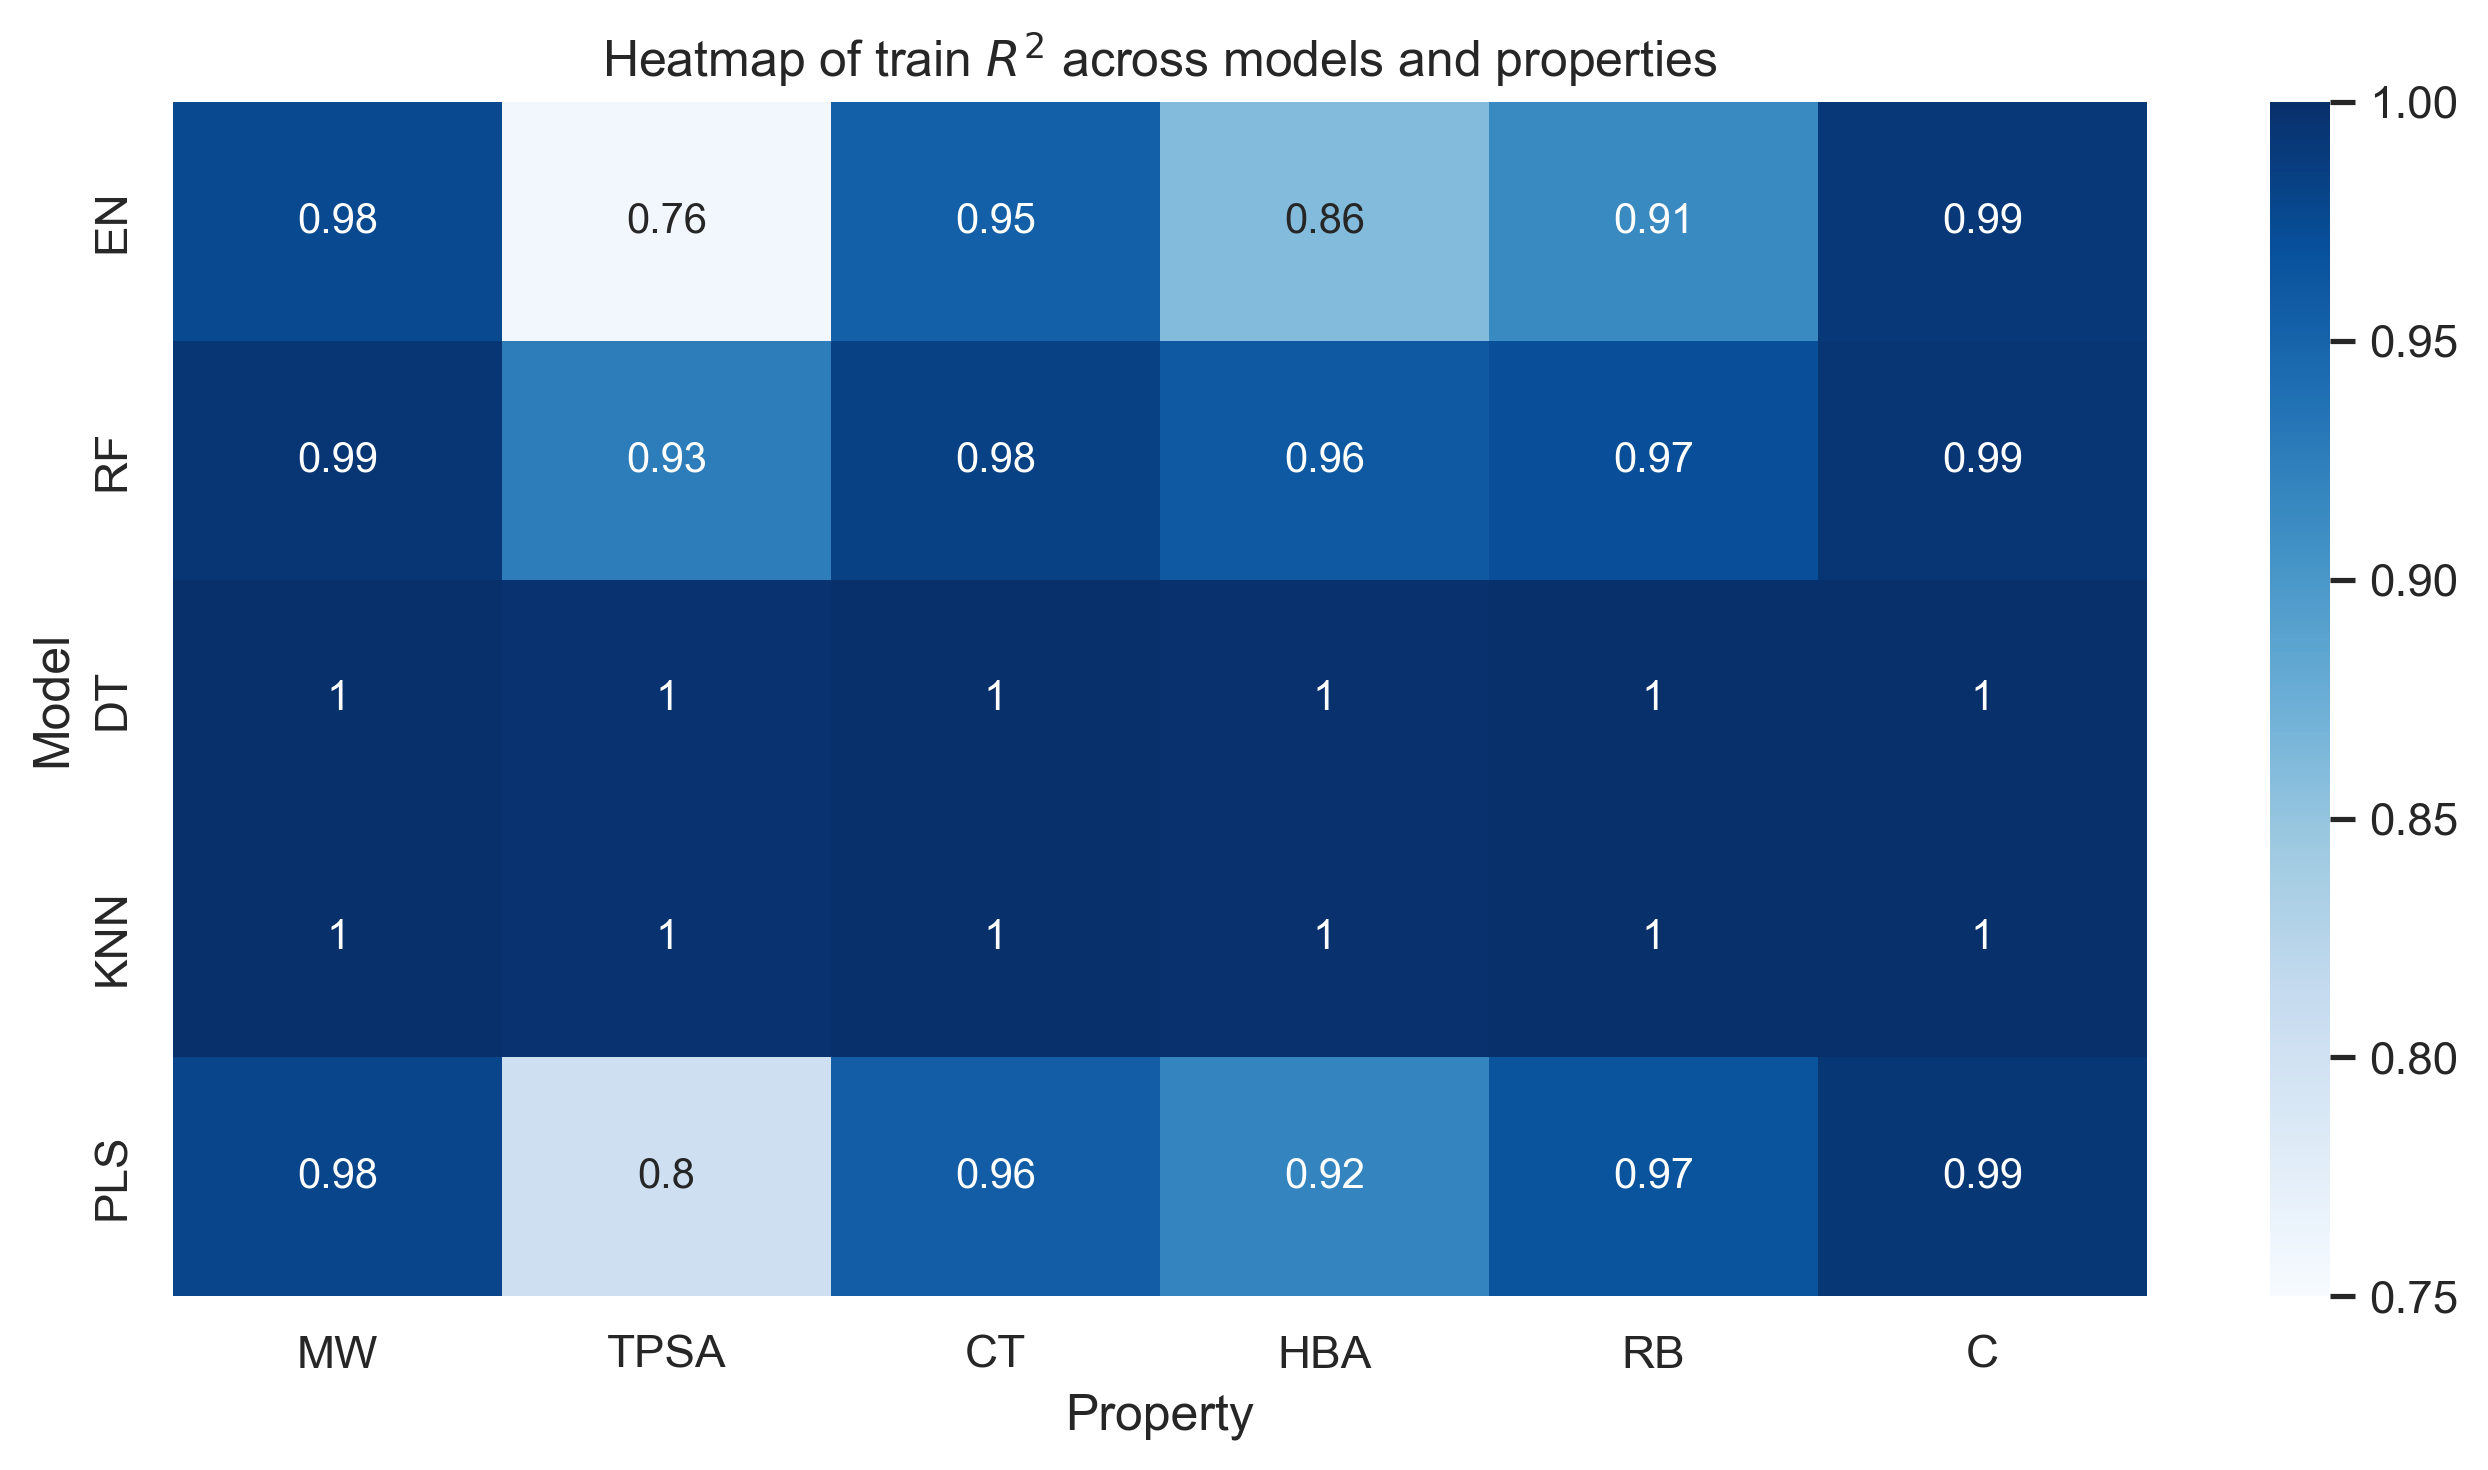

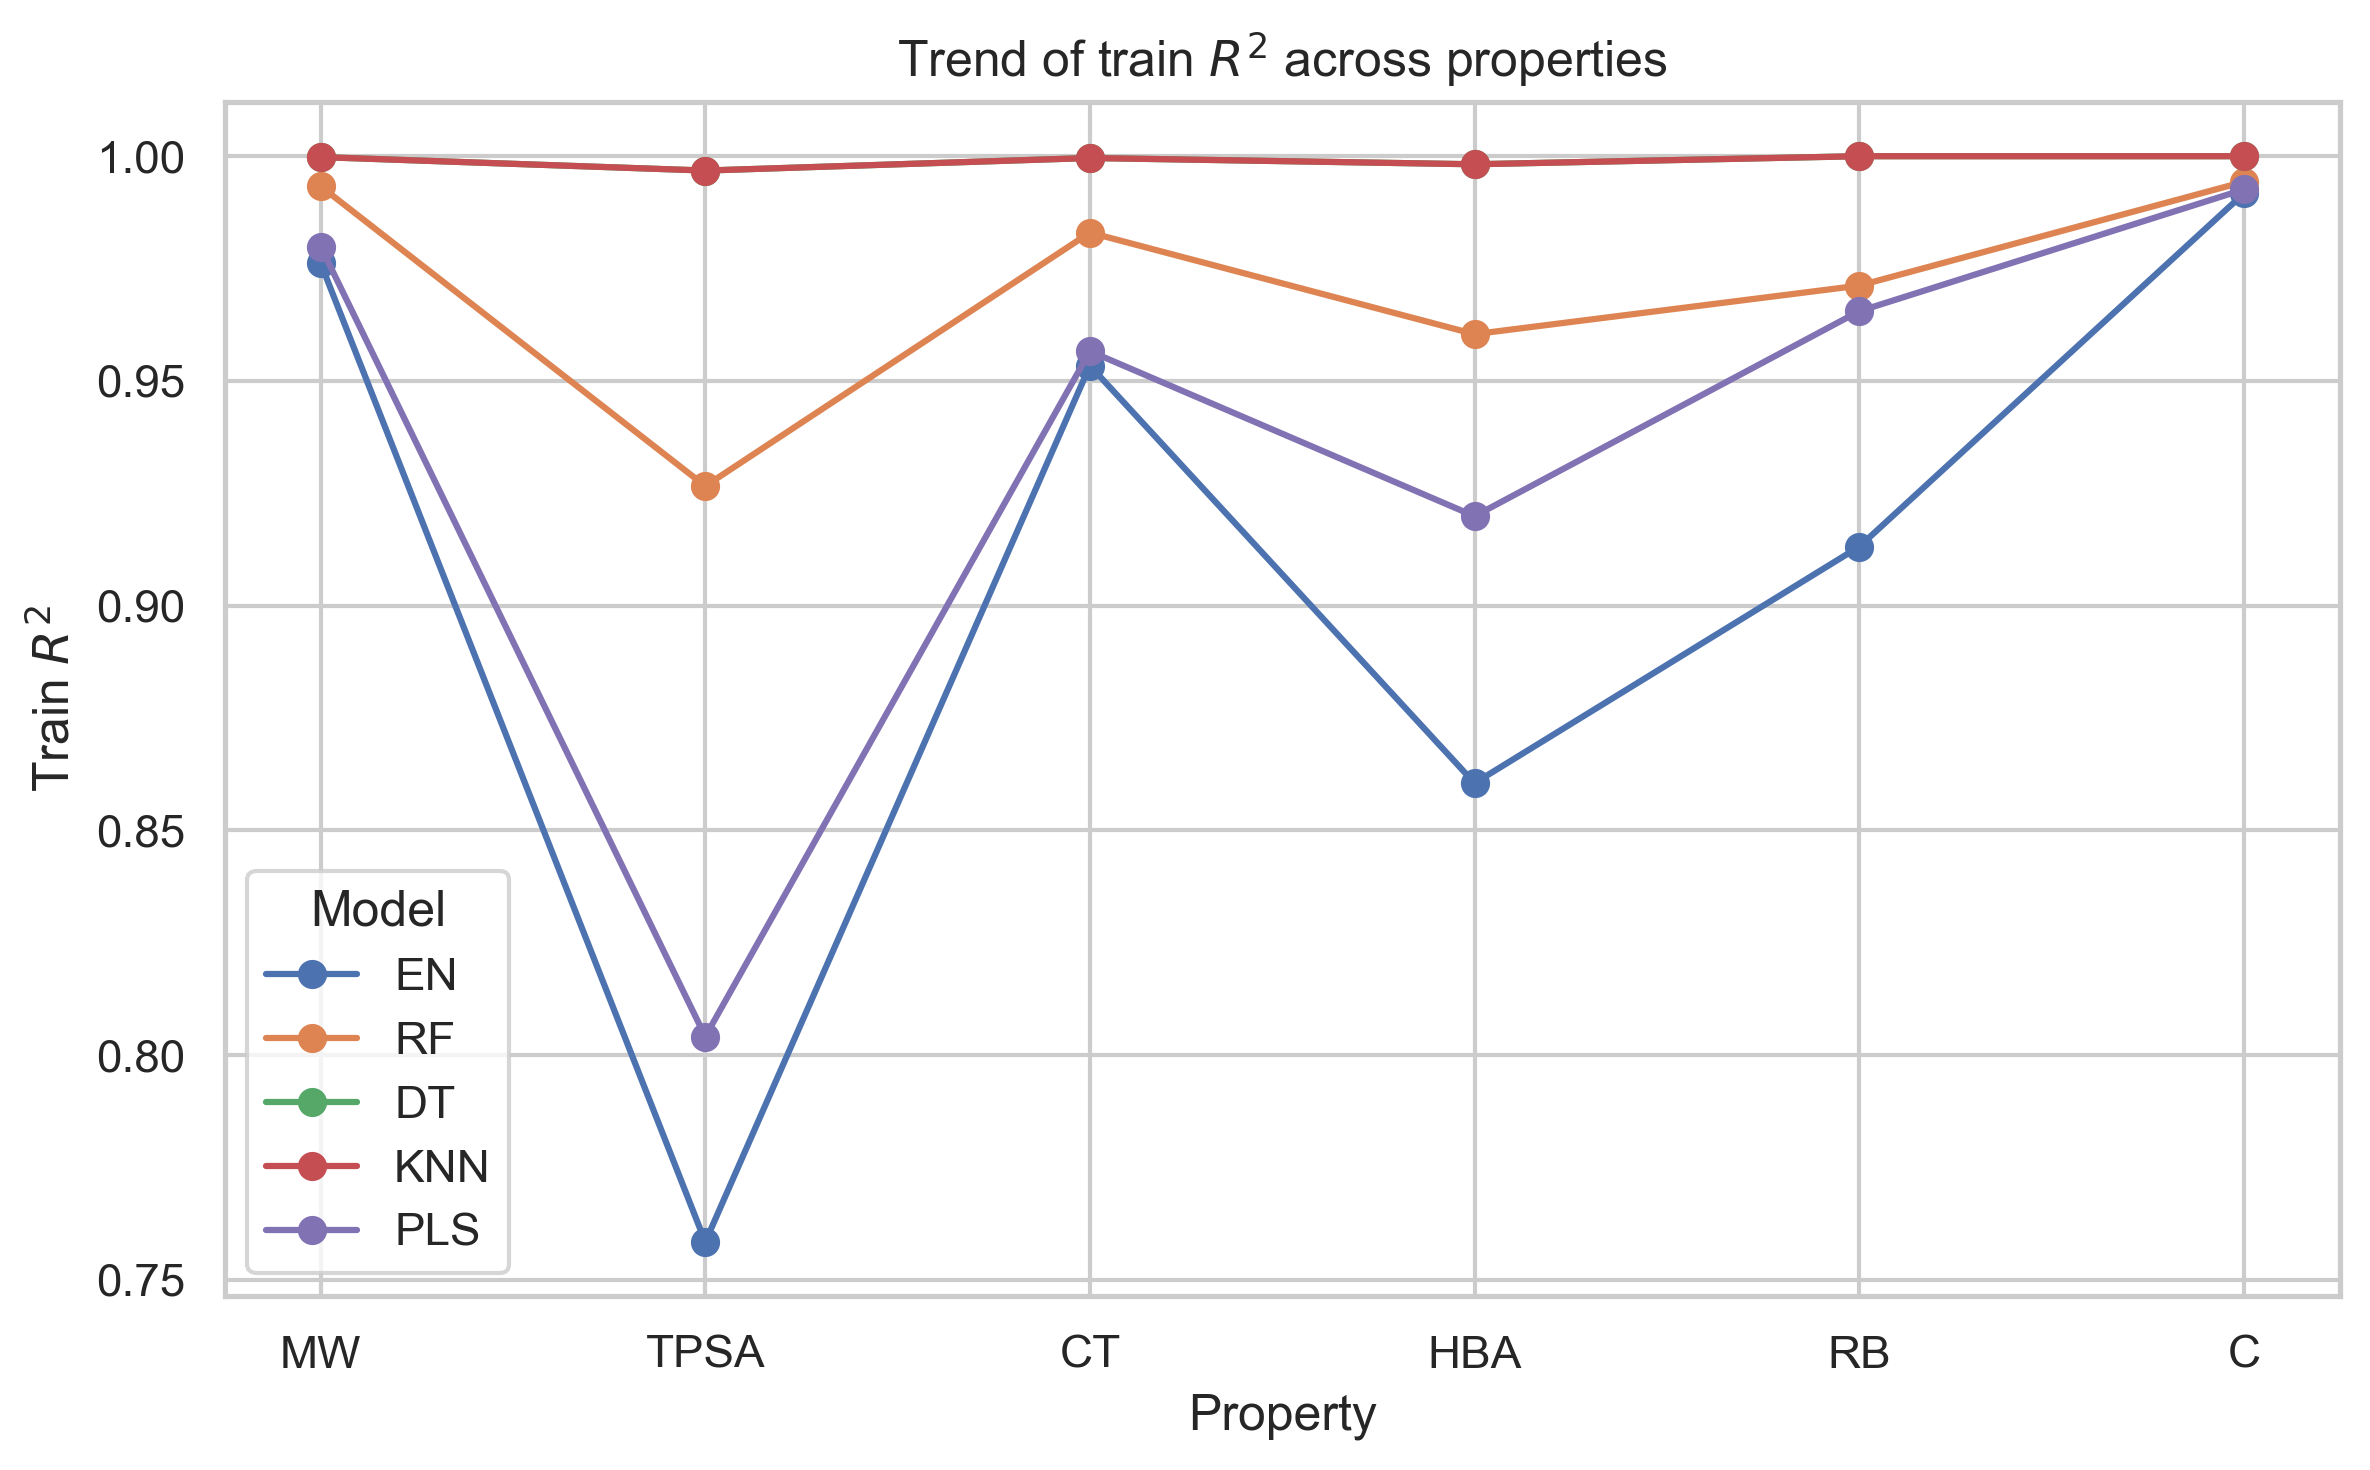

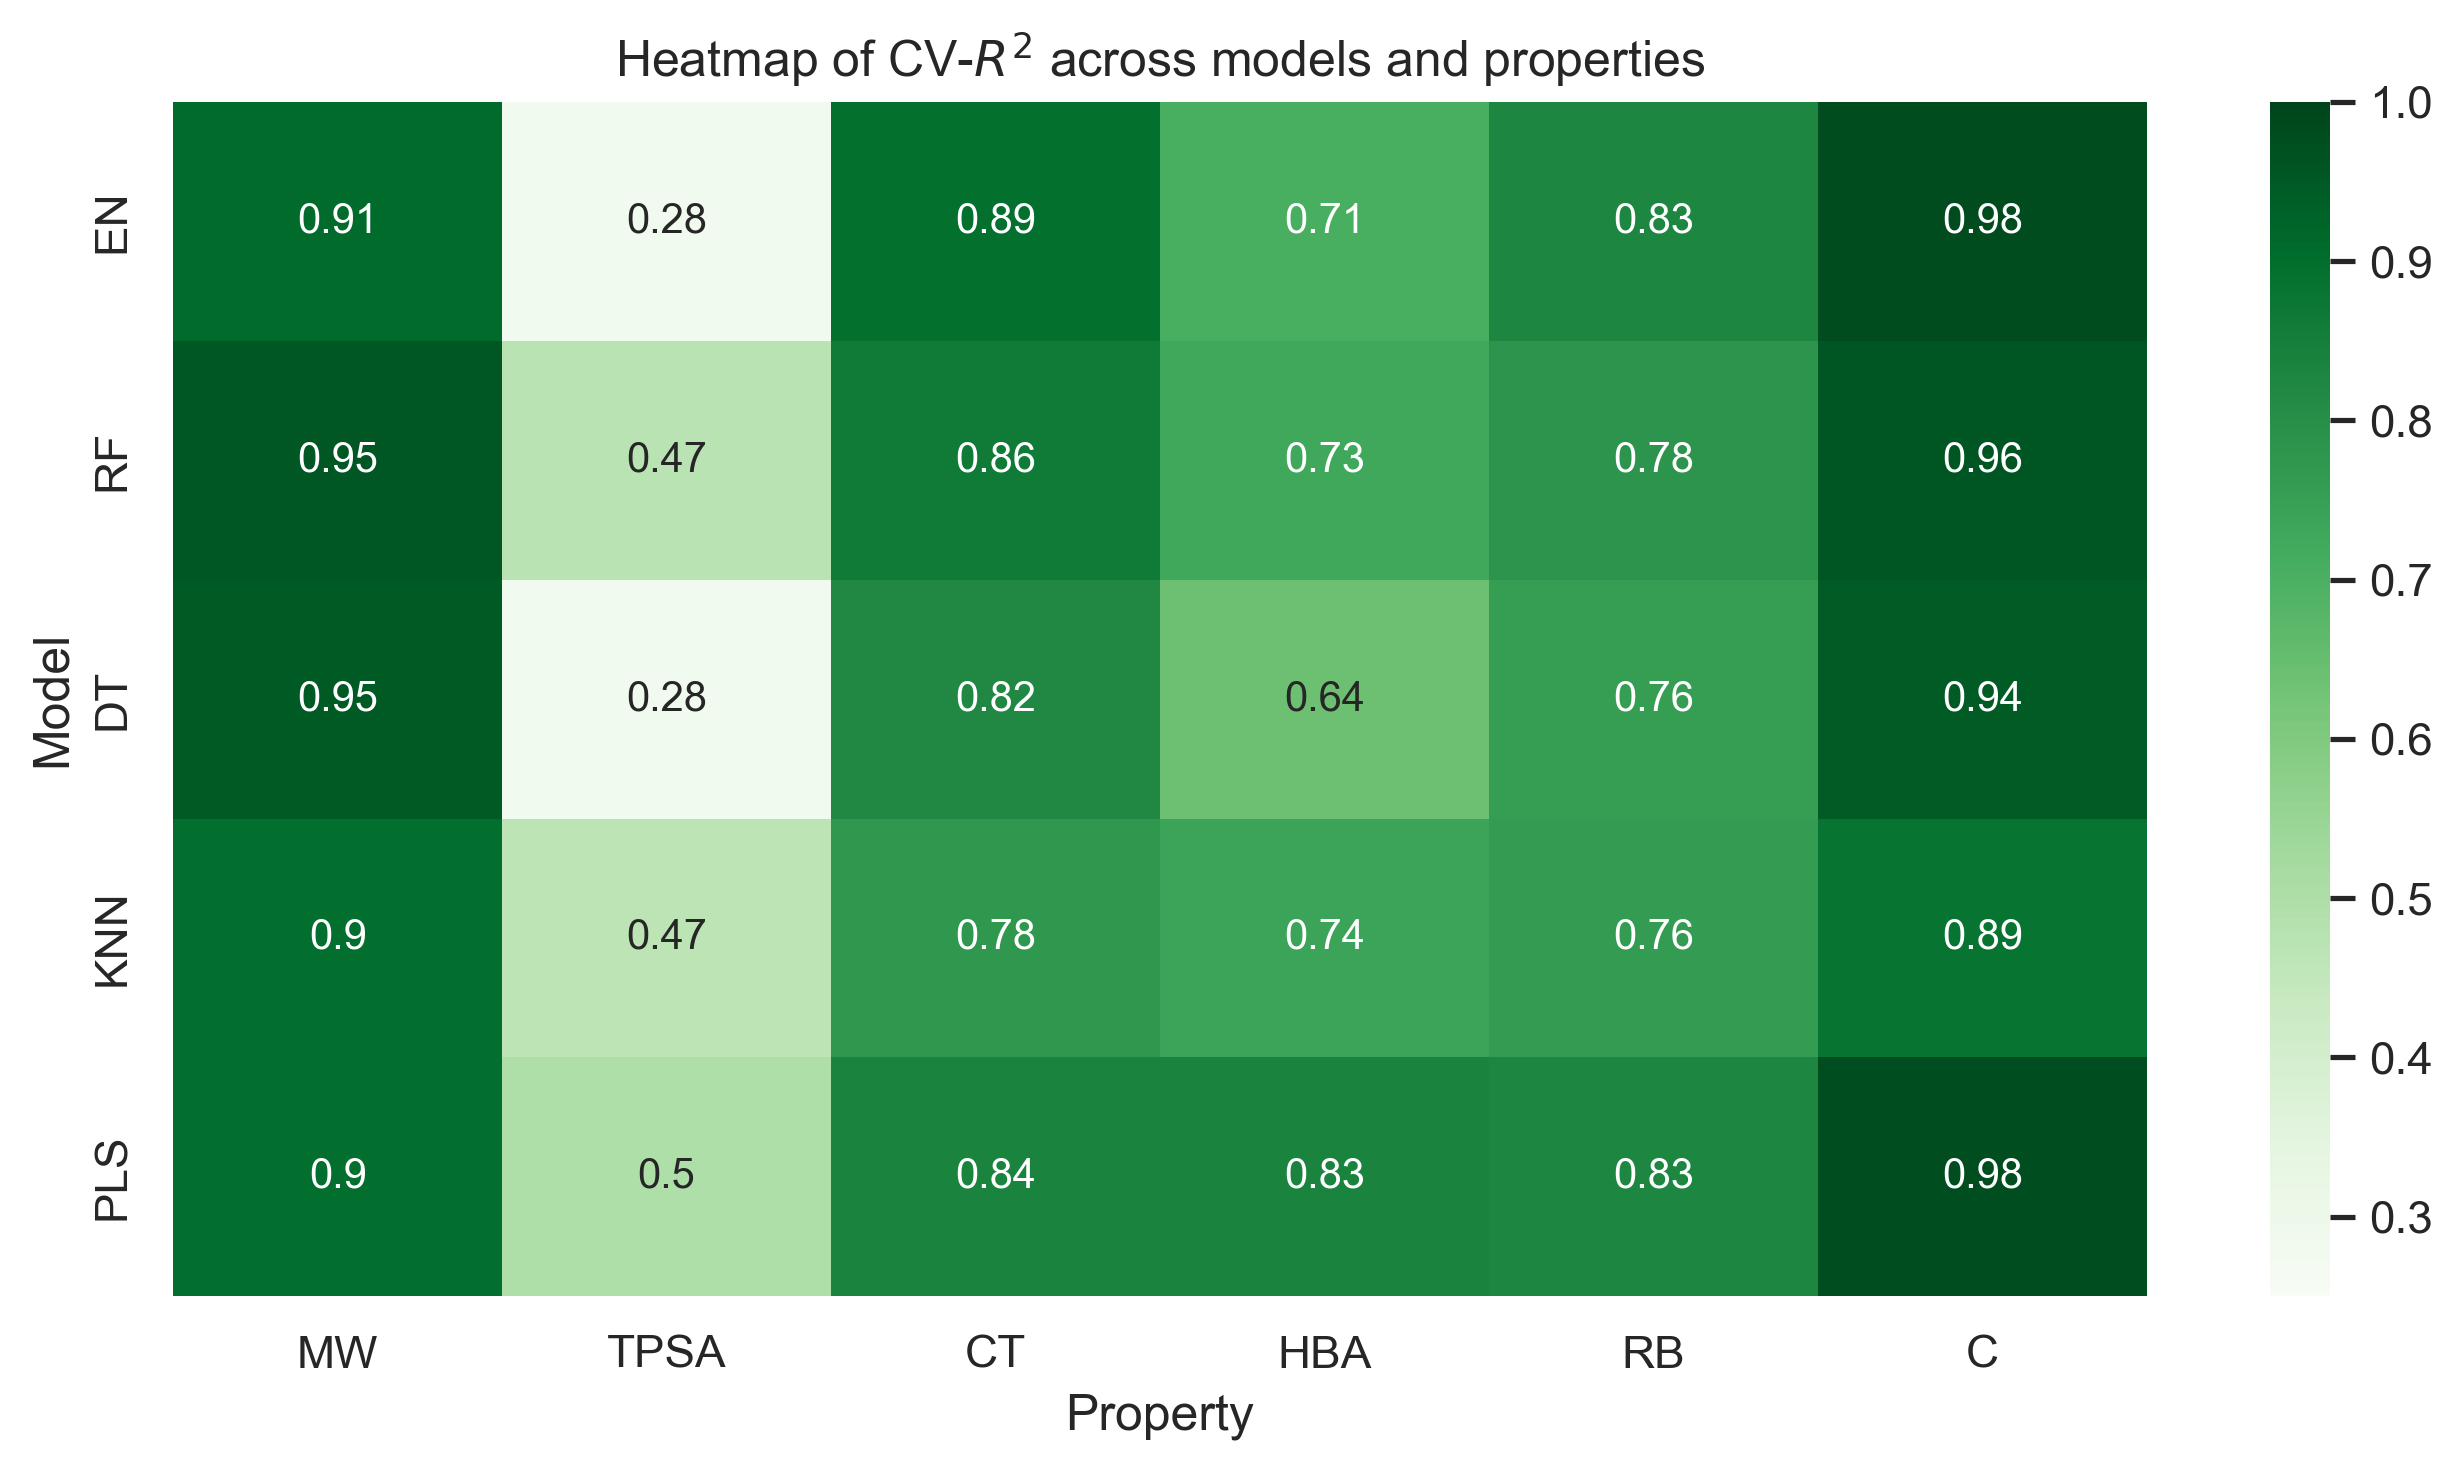

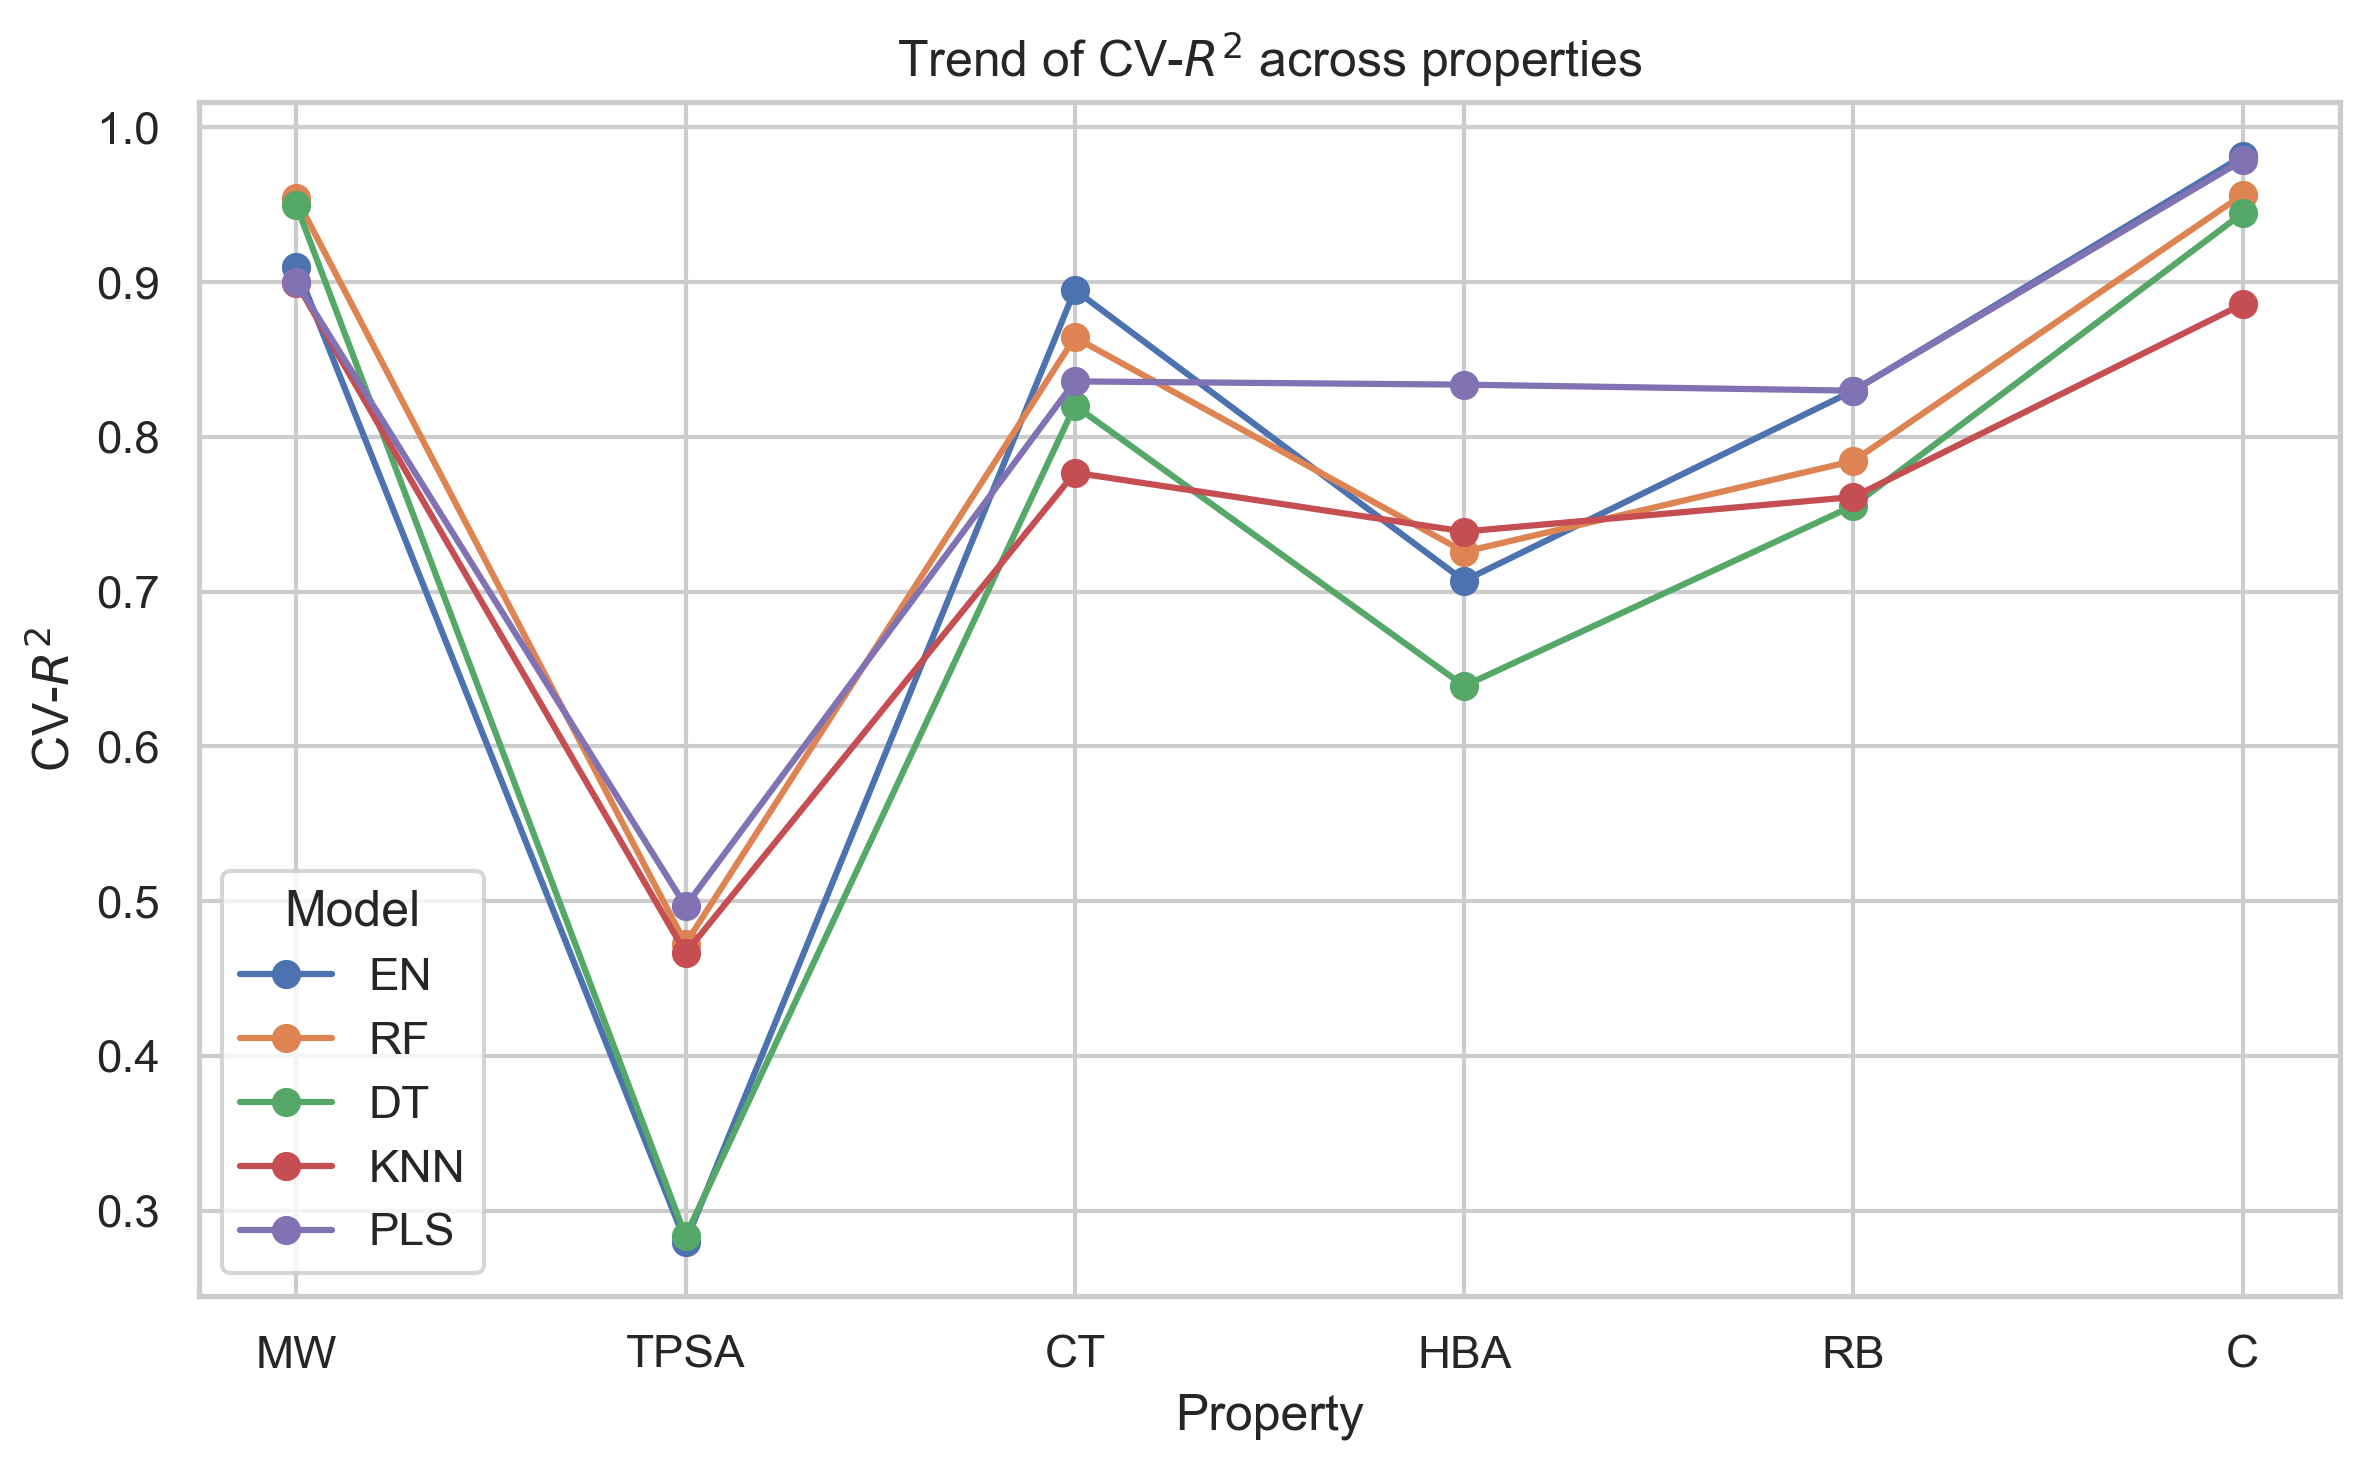

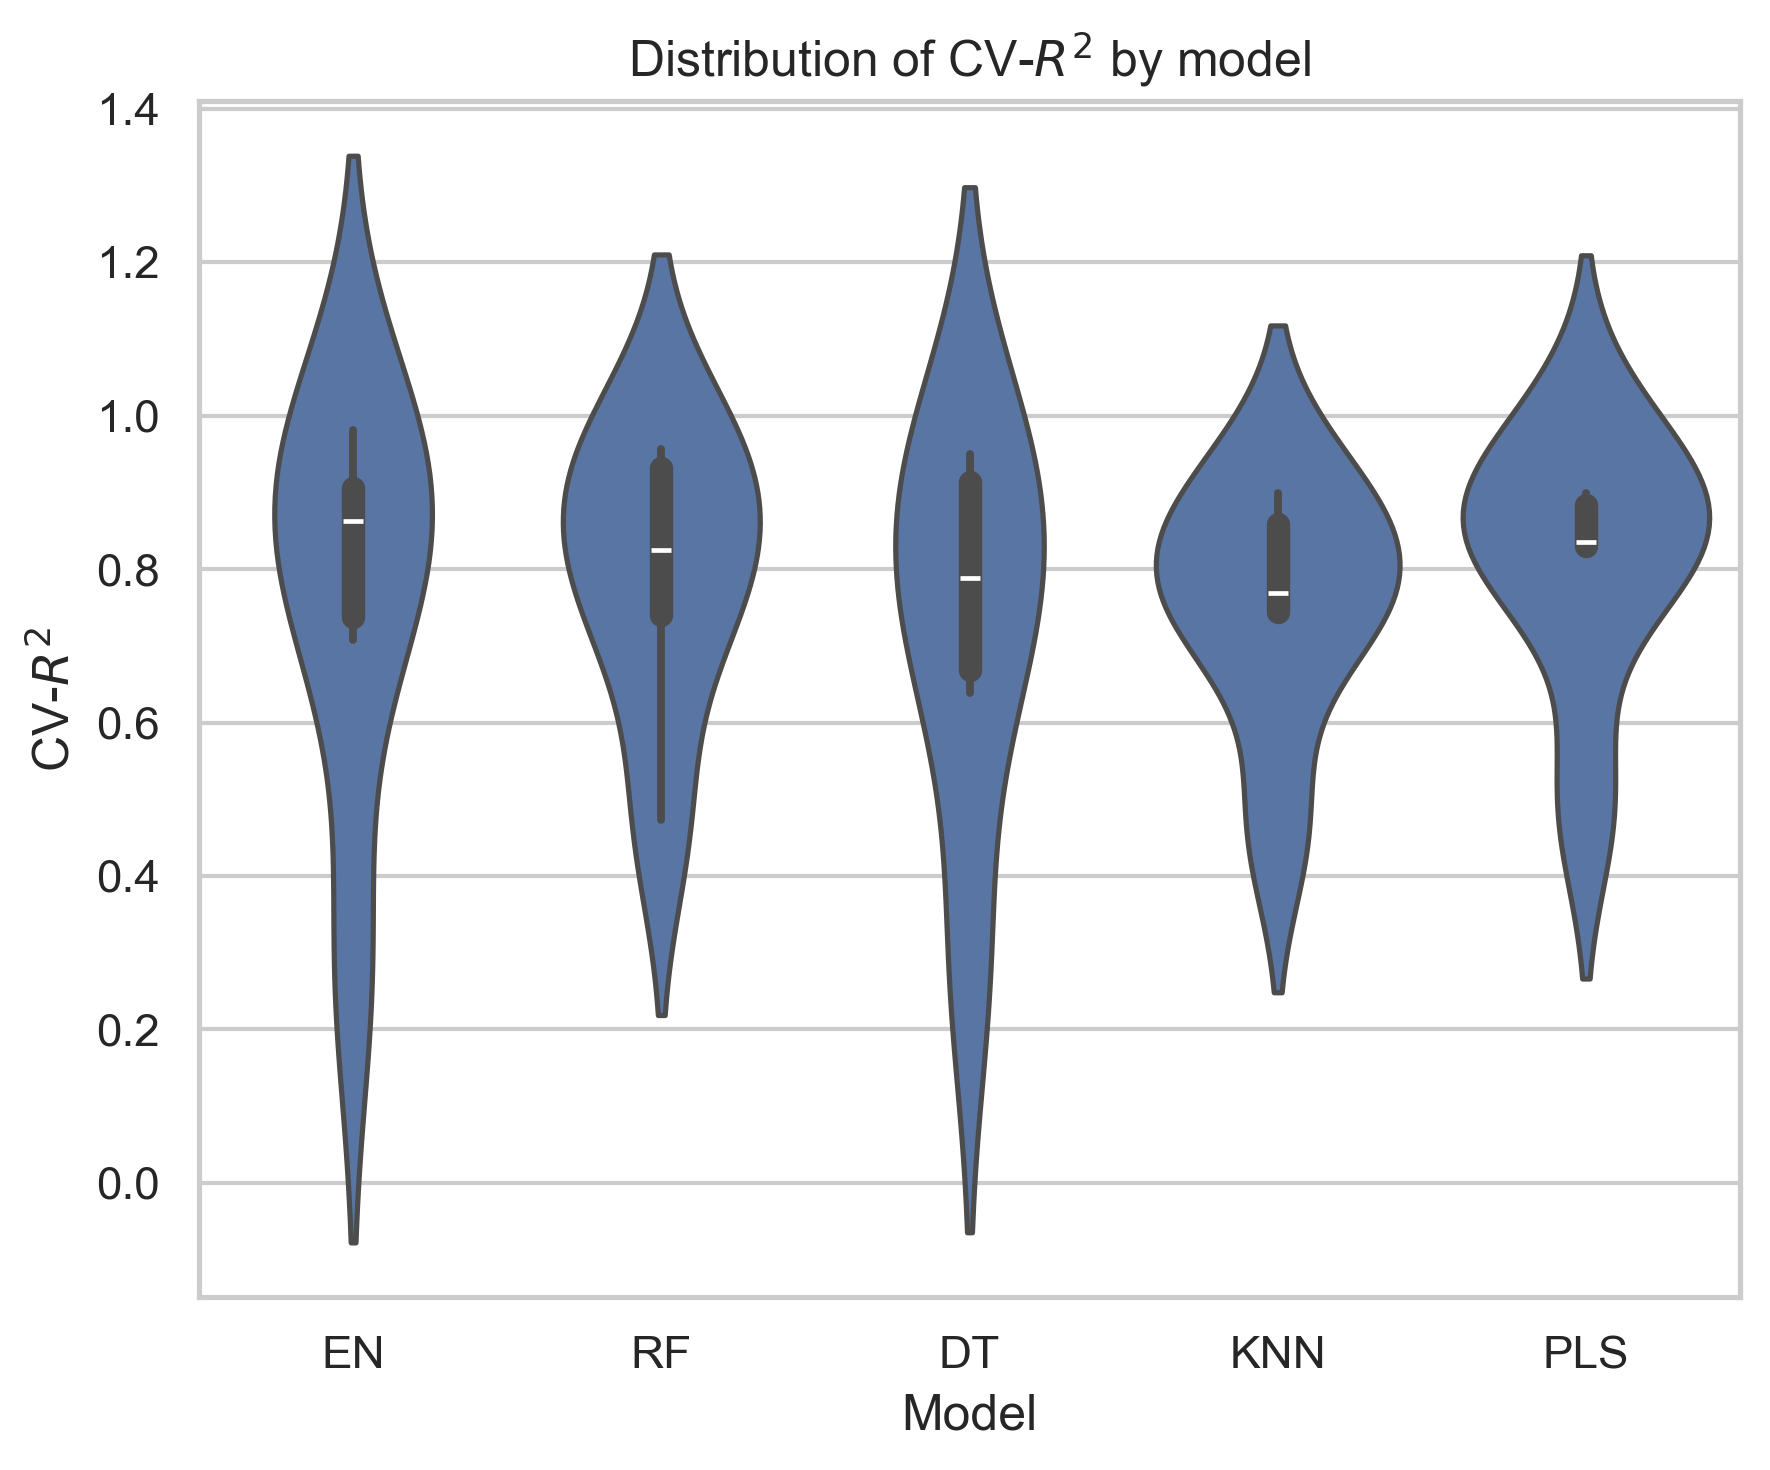

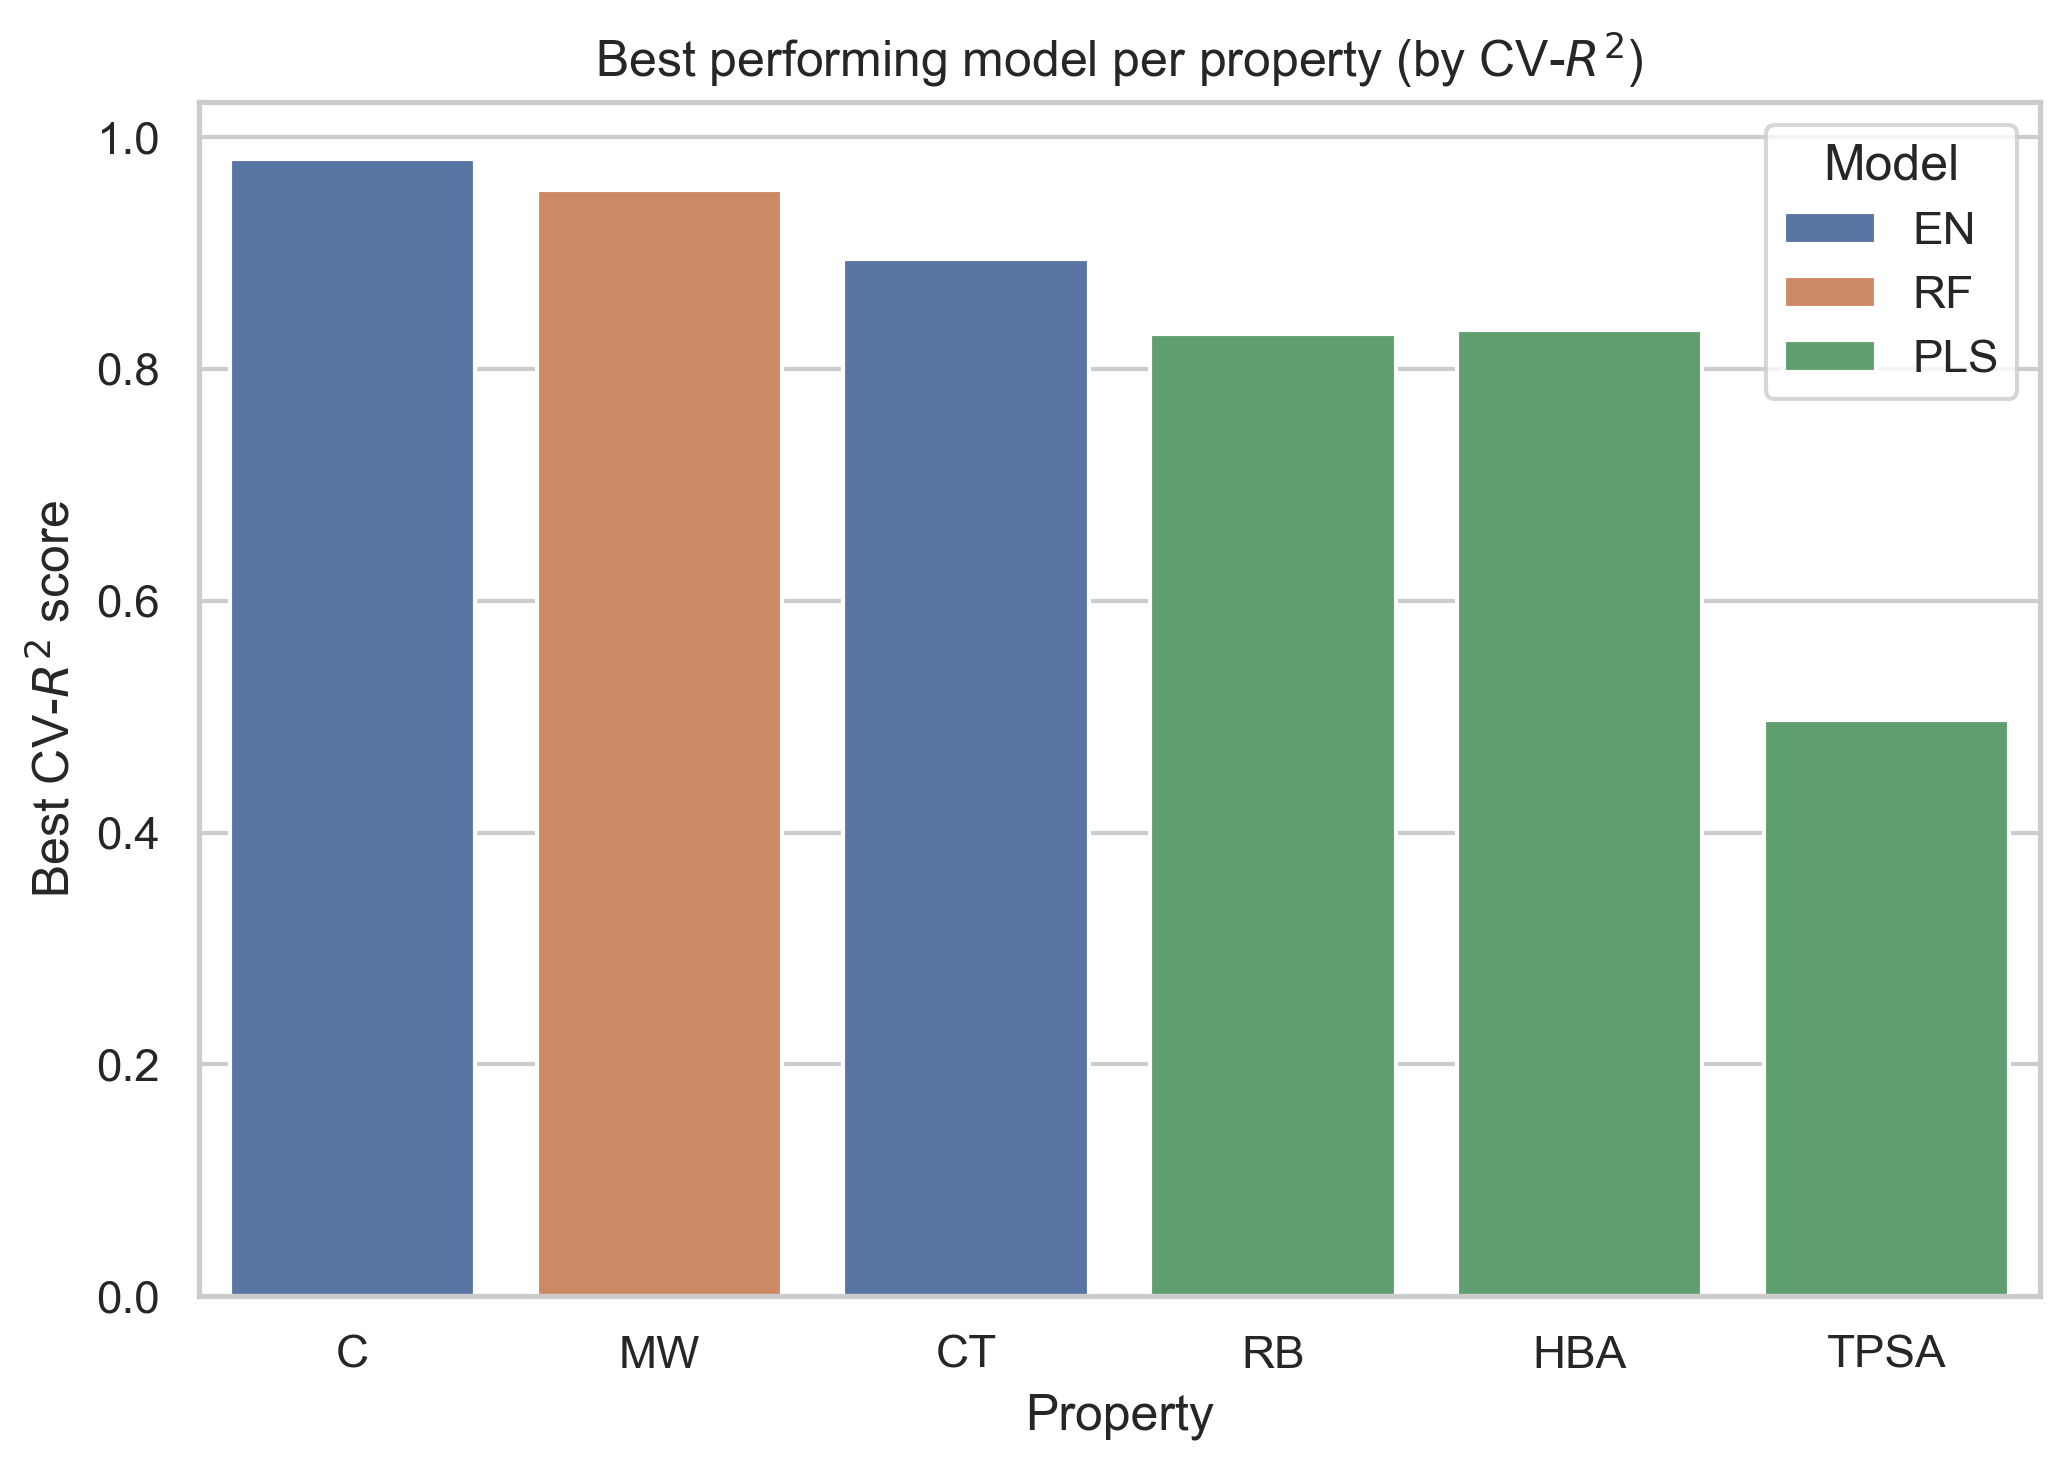

In [3]:
# ============================================================
# Reproduction of Figures 1, 2, CV-R² violin, and Figure 4
# Train R² violin intentionally excluded
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Global plot settings (same style as paper)
# ------------------------------------------------------------
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 10

# ============================================================
# 1. TRAIN R² DATA (Tables 3–8)
# ============================================================

train_r2 = pd.DataFrame({
    "MW":   [0.9762, 0.9933, 0.9998, 0.9998, 0.9799],
    "TPSA": [0.7584, 0.9266, 0.9968, 0.9968, 0.8041],
    "CT":   [0.9534, 0.9830, 0.9996, 0.9996, 0.9566],
    "HBA":  [0.8605, 0.9604, 0.9982, 0.9982, 0.9199],
    "RB":   [0.9131, 0.9712, 1.0000, 1.0000, 0.9655],
    "C":    [0.9917, 0.9943, 1.0000, 1.0000, 0.9926]
}, index=["EN", "RF", "DT", "KNN", "PLS"])

# ============================================================
# FIGURE 1: Heatmap + Line plot (Train R²)
# ============================================================

plt.figure(figsize=(9, 5))
sns.heatmap(
    train_r2,
    annot=True,
    cmap="Blues",
    vmin=0.75,
    vmax=1.0
)
plt.title("Heatmap of train $R^2$ across models and properties")
plt.xlabel("Property")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for model in train_r2.index:
    plt.plot(
        train_r2.columns,
        train_r2.loc[model],
        marker='o',
        label=model
    )

plt.ylabel("Train $R^2$")
plt.xlabel("Property")
plt.title("Trend of train $R^2$ across properties")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 2. CV R² DATA (Tables 3–8)
# ============================================================

cv_r2 = pd.DataFrame({
    "MW":   [0.9098, 0.9542, 0.9497, 0.8995, 0.8998],
    "TPSA": [0.2798, 0.4725, 0.2836, 0.4665, 0.4968],
    "CT":   [0.8949, 0.8642, 0.8202, 0.7768, 0.8358],
    "HBA":  [0.7070, 0.7257, 0.6390, 0.7388, 0.8337],
    "RB":   [0.8298, 0.7844, 0.7555, 0.7611, 0.8298],
    "C":    [0.9813, 0.9564, 0.9445, 0.8857, 0.9786]
}, index=["EN", "RF", "DT", "KNN", "PLS"])

# ============================================================
# FIGURE 2: Heatmap + Line plot (CV R²)
# ============================================================

plt.figure(figsize=(9, 5))
sns.heatmap(
    cv_r2,
    annot=True,
    cmap="Greens",
    vmin=0.25,
    vmax=1.0
)
plt.title("Heatmap of CV-$R^2$ across models and properties")
plt.xlabel("Property")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for model in cv_r2.index:
    plt.plot(
        cv_r2.columns,
        cv_r2.loc[model],
        marker='o',
        label=model
    )

plt.ylabel("CV-$R^2$")
plt.xlabel("Property")
plt.title("Trend of CV-$R^2$ across properties")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 3: Violin plot of CV R² ONLY
# ============================================================

cv_long = (
    cv_r2
    .reset_index()
    .melt(id_vars="index", var_name="Property", value_name="CV_R2")
    .rename(columns={"index": "Model"})
)

plt.figure(figsize=(6, 5))
sns.violinplot(
    x="Model",
    y="CV_R2",
    data=cv_long
)
plt.title("Distribution of CV-$R^2$ by model")
plt.ylabel("CV-$R^2$")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 4: Best performing model per property (Table 9)
# ============================================================

best_models = pd.DataFrame({
    "Property": ["C", "MW", "CT", "RB", "HBA", "TPSA"],
    "Best_CV_R2": [0.9813, 0.9542, 0.8949, 0.8298, 0.8337, 0.4968],
    "Model": ["EN", "RF", "EN", "PLS", "PLS", "PLS"]
})

plt.figure(figsize=(7, 5))
sns.barplot(
    x="Property",
    y="Best_CV_R2",
    hue="Model",
    data=best_models
)
plt.ylabel("Best CV-$R^2$ score")
plt.title("Best performing model per property (by CV-$R^2$)")
plt.legend(title="Model")
plt.tight_layout()
plt.show()


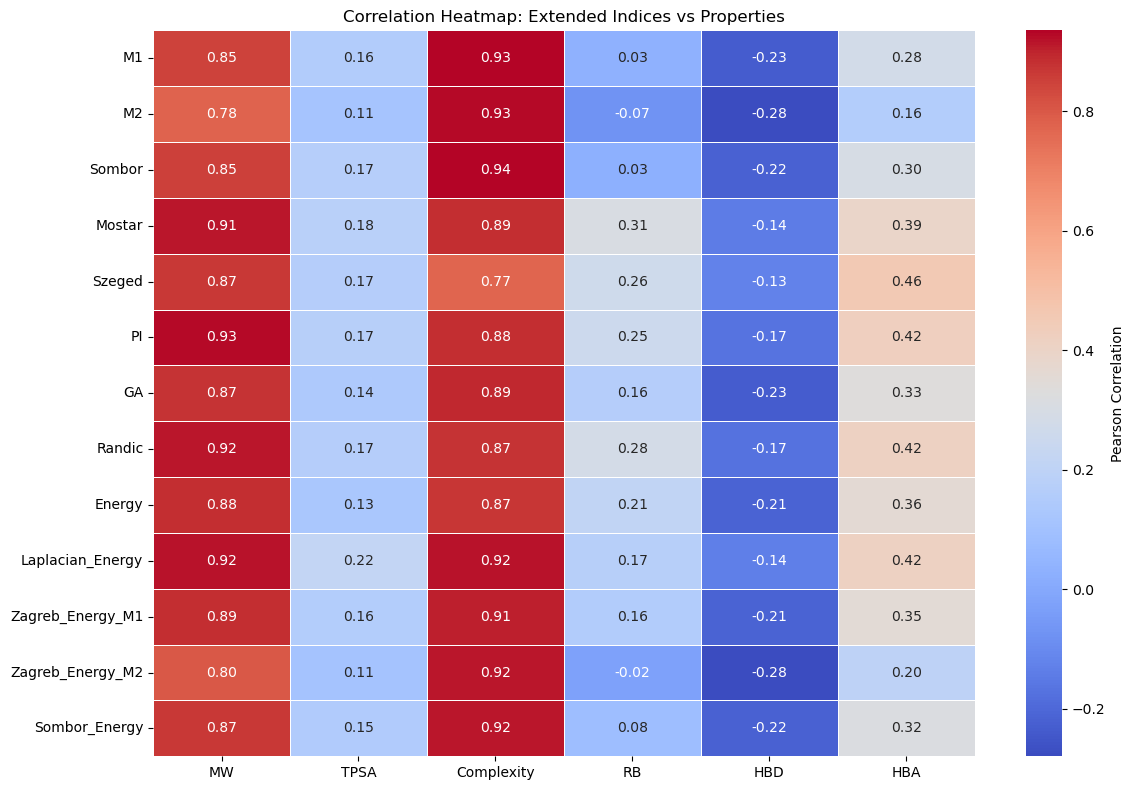

✔ Error fixed. All indices, energies, correlations, and heatmap generated successfully.


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem

# ==========================================================
# 1. Load Cleaned Dataset
# ==========================================================
input_path = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor\Cleaned SMILES.xlsx"
df = pd.read_excel(input_path)

# ==========================================================
# 2. RDKit Molecule → NetworkX Graph
# ==========================================================
def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx())
    for bond in mol.GetBonds():
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
    return G

def degrees(G):
    return dict(G.degree())

# ==========================================================
# 3. Classical Topological Indices
# ==========================================================
def zagreb_m1(G):
    d = degrees(G)
    return sum(v**2 for v in d.values())

def zagreb_m2(G):
    d = degrees(G)
    return sum(d[u] * d[v] for u, v in G.edges())

def sombor_index(G):
    d = degrees(G)
    return sum(np.sqrt(d[u]**2 + d[v]**2) for u, v in G.edges())

def mostar_index(G):
    dists = dict(nx.all_pairs_shortest_path_length(G))
    return sum(
        abs(
            sum(dists[u][w] < dists[v][w] for w in G.nodes) -
            sum(dists[v][w] < dists[u][w] for w in G.nodes)
        )
        for u, v in G.edges()
    )

def szeged_index(G):
    dists = dict(nx.all_pairs_shortest_path_length(G))
    return sum(
        sum(dists[u][w] < dists[v][w] for w in G.nodes) *
        sum(dists[v][w] < dists[u][w] for w in G.nodes)
        for u, v in G.edges()
    )

def pi_index(G):
    dists = dict(nx.all_pairs_shortest_path_length(G))
    return sum(
        sum(dists[u][w] < dists[v][w] for w in G.nodes) +
        sum(dists[v][w] < dists[u][w] for w in G.nodes)
        for u, v in G.edges()
    )

def ga_index(G):
    d = degrees(G)
    return sum((2 * np.sqrt(d[u] * d[v])) / (d[u] + d[v]) for u, v in G.edges())

def randic_index(G):
    d = degrees(G)
    return sum(1 / np.sqrt(d[u] * d[v]) for u, v in G.edges())

# ==========================================================
# 4. Energy-Based Indices
# ==========================================================
def graph_energy(G):
    A = nx.to_numpy_array(G)
    return np.sum(np.abs(np.linalg.eigvals(A)))

def laplacian_energy(G):
    L = nx.laplacian_matrix(G).toarray()
    eigvals = np.linalg.eigvals(L)
    n = G.number_of_nodes()
    return np.sum(np.abs(eigvals - np.trace(L) / n))

def zagreb_energy_m1(G):
    d = np.array(list(degrees(G).values()))
    return np.sum(np.abs(d))

def zagreb_energy_m2(G):
    d = degrees(G)
    M = nx.to_numpy_array(G)
    for u, v in G.edges():
        M[u, v] = d[u] * d[v]
        M[v, u] = d[u] * d[v]
    return np.sum(np.abs(np.linalg.eigvals(M)))

def sombor_energy(G):
    d = degrees(G)
    S = np.zeros((G.number_of_nodes(), G.number_of_nodes()))
    for u, v in G.edges():
        S[u, v] = np.sqrt(d[u]**2 + d[v]**2)
        S[v, u] = S[u, v]
    return np.sum(np.abs(np.linalg.eigvals(S)))

# ==========================================================
# 5. Compute All Indices Safely
# ==========================================================
index_functions = {
    "M1": zagreb_m1,
    "M2": zagreb_m2,
    "Sombor": sombor_index,
    "Mostar": mostar_index,
    "Szeged": szeged_index,
    "PI": pi_index,
    "GA": ga_index,
    "Randic": randic_index,
    "Energy": graph_energy,
    "Laplacian_Energy": laplacian_energy,
    "Zagreb_Energy_M1": zagreb_energy_m1,
    "Zagreb_Energy_M2": zagreb_energy_m2,
    "Sombor_Energy": sombor_energy
}

# Compute values row-wise
for name, func in index_functions.items():
    df[name] = df["SMILES"].apply(lambda smi: func(mol_to_graph(smi)))

# ==========================================================
# 6. Correlation Analysis
# ==========================================================
properties = ["MW", "TPSA", "Complexity", "RB", "HBD", "HBA"]
indices = list(index_functions.keys())

corr = df[indices + properties].corr().loc[indices, properties]

# ==========================================================
# 7. Save Results
# ==========================================================
excel_out = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor\Extended_Indices_and_Correlations.xlsx"
with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Indices", index=False)
    corr.to_excel(writer, sheet_name="Correlations")

# ==========================================================
# 8. Heatmap
# ==========================================================
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.4,
    cbar_kws={"label": "Pearson Correlation"}
)
plt.title("Correlation Heatmap: Extended Indices vs Properties")
plt.tight_layout()
plt.show()

print("✔ Error fixed. All indices, energies, correlations, and heatmap generated successfully.")


In [6]:
# ================================================================
# CLASSICAL QSPR PIPELINE
# Linear + Quadratic Models
# Validation + Visualization (Q1 Ready)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import LeaveOneOut, train_test_split
from sklearn.metrics import r2_score

# ================================================================
# 1. PATHS
# ================================================================
base_path = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor"

corr_df = pd.read_excel(base_path + r"\Best correlations.xlsx", index_col=0)
data_df = pd.read_excel(base_path + r"\complete data.xlsx")

corr_df.index = corr_df.index.astype(str).str.strip()
data_df.columns = data_df.columns.astype(str).str.strip()

# ================================================================
# 2. FUNCTIONS
# ================================================================
def loo_q2(model, X, y):
    loo = LeaveOneOut()
    preds = []
    for tr, ts in loo.split(X):
        model.fit(X[tr], y[tr])
        preds.append(model.predict(X[ts])[0])
    preds = np.array(preds)
    return 1 - np.sum((y - preds)**2) / np.sum((y - np.mean(y))**2)

def leverage(X):
    H = X @ np.linalg.pinv(X.T @ X) @ X.T
    return np.diagonal(H)

# ================================================================
# 3. TARGET PROPERTIES
# ================================================================
properties = ["MW", "Complexity"]

results = []

# ================================================================
# 4. MODELING + VISUALIZATION
# ================================================================
for prop in properties:

    desc = corr_df[prop].abs().idxmax()
    X = data_df[[desc]].values
    y = data_df[prop].values

    mask = ~np.isnan(X).flatten() & ~np.isnan(y)
    X, y = X[mask], y[mask]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    q2 = loo_q2(model, X, y)

    # ---------------- Observed vs Predicted ----------------
    plt.figure()
    plt.scatter(y, y_pred)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], '--')
    plt.xlabel("Observed")
    plt.ylabel("Predicted")
    plt.title(f"{prop}: Observed vs Predicted")
    plt.savefig(base_path + fr"\{prop}_Obs_vs_Pred.png", dpi=300)
    plt.close()

    # ---------------- Residuals Plot ----------------
    plt.figure()
    plt.scatter(y, y - y_pred)
    plt.axhline(0, linestyle='--')
    plt.xlabel("Observed")
    plt.ylabel("Residuals")
    plt.title(f"{prop}: Residuals vs Observed")
    plt.savefig(base_path + fr"\{prop}_Residuals.png", dpi=300)
    plt.close()

    # ---------------- Williams Plot ----------------
    h = leverage(X)
    h_star = 3*(X.shape[1]+1)/X.shape[0]
    std_res = (y - y_pred) / np.std(y - y_pred)

    plt.figure()
    plt.scatter(h, std_res)
    plt.axhline(3, linestyle='--')
    plt.axhline(-3, linestyle='--')
    plt.axvline(h_star, linestyle='--')
    plt.xlabel("Leverage")
    plt.ylabel("Standardized Residuals")
    plt.title(f"{prop}: Williams Plot")
    plt.savefig(base_path + fr"\{prop}_Williams.png", dpi=300)
    plt.close()

    results.append([prop, desc, r2, q2])

# ================================================================
# 5. SAVE RESULTS
# ================================================================
pd.DataFrame(results, columns=[
    "Property", "Descriptor", "R2", "Q2_LOO"
]).to_excel(base_path + r"\Classical_QSPR_Final.xlsx", index=False)

print("✔ Classical QSPR + Visuals Completed")


✔ Classical QSPR + Visuals Completed


In [7]:
# ==========================================================
# ML QSPR PIPELINE
# Repeated External Validation + Visualization
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import r2_score

# ==========================================================
# 1. LOAD DATA
# ==========================================================
base_path = r"D:\Phd\PhD\Papers on topological indices\30 kinas inhibitor"
df = pd.read_excel(base_path + r"\complete data.xlsx", sheet_name="Indices")

# ==========================================================
# 2. RDKit DESCRIPTORS
# ==========================================================
def rdkit_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    atoms = [a.GetSymbol() for a in mol.GetAtoms()]
    return {
        "NumN": atoms.count("N"),
        "NumO": atoms.count("O"),
        "NumS": atoms.count("S"),
        "NumHeteroatoms": Descriptors.NumHeteroatoms(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "FractionCSP3": Descriptors.FractionCSP3(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "RingCount": Descriptors.RingCount(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "AliphaticRingCount": rdMolDescriptors.CalcNumAliphaticRings(mol),
    }

df = pd.concat([df, df["SMILES"].apply(rdkit_features).apply(pd.Series)], axis=1)

# ==========================================================
# 3. SETUP
# ==========================================================
properties = ["TPSA", "HBA", "RB"]

topo = ["M1","M2","Sombor","Mostar","Szeged","PI","GA",
        "Randic","Energy","Laplacian_Energy"]

chem = ["NumN","NumO","NumS","NumHeteroatoms","HeavyAtomCount",
        "FractionCSP3","MolLogP","RingCount",
        "AromaticRingCount","AliphaticRingCount"]

models = {
    "Linear": (LinearRegression(), False),
    "ElasticNet": (ElasticNetCV(cv=5), True),
    "PLS": (PLSRegression(n_components=3), True)
}

# ==========================================================
# 4. MAIN LOOP
# ==========================================================
for prop in properties:

    y = df[prop].values
    best = df[topo].corrwith(df[prop]).abs().idxmax()
    X = df[[best] + chem].values

    ext_scores = {}

    for name, (model, scale) in models.items():

        r2_list = []

        for seed in range(5):
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=seed
            )

            if scale:
                sc = StandardScaler()
                X_tr = sc.fit_transform(X_tr)
                X_te = sc.transform(X_te)

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_te)
            r2_list.append(r2_score(y_te, y_pred))

            if seed == 0:
                plt.figure()
                plt.scatter(y_te, y_pred)
                plt.plot([y.min(), y.max()], [y.min(), y.max()], '--')
                plt.xlabel("Observed")
                plt.ylabel("Predicted")
                plt.title(f"{prop} ({name}) External Prediction")
                plt.savefig(base_path + fr"\{prop}_{name}_Obs_vs_Pred.png", dpi=300)
                plt.close()

        ext_scores[name] = r2_list

    # ---------------- Boxplot ----------------
    plt.figure()
    plt.boxplot(ext_scores.values(), labels=ext_scores.keys())
    plt.ylabel("External R²")
    plt.title(f"{prop}: External R² Distribution")
    plt.savefig(base_path + fr"\{prop}_External_R2_Boxplot.png", dpi=300)
    plt.close()

print("✔ ML QSPR + Visuals Completed")


C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_20188\1334950300.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ext_scores.values(), labels=ext_scores.keys())
C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_20188\1334950300.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ext_scores.values(), labels=ext_scores.keys())
C:\Users\MuBeeN\AppData\Local\Temp\ipykernel_20188\1334950300.py:108: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(ext_scores.values(), labels=ext_scores.keys())


✔ ML QSPR + Visuals Completed


In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# Input Data
# ------------------------------------------------------------
data = {
    'Neurotransmitter': ['Adrenaline', 'Noradrenaline', 'Dopamine', 'Oxytocin', 'GABA',
                         'Acetylcholine', 'Glutamate', 'Serotonin'],
    'Mo':   [85, 68, 49, 3288, 20, 48, 50, 80],
    'PI':   [143, 120, 99, 4688, 30, 72, 72, 140],
    'Sz':   [216, 168, 130, 30510, 16, 58, 55, 215],
    'GA':   [7.93, 7.26, 7.32, 34.56, 2.75, 3.80, 3.70, 10.07],
    'MW':   [183.2, 169.18, 153.18, 1007.2, 103.12, 146.21, 147.13, 212.67],
    'PSA':  [72.7, 86.7, 66.5, 450, 63.3, 26.3, 101, 62],
    'Complexity': [154, 142, 119, 1870, 62.7, 115, 145, 174],
    'Solubility': [0.1, 50, 600, 55, 0.0012, 500, 8570, 0.0319],
    'MP':   [412, 217, 128, 192, 203, 148, 205, 167]
}

df = pd.DataFrame(data)

# ------------------------------------------------------------
# Configuration – LINEAR polynomial (degree = 1)
# ------------------------------------------------------------
properties = ['MW', 'PSA', 'Complexity', 'Solubility', 'MP']
indices = ['Mo', 'PI', 'Sz', 'GA']
degree = 1

# ------------------------------------------------------------
# Main loop
# ------------------------------------------------------------
all_results = {}

for index in indices:
    print(f"\n========== Using Index: {index} ==========")
    all_results[index] = {}

    X = df[[index]].values   # feature matrix (n_samples, 1)

    for prop in properties:
        y = df[prop].values

        # --- Polynomial feature transformation (degree=1 → bias + x) ---
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)

        # --- Fit linear regression on polynomial features ---
        model = LinearRegression()
        model.fit(X_poly, y)

        # --- Predictions and error ---
        y_pred = model.predict(X_poly)
        error = y - y_pred

        # --- Metrics ---
        r2 = model.score(X_poly, y)                 # R²
        mse = mean_squared_error(y, y_pred)         # MSE
        rmse = np.sqrt(mse)                         # RMSE

        # --- Store results ---
        result_df = pd.DataFrame({
            'Neurotransmitter': df['Neurotransmitter'],
            'Actual': y,
            'Predicted': y_pred.round(2),
            'Error': error.round(2)
        })
        all_results[index][prop] = result_df

        # --- Print table and metrics ---
        print(f"\n--- Property: {prop} ---")
        print(result_df.to_string(index=False))
        print(f"\nR²    = {r2:.4f}")
        print(f"MSE   = {mse:.4f}")
        print(f"RMSE  = {rmse:.4f}")

        # --- Linear equation (intercept + slope * x) ---
        intercept = model.intercept_
        # For degree=1, coef_[0] is bias (already in intercept), coef_[1] is slope
        slope = model.coef_[1] if len(model.coef_) > 1 else 0.0
        print("\nLinear Equation:")
        print(f"{prop}_{index}(x) = {intercept:.6g} + {slope:.6g} * x\n")


========== Using Index: Mo ==========

--- Property: MW ---
Neurotransmitter  Actual  Predicted  Error
      Adrenaline  183.20     166.41  16.79
   Noradrenaline  169.18     161.94   7.24
        Dopamine  153.18     156.94  -3.76
        Oxytocin 1007.20    1008.30  -1.10
            GABA  103.12     149.32 -46.20
   Acetylcholine  146.21     156.68 -10.47
       Glutamate  147.13     157.21 -10.08
       Serotonin  212.67     165.09  47.58

R²    = 0.9922
MSE   = 619.9074
RMSE  = 24.8979

Linear Equation:
MW_Mo(x) = 144.065 + 0.262845 * x


--- Property: PSA ---
Neurotransmitter  Actual  Predicted  Error
      Adrenaline    72.7      71.64   1.06
   Noradrenaline    86.7      69.63  17.07
        Dopamine    66.5      67.39  -0.89
        Oxytocin   450.0     450.05  -0.05
            GABA    63.3      63.96  -0.66
   Acetylcholine    26.3      67.27 -40.97
       Glutamate   101.0      67.51  33.49
       Serotonin    62.0      71.05  -9.05

R²    = 0.9757
MSE   = 396.9901
RMSE  =

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# SAVE DIRECTORY
# ------------------------------------------------------------
save_path = r"D:\Phd\PhD\Papers on topological indices\Dr. Nasir Ali\Neurotransmitters\Revised manuscript"
os.makedirs(save_path, exist_ok=True)

# ------------------------------------------------------------
# Neurotransmitters
# ------------------------------------------------------------
drugs = [
    "Adrenaline", "Noradrenaline", "Dopamine", "Oxytocin",
    "GABA", "Acetylcholine", "Glutamate", "Serotonin"
]

# ------------------------------------------------------------
# COMPLETE DATA DICTIONARY (CORRECTED)
# ------------------------------------------------------------
data = {

"Mo": {
    "MW": ([183.20,169.18,153.18,1007.20,103.12,146.21,147.13,212.67],
           [166.41,161.94,156.94,1008.30,149.32,156.68,157.21,165.09]),

    "PSA": ([72.7,86.7,66.5,450.0,63.3,26.3,101.0,62.0],
            [71.64,69.63,67.39,450.05,63.96,67.27,67.51,71.05]),

    "Complexity": ([154.0,142.0,119.0,1870.0,62.7,115.0,145.0,174.0],
                   [145.13,135.97,125.73,1870.87,110.11,125.19,126.27,142.43]),

    "S": ([0.1000,50.0000,600.0000,55.0000,0.0012,500.0000,8570.0000,0.0319],
          [1379.93,1387.07,1395.06,33.69,1407.25,1395.48,1394.64,1382.03]),

    "MP": ([412,217,128,192,203,148,205,167],
           [211.00,211.09,211.19,193.94,211.35,211.20,211.19,211.03])
},

"PI": {
    "MW": ([183.20,169.18,153.18,1007.20,103.12,146.21,147.13,212.67],
           [167.64,163.39,159.50,1008.53,146.73,154.51,154.51,167.09]),

    "PSA": ([72.7,86.7,66.5,450.0,63.3,26.3,101.0,62.0],
            [72.21,70.30,68.56,450.01,62.82,66.31,66.31,71.97]),

    "Complexity": ([154.0,142.0,119.0,1870.0,62.7,115.0,145.0,174.0],
                   [147.72,139.00,131.04,1870.84,104.88,120.81,120.81,146.59]),

    "S": ([0.1000,50.0000,600.0000,55.0000,0.0012,500.0000,8570.0000,0.0319],
          [1381.31,1388.27,1394.61,7.71,1415.47,1402.77,1402.77,1382.22]),

    "MP": ([412,217,128,192,203,148,205,167],
           [210.96,211.04,211.12,194.10,211.38,211.22,211.22,210.97])
},

"Sz": {
    "MW": ([183.20,169.18,153.18,1007.20,103.12,146.21,147.13,212.67],
           [161.78,160.44,159.38,1007.66,156.20,157.37,157.29,161.76]),

    "PSA": ([72.7,86.7,66.5,450.0,63.3,26.3,101.0,62.0],
            [69.53,68.92,68.44,450.04,67.01,67.54,67.50,69.51]),

    "Complexity": ([154.0,142.0,119.0,1870.0,62.7,115.0,145.0,174.0],
                   [135.54,132.79,130.61,1870.38,124.09,126.49,126.32,135.48]),

    "S": ([0.1000,50.0000,600.0000,55.0000,0.0012,500.0000,8570.0000,0.0319],
          [1387.25,1389.40,1391.09,35.16,1396.18,1394.31,1394.44,1387.30]),

    "MP": ([412,217,128,192,203,148,205,167],
           [211.28,211.31,211.33,192.65,211.40,211.38,211.38,211.28])
},

"GA": {
    "MW": ([183.20,169.18,153.18,1007.20,103.12,146.21,147.13,212.67],
           [215.13,195.88,197.60,980.36,66.28,96.45,93.58,276.62]),

    "PSA": ([72.7,86.7,66.5,450.0,63.3,26.3,101.0,62.0],
            [93.95,85.46,86.22,431.59,28.28,41.59,40.32,121.09]),

    "Complexity": ([154.0,142.0,119.0,1870.0,62.7,115.0,145.0,174.0],
                   [246.29,207.32,210.81,1795.16,-54.99,6.08,0.26,370.76]),

    "S": ([0.1000,50.0000,600.0000,55.0000,0.0012,500.0000,8570.0000,0.0319],
          [1347.79,1396.17,1391.84,-574.92,1721.79,1645.98,1653.20,1193.28]),

    "MP": ([412,217,128,192,203,148,205,167],
           [209.46,209.64,209.62,202.43,210.83,210.55,210.58,208.90])
}

}

# ------------------------------------------------------------
# PLOTTING FUNCTION
# ------------------------------------------------------------
def plot_index(index_name, short):

    index_data = data[index_name]
    properties = list(index_data.keys())
    x = np.arange(len(drugs))

    # ================= LINE PLOT =================
    plt.figure(figsize=(12,7))
    for prop in properties:
        actual, predicted = index_data[prop]
        plt.plot(drugs, actual, marker='o', label=f"{prop} A")
        plt.plot(drugs, predicted, linestyle='--', marker='x', label=f"{prop} P")

    plt.xticks(rotation=45)
    plt.title(f"{index_name} Index - Line Plot")
    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"l{short}.png"), dpi=300)
    plt.close()

    # ================= BAR PLOT =================
    plt.figure(figsize=(14,7))
    width = 0.08
    multiplier = 0

    for prop in properties:
        actual, predicted = index_data[prop]
        offset = width * multiplier
        plt.bar(x + offset, actual, width, label=f"{prop} A")
        plt.bar(x + offset + width, predicted, width, label=f"{prop} P")
        multiplier += 2

    plt.xticks(x + width*len(properties), drugs, rotation=45)
    plt.title(f"{index_name} Index - Bar Plot")
    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"b{short}.png"), dpi=300)
    plt.close()

    # ================= SCATTER PLOT =================
    plt.figure(figsize=(8,8))
    all_actual = []
    all_predicted = []

    for prop in properties:
        actual, predicted = index_data[prop]
        plt.scatter(actual, predicted, label=prop)
        all_actual.extend(actual)
        all_predicted.extend(predicted)

    min_val = min(min(all_actual), min(all_predicted))
    max_val = max(max(all_actual), max(all_predicted))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{index_name} Index - Scatter Plot")
    plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f"s{short}.png"), dpi=300)
    plt.close()


# ------------------------------------------------------------
# GENERATE ALL
# ------------------------------------------------------------
plot_index("Mo","mo")
plot_index("PI","pi")
plot_index("Sz","sz")
plot_index("GA","ga")

print("All combined plots saved successfully.")


All combined plots saved successfully.


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import tempfile
import os

label = widgets.Label(value="Code 1")
file_upload = widgets.FileUpload(accept='.xlsx', multiple=False, description="Upload Excel File")
button = widgets.Button(description="Submit")
output = widgets.Output()

def on_submit(b):
    with output:
        output.clear_output()
        if not file_upload.value:
            print("Please upload a file.")
            return
        # Handle file upload value (could be dict or tuple)
        uploaded_files = file_upload.value
        if isinstance(uploaded_files, dict):
            file_info = list(uploaded_files.values())[0]
        elif isinstance(uploaded_files, tuple):
            file_info = uploaded_files[0]
        else:
            print("Unexpected file upload format.")
            return
        content = file_info['content']
        # Save to temp file
        with tempfile.NamedTemporaryFile(delete=False, suffix='.xlsx') as tmp:
            tmp.write(content)
            temp_path = tmp.name
        try:
            # Call the function
            compute_topological_indices(temp_path)
        except Exception as e:
            print(f"Error: {e}")
        finally:
            # Clean up temp file
            os.unlink(temp_path)

button.on_click(on_submit)
display(label, file_upload, button, output)

Label(value='Code 1')

FileUpload(value=(), accept='.xlsx', description='Upload Excel File')

Button(description='Submit', style=ButtonStyle())

Output()

In [ ]:
# Code 1: Compute Topological Indices from SMILES and Correlate with Properties

def compute_topological_indices(file_path):
    # ==========================================
    # Libraries
    # ==========================================
    import pandas as pd
    import numpy as np
    import networkx as nx
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os

    from rdkit import Chem


    # ==========================================
    # Load dataset
    # ==========================================

    df = pd.read_excel(file_path)

    smiles_list = df["SMILES"]


    # ==========================================
    # Convert SMILES → Graph
    # ==========================================
    def smiles_to_graph(smiles):

        mol = Chem.MolFromSmiles(smiles)

        G = nx.Graph()

        for atom in mol.GetAtoms():
            G.add_node(atom.GetIdx())

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            G.add_edge(i, j)

        return G


    # ==========================================
    # Degree-based descriptors
    # ==========================================
    def degree_indices(G):

        degrees = dict(G.degree())

        # First Zagreb index
        M1 = sum(d**2 for d in degrees.values())

        # Second Zagreb index
        M2 = sum(degrees[u] * degrees[v] for u, v in G.edges())

        # Sombor index
        SO = sum(np.sqrt(degrees[u]**2 + degrees[v]**2) for u, v in G.edges())

        return M1, M2, SO


    # ==========================================
    # Distance-based descriptors
    # ==========================================
    def distance_indices(G):

        dist = dict(nx.all_pairs_shortest_path_length(G))

        Mo = 0
        PI = 0
        Sz = 0
        GA = 0

        for u, v in G.edges():

            nu = 0
            nv = 0

            for w in G.nodes():

                du = dist[w].get(u, np.inf)
                dv = dist[w].get(v, np.inf)

                if du < dv:
                    nu += 1
                elif dv < du:
                    nv += 1

            Mo += abs(nu - nv)
            PI += (nu + nv)
            Sz += nu * nv

            if (nu + nv) > 0:
                GA += (2 * np.sqrt(nu * nv)) / (nu + nv)

        return Mo, PI, Sz, GA


    # ==========================================
    # Spectral Energy
    # ==========================================
    def spectral_energy(G):

        A = nx.to_numpy_array(G)

        eigenvalues = np.linalg.eigvals(A)

        energy = sum(abs(eigenvalues))

        return energy


    # ==========================================
    # Compute descriptors
    # ==========================================
    results = []

    for smiles in smiles_list:

        G = smiles_to_graph(smiles)

        M1, M2, SO = degree_indices(G)

        Mo, PI, Sz, GA = distance_indices(G)

        E_adj = spectral_energy(G)

        results.append([M1, M2, SO, Mo, PI, Sz, GA, E_adj])


    desc_df = pd.DataFrame(results, columns=[
        "M1", "M2", "SO",
        "Mo", "PI", "Sz", "GA",
        "E_adj"
    ])


    # ==========================================
    # Merge descriptors with original data
    # ==========================================
    data = pd.concat([df, desc_df], axis=1)


    # ==========================================
    # Correlation heatmap
    # ==========================================
    corr = data.corr(numeric_only=True)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap: Descriptors vs Physicochemical Properties")

    plt.tight_layout()
    plt.show()


    # ==========================================
    # Save results in SAME folder as input file
    # ==========================================
    output_folder = os.path.dirname(file_path)

    output_file = os.path.join(output_folder, "TI.xlsx")

    data.to_excel(output_file, index=False)

    print("Descriptor computation completed successfully.")
    print("Results saved at:", output_file)

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import os
from rdkit import Chem

df = pd.read_csv("final_dataset_with_predictions_20260107_021608.csv")

smiles_list = df["SMILES"]


# ==========================================
# Convert SMILES → Graph
# ==========================================
def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    G = nx.Graph()

    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx())

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        G.add_edge(i, j)

    return G


# ==========================================
# Degree-based descriptors
# ==========================================
def degree_indices(G):

    degrees = dict(G.degree())

    # First Zagreb index
    M1 = sum(d**2 for d in degrees.values())

    # Second Zagreb index
    M2 = sum(degrees[u] * degrees[v] for u, v in G.edges())

    # Sombor index
    SO = sum(np.sqrt(degrees[u]**2 + degrees[v]**2) for u, v in G.edges())

    return M1, M2, SO


# ==========================================
# Distance-based descriptors
# ==========================================
def distance_indices(G):

    dist = dict(nx.all_pairs_shortest_path_length(G))

    Mo = 0
    PI = 0
    Sz = 0
    GA = 0

    for u, v in G.edges():

        nu = 0
        nv = 0

        for w in G.nodes():

            du = dist[w].get(u, np.inf)
            dv = dist[w].get(v, np.inf)

            if du < dv:
                nu += 1
            elif dv < du:
                nv += 1

        Mo += abs(nu - nv)
        PI += (nu + nv)
        Sz += nu * nv

        if (nu + nv) > 0:
            GA += (2 * np.sqrt(nu * nv)) / (nu + nv)

    return Mo, PI, Sz, GA


# ==========================================
# Spectral Energy
# ==========================================
def spectral_energy(G):

    A = nx.to_numpy_array(G)

    eigenvalues = np.linalg.eigvals(A)

    energy = sum(abs(eigenvalues))

    return energy


# ==========================================
# Compute descriptors
# ==========================================
results = []

for smiles in smiles_list:

    G = smiles_to_graph(smiles)

    M1, M2, SO = degree_indices(G)

    Mo, PI, Sz, GA = distance_indices(G)

    E_adj = spectral_energy(G)

    results.append([M1, M2, SO, Mo, PI, Sz, GA, E_adj])


desc_df = pd.DataFrame(results, columns=[
    "M1", "M2", "SO",
    "Mo", "PI", "Sz", "GA",
    "E_adj"
])


# ==========================================
# Merge descriptors with original data
# ==========================================
data = pd.concat([df, desc_df], axis=1)


# ==========================================
# Correlation heatmap
# ==========================================
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap: Descriptors vs Physicochemical Properties")

plt.tight_layout()
plt.show()


# ==========================================
# Save results in SAME folder as input file
# ==========================================
file_path = "final_dataset_with_predictions_20260107_021608.csv"

output_folder = os.path.dirname(file_path)

output_file = os.path.join(output_folder, "TI.xlsx")

data.to_excel(output_file, index=False)

print("Descriptor computation completed successfully.")
print("Results saved at:", output_file)


Explained Variance by Principal Components:

PC1: 0.949
PC2: 0.041
PC3: 0.006
PC4: 0.002
PC5: 0.000
PC6: 0.000
PC7: 0.000
PC8: 0.000


c:\Users\MuBeeN\miniconda3\envs\graph\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


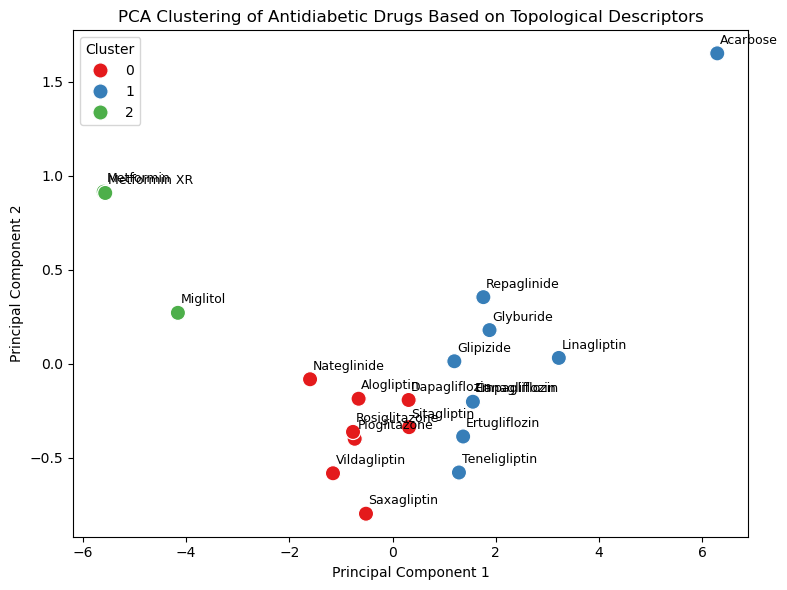

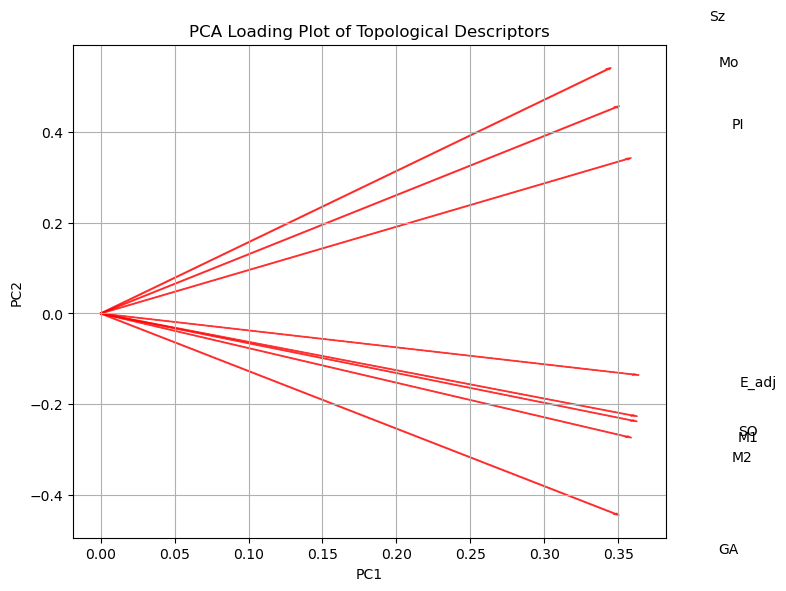


PCA clustering completed successfully.


In [8]:
# ==========================================
# Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# ==========================================
# Load dataset
# ==========================================
file_path = r"D:\Phd\PhD\Papers on topological indices\Zia Sb\Anti diabetic drugs\Data\TI.xlsx"

df = pd.read_excel(file_path)


# ==========================================
# Select descriptors
# ==========================================
descriptor_cols = ["M1","M2","SO","Mo","PI","Sz","GA","E_adj"]

X = df[descriptor_cols]


# ==========================================
# Standardize descriptors
# ==========================================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================
# Perform PCA
# ==========================================
pca = PCA()

X_pca = pca.fit_transform(X_scaled)


# ==========================================
# PCA explained variance
# ==========================================
explained_var = pca.explained_variance_ratio_

print("\nExplained Variance by Principal Components:\n")

for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.3f}")


# ==========================================
# K-Means Clustering
# ==========================================
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters


# ==========================================
# PCA Scatter Plot
# ==========================================
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette="Set1",
    s=120
)

for i, drug in enumerate(df["Drug"]):
    plt.text(
        X_pca[i,0]+0.05,
        X_pca[i,1]+0.05,
        drug,
        fontsize=9
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA Clustering of Antidiabetic Drugs Based on Topological Descriptors")

plt.legend(title="Cluster")

plt.tight_layout()

plt.show()


# ==========================================
# PCA Loading Plot (descriptor influence)
# ==========================================
loadings = pca.components_.T

plt.figure(figsize=(8,6))

for i, descriptor in enumerate(descriptor_cols):

    plt.arrow(
        0,0,
        loadings[i,0],
        loadings[i,1],
        color='red',
        alpha=0.7
    )

    plt.text(
        loadings[i,0]*1.2,
        loadings[i,1]*1.2,
        descriptor,
        color='black'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Loading Plot of Topological Descriptors")

plt.grid()

plt.tight_layout()

plt.show()


# ==========================================
# Save PCA results
# ==========================================
pca_df = pd.DataFrame(
    X_pca[:,0:2],
    columns=["PC1","PC2"]
)

pca_df["Drug"] = df["Drug"]
pca_df["Cluster"] = clusters

pca_df.to_csv("PCA_drug_clustering.csv", index=False)

print("\nPCA clustering completed successfully.")